# Predicting SPY Returns Using Blended Machine Learning Models

This project leverages machine learning techniques to predict the daily returns of the SPDR S&P 500 ETF (SPY) using historical OHLCV (Open, High, Low, Close, and Volume) data. The objective is to build a robust model that can forecast SPY returns, facilitating better decision-making for algorithmic trading strategies.

The methodology involves the following steps:

Data Preprocessing: Historical OHLCV data is collected and preprocessed, including feature engineering, handling missing values, and creating technical indicators such as moving averages, RSI, MACD, and volatility measures. These features are then used to train machine learning models.

Model Development:

Decision Tree Classifier: A basic decision tree classifier is used as a starting point, which creates a tree-like structure to classify the relationship between the input features and SPY returns.
Random Forest Classifier: The random forest model, an ensemble method, builds multiple decision trees and combines their predictions, improving model accuracy and reducing overfitting compared to a single decision tree.
XGBoost Classifier: XGBoost, a gradient boosting algorithm, is employed to further enhance model performance. It builds a series of decision trees in a sequential manner, optimizing the model using techniques like regularization and boosting to handle complex data patterns effectively.
Blended Model: Finally, the predictions of several machine learning classifiers (Logistic Regression, SVC, Decision Tree, Random Forest, and XGBoost) are combined using a meta-learning approach, where the outputs of the individual models are used as features in a final classifier. This blended model aims to leverage the strengths of each base model and improve prediction accuracy.

Performance Evaluation: The models' performance is evaluated using various metrics such as accuracy, precision, recall, F1 score, and the Sharpe ratio, with a focus on out-of-sample validation. The final strategy performance is compared against a simple buy-and-hold strategy, and cumulative returns are computed to assess the profitability of the model.

By combining the strengths of decision trees, random forests, and XGBoost into a blended machine learning model, this project aims to create a robust, high-performing strategy for predicting SPY returns, ultimately providing a more sophisticated approach to trading and investment decision-making.

## Imports

In [1]:
# For data manipulation
import pandas as pd
import numpy as np

# For plotting
import matplotlib.pyplot as plt
import mplcyberpunk
plt.style.use("cyberpunk")
import seaborn as sns

# Data Extraction
import datetime
import time
import yfinance as yf

# For technical analysis
import talib as ta

import xgboost as xgb
from sklearn.ensemble import *
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split


from scipy.stats import uniform, randint, loguniform
from pykalman import KalmanFilter

from feature_engine.selection import SelectBySingleFeaturePerformance

import warnings
warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)

### Data Extraction and EDA

We extract the OHLCV data for SPY using yfinance for the last 20 years.

In [2]:
end_date = '2025-03-09'
start_date = '2005-03-15'

symbol = "SPY"
data = yf.download(symbol, start=start_date, end=end_date, auto_adjust=False)

[*********************100%***********************]  1 of 1 completed


In [3]:
# Remove the second row (Ticker row)
data.columns = data.columns.droplevel(1)  # Drop the first level (Ticker row)
data.columns.name = None  # Removes the extra label if set
# # Reset the index name
data.index.name = "Date"

In [4]:
df = data.copy()
df.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2005-03-15,82.454544,120.139999,121.459999,120.080002,121.419998,62438500
2005-03-16,81.754440,119.120003,120.160004,118.900002,119.699997,74874200
2005-03-17,81.919174,119.360001,119.739998,118.980003,119.309998,62584200
2005-03-18,81.675919,118.540001,119.529999,118.150002,119.110001,60232000
2005-03-21,81.372765,118.099998,118.779999,117.760002,118.709999,61244300


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5028 entries, 2005-03-15 to 2025-03-07
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  5028 non-null   float64
 1   Close      5028 non-null   float64
 2   High       5028 non-null   float64
 3   Low        5028 non-null   float64
 4   Open       5028 non-null   float64
 5   Volume     5028 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 275.0 KB


In [6]:
df.describe()

,Adj Close,Close,High,Low,Open,Volume
count,5028.000000,5028.000000,5028.000000,5028.000000,5028.000000,5.028000e+03
mean,213.225829,239.476589,240.781066,237.993425,239.452651,1.256569e+08
std,138.933566,131.105370,131.708911,130.392559,131.093486,9.141677e+07
min,50.531090,68.110001,70.000000,67.099998,67.949997,1.527000e+07
25%,99.385685,132.215000,132.982506,131.394997,132.289993,6.600782e+07
50%,169.769981,200.955002,201.954994,199.845001,201.309998,9.521770e+07
75%,287.318405,309.729988,311.629997,307.662506,309.637505,1.543555e+08
max,612.929993,612.929993,613.229980,609.559998,611.539978,8.710263e+08


The data appears to be clean, with no missing or anomalous values detected.

In [7]:
# Check for null values
print(df.isnull().sum())  # Counts null values per column
print(df.isnull().any())  # Checks if any null values exist per column
print(df.isnull().sum().sum())  # Total number of null values in the DataFrame

Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64
Adj Close    False
Close        False
High         False
Low          False
Open         False
Volume       False
dtype: bool
0


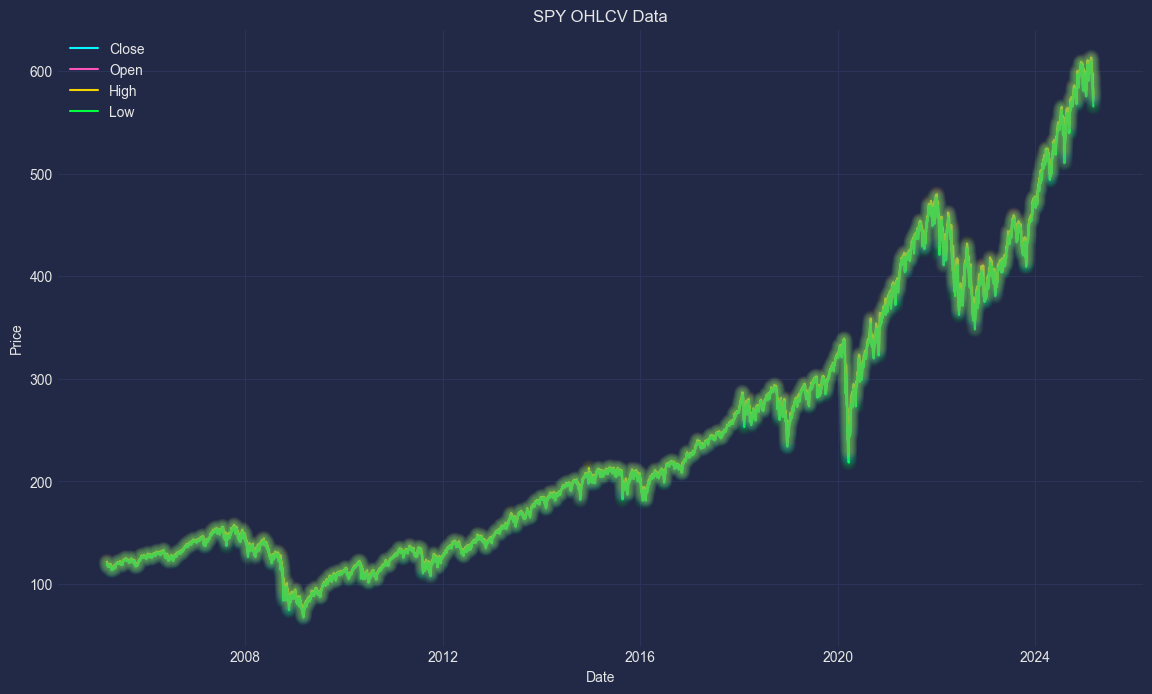

In [8]:
fig= plt.subplots(figsize=(14, 8))

# Plot OHLCV data
plt.plot(df['Close'], label='Close')
plt.plot(df['Open'], label='Open')
plt.plot(df['High'], label='High')
plt.plot(df['Low'], label='Low')

# Set labels
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend(loc='upper left')

# Add title
plt.title(f'{symbol} OHLCV Data')

mplcyberpunk.make_lines_glow()

# Display the plot
plt.show()

The plots also show no anomalous values.

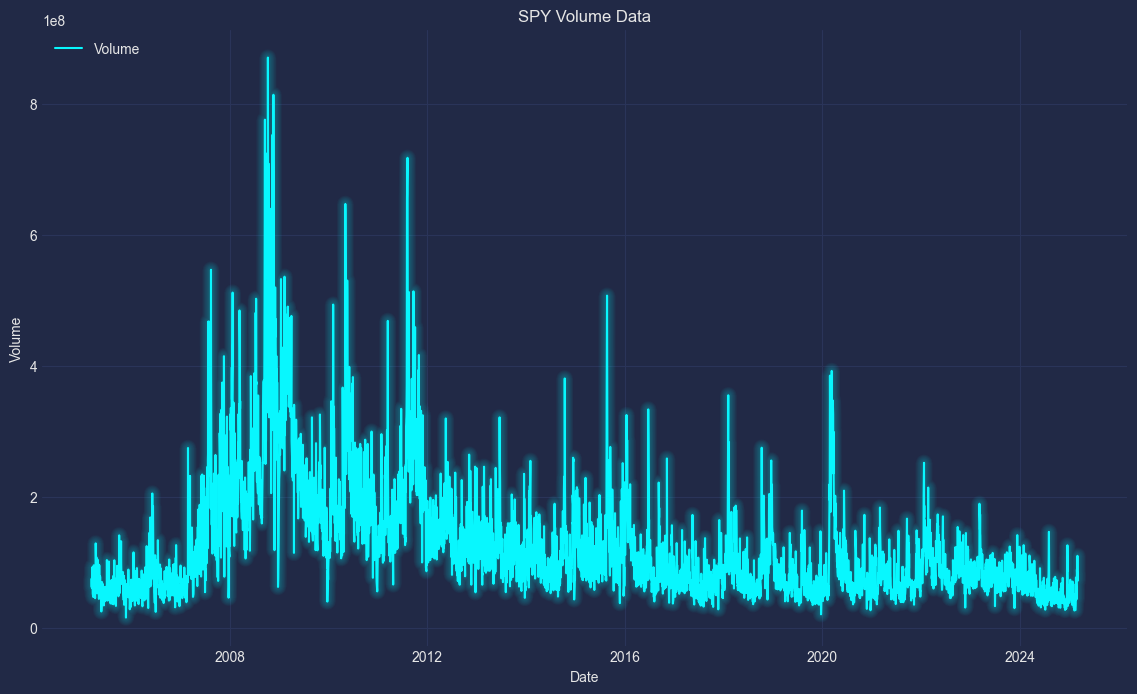

In [9]:
fig= plt.subplots(figsize=(14, 8))

# Plot OHLCV data
plt.plot(df['Volume'], label='Volume')

# Set labels
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend(loc='upper left')

# Add title
plt.title(f'{symbol} Volume Data')

mplcyberpunk.make_lines_glow()

# Display the plot
plt.show()

## Decision Tree

### Feature Engineering
Next, we will generate additional features from the OHLCV data, including returns, momentum indicators, and various technical indicators.

In [10]:
# Define time periods to calculate returns
intervals = [1, 5, 10, 22]

# Loop to calculate log returns for time periods specified in 'intervals'
for t in intervals:
    # Create new columns for features in 'df' and store the value of returns
    df[f'f_ret_{t}'] = df.Close.pct_change(t)

# Display the data
df.tail()

,Adj Close,Close,High,Low,Open,Volume,f_ret_1,f_ret_5,f_ret_10,f_ret_22
Date,,,,,,,,,,
2025-03-03,583.770020,583.770020,597.340027,579.900024,596.179993,74249200,-0.017520,-0.022505,-0.042529,-0.029976
2025-03-04,576.859985,576.859985,585.390015,572.250000,579.710022,109648200,-0.011837,-0.029247,-0.056632,-0.046575
2025-03-05,583.059998,583.059998,584.880005,573.080017,576.690002,71230500,0.010748,-0.019309,-0.048733,-0.031172
2025-03-06,572.710022,572.710022,580.169983,570.119995,575.479980,80094900,-0.017751,-0.021092,-0.061716,-0.041922
2025-03-07,575.919983,575.919983,577.390015,565.630005,570.900024,81158800,0.005605,-0.030731,-0.040037,-0.042973


In [11]:
intervals = [5, 10, 22]

for t in intervals:
    df[f'f_momentum_{t}'] = df[f'f_ret_{t}'].sub(df.f_ret_1)
    
df.tail()

,Adj Close,Close,High,Low,Open,Volume,f_ret_1,f_ret_5,f_ret_10,f_ret_22,f_momentum_5,f_momentum_10,f_momentum_22
Date,,,,,,,,,,,,,
2025-03-03,583.770020,583.770020,597.340027,579.900024,596.179993,74249200,-0.017520,-0.022505,-0.042529,-0.029976,-0.004985,-0.025009,-0.012456
2025-03-04,576.859985,576.859985,585.390015,572.250000,579.710022,109648200,-0.011837,-0.029247,-0.056632,-0.046575,-0.017411,-0.044795,-0.034739
2025-03-05,583.059998,583.059998,584.880005,573.080017,576.690002,71230500,0.010748,-0.019309,-0.048733,-0.031172,-0.030057,-0.059481,-0.041920
2025-03-06,572.710022,572.710022,580.169983,570.119995,575.479980,80094900,-0.017751,-0.021092,-0.061716,-0.041922,-0.003341,-0.043964,-0.024171
2025-03-07,575.919983,575.919983,577.390015,565.630005,570.900024,81158800,0.005605,-0.030731,-0.040037,-0.042973,-0.036336,-0.045642,-0.048577


In [12]:
# df['f_Trading_Range'] = df['High'] - df['Low']
df['f_Volume_Change'] = df.Volume - df.Volume.shift(1)
df['f_Volume_MA'] = df['Volume'] / df['Volume'].rolling(22).mean()

# Calculate and store the NATR values
df['f_natr'] = ta.NATR(df.High, df.Low, df.Close)

# Calculate and store the RSI values
df['f_rsi'] = ta.RSI(df.Close)

# Calculate and store the MACD values
_, _, df['f_MACD_hist'] = ta.MACD(df['Close'], fastperiod=12, slowperiod=26, signalperiod=9)

# Compute the Bollinger bands
upper, middle, lower = ta.BBANDS(df.Close)

# Normalise the bands and store in separate columns
df['f_norm_upper'] = upper/df.Close
df['f_norm_lower'] = lower/df.Close
df['f_norm_middle'] = middle/df.Close

df['f_ROC'] = ta.ROC(df['Close'], timeperiod=10)

# Drop NaN values and display the data
df.dropna(inplace=True)
df.tail()

,Adj Close,Close,High,Low,Open,Volume,f_ret_1,f_ret_5,f_ret_10,f_ret_22,...,f_momentum_22,f_Volume_Change,f_Volume_MA,f_natr,f_rsi,f_MACD_hist,f_norm_upper,f_norm_lower,f_norm_middle,f_ROC
Date,,,,,,,,,,,,,,,,,,,,,
2025-03-03,583.770020,583.770020,597.340027,579.900024,596.179993,74249200,-0.017520,-0.022505,-0.042529,-0.029976,...,-0.012456,-14494900.0,1.552971,1.387304,37.409495,-2.676489,1.027978,0.994586,1.011282,-4.252910
2025-03-04,576.859985,576.859985,585.390015,572.250000,579.710022,109648200,-0.011837,-0.029247,-0.056632,-0.046575,...,-0.034739,35399000.0,2.149562,1.466345,33.554795,-3.223215,1.040648,0.994092,1.017370,-5.663217
2025-03-05,583.059998,583.059998,584.880005,573.080017,576.690002,71230500,0.010748,-0.019309,-0.048733,-0.031172,...,-0.041920,-38417700.0,1.390765,1.491685,39.571361,-2.994333,1.021709,0.983519,1.002614,-4.873313
2025-03-06,572.710022,572.710022,580.169983,570.119995,575.479980,80094900,-0.017751,-0.021092,-0.061716,-0.041922,...,-0.024171,8864400.0,1.544327,1.571556,34.031514,-3.340669,1.041860,0.990988,1.016424,-6.171562
2025-03-07,575.919983,575.919983,577.390015,565.630005,570.900024,81158800,0.005605,-0.030731,-0.040037,-0.042973,...,-0.048577,1063900.0,1.502046,1.597022,36.978322,-3.156409,1.019267,0.989567,1.004417,-4.003737


In [13]:
# Ensure the index is in datetime format
df.index = pd.to_datetime(df.index)

# Extract year and month from index
df['f_year'] = df.index.year
df['f_month'] = df.index.month

In [14]:
df.head()

,Adj Close,Close,High,Low,Open,Volume,f_ret_1,f_ret_5,f_ret_10,f_ret_22,...,f_Volume_MA,f_natr,f_rsi,f_MACD_hist,f_norm_upper,f_norm_lower,f_norm_middle,f_ROC,f_year,f_month
Date,,,,,,,,,,,,,,,,,,,,,
2005-05-02,80.201447,116.400002,116.410004,115.519997,116.070000,56026400,0.005616,0.000602,0.016594,-0.013225,...,0.729621,1.245818,47.919101,0.029694,1.004278,0.979227,0.991753,1.659390,2005,5
2005-05-03,80.339249,116.599998,116.849998,115.690002,116.070000,86000300,0.001718,0.012153,0.010311,-0.007068,...,1.126134,1.225908,48.770856,0.104260,1.006912,0.977994,0.992453,1.031102,2005,5
2005-05-04,80.959351,117.500000,117.750000,116.279999,116.650002,81055700,0.007719,0.015997,0.032513,-0.001105,...,1.055435,1.218985,52.532976,0.208971,1.006696,0.969304,0.988000,3.251315,2005,5
2005-05-05,80.931808,117.459999,118.000000,116.739998,117.669998,96906700,-0.000340,0.028546,0.012499,-0.006177,...,1.225527,1.208922,52.348969,0.266624,1.005211,0.982564,0.993887,1.249890,2005,5
2005-05-06,80.676865,117.089996,117.989998,117.059998,117.930000,67415400,-0.003150,0.011577,0.013152,-0.012732,...,0.845689,1.182851,50.584004,0.270090,1.006914,0.991719,0.999317,1.315217,2005,5


In [15]:
# Download VIX data (1-day frequency)
vix_data = yf.download('^VIX', start=start_date, end=end_date, auto_adjust=False)

[*********************100%***********************]  1 of 1 completed


We retrieve VIX data and compute its percent change values.

In [16]:
# Remove the second row (Ticker row)
vix_data.columns = vix_data.columns.droplevel(1)  # Drop the first level (Ticker row)
vix_data.columns.name = None  # Removes the extra label if set
# # Reset the index name
vix_data.index.name = "Date"

In [17]:
vix_data.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2005-03-15,13.15,13.15,13.22,12.33,12.44,0
2005-03-16,13.49,13.49,13.81,13.19,13.30,0
2005-03-17,13.29,13.29,13.67,13.20,13.25,0
2005-03-18,13.14,13.14,13.67,13.08,13.65,0
2005-03-21,13.61,13.61,13.98,13.33,13.62,0


In [18]:
# Define time periods to calculate returns
intervals = [1, 2, 3]

# Loop to calculate log returns for time periods specified in 'intervals'
for t in intervals:
    # Create new columns for features in 'df' and store the value of returns
    vix_data[f'f_vix_ret_{t}'] = vix_data.Close.pct_change(t)

In [19]:
vix_data.head()

,Adj Close,Close,High,Low,Open,Volume,f_vix_ret_1,f_vix_ret_2,f_vix_ret_3
Date,,,,,,,,,
2005-03-15,13.15,13.15,13.22,12.33,12.44,0,NaN,NaN,NaN
2005-03-16,13.49,13.49,13.81,13.19,13.30,0,0.025856,NaN,NaN
2005-03-17,13.29,13.29,13.67,13.20,13.25,0,-0.014826,0.010646,NaN
2005-03-18,13.14,13.14,13.67,13.08,13.65,0,-0.011287,-0.025945,-0.000760
2005-03-21,13.61,13.61,13.98,13.33,13.62,0,0.035769,0.024078,0.008895


In [20]:
df = df.join(vix_data[['f_vix_ret_1', 'f_vix_ret_2', 'f_vix_ret_3',]], how='left')

In [21]:
df.tail()

,Adj Close,Close,High,Low,Open,Volume,f_ret_1,f_ret_5,f_ret_10,f_ret_22,...,f_MACD_hist,f_norm_upper,f_norm_lower,f_norm_middle,f_ROC,f_year,f_month,f_vix_ret_1,f_vix_ret_2,f_vix_ret_3
Date,,,,,,,,,,,,,,,,,,,,,
2025-03-03,583.770020,583.770020,597.340027,579.900024,596.179993,74249200,-0.017520,-0.022505,-0.042529,-0.029976,...,-2.676489,1.027978,0.994586,1.011282,-4.252910,2025,3,0.160469,0.078088,0.192670
2025-03-04,576.859985,576.859985,585.390015,572.250000,579.710022,109648200,-0.011837,-0.029247,-0.056632,-0.046575,...,-3.223215,1.040648,0.994092,1.017370,-5.663217,2025,3,0.032046,0.197657,0.112636
2025-03-05,583.059998,583.059998,584.880005,573.080017,576.690002,71230500,0.010748,-0.019309,-0.048733,-0.031172,...,-2.994333,1.021709,0.983519,1.002614,-4.873313,2025,3,-0.067205,-0.037313,0.117168
2025-03-06,572.710022,572.710022,580.169983,570.119995,575.479980,80094900,-0.017751,-0.021092,-0.061716,-0.041922,...,-3.340669,1.041860,0.990988,1.016424,-6.171562,2025,3,0.134063,0.057848,0.091747
2025-03-07,575.919983,575.919983,577.390015,565.630005,570.900024,81158800,0.005605,-0.030731,-0.040037,-0.042973,...,-3.156409,1.019267,0.989567,1.004417,-4.003737,2025,3,-0.060314,0.065663,-0.005955


Next we drop the original OHLCV data.

In [22]:
# Store features data in 'features'
features = df.filter(like='f_')

# Display the last 5 rows
features.tail()

,f_ret_1,f_ret_5,f_ret_10,f_ret_22,f_momentum_5,f_momentum_10,f_momentum_22,f_Volume_Change,f_Volume_MA,f_natr,...,f_MACD_hist,f_norm_upper,f_norm_lower,f_norm_middle,f_ROC,f_year,f_month,f_vix_ret_1,f_vix_ret_2,f_vix_ret_3
Date,,,,,,,,,,,,,,,,,,,,,
2025-03-03,-0.017520,-0.022505,-0.042529,-0.029976,-0.004985,-0.025009,-0.012456,-14494900.0,1.552971,1.387304,...,-2.676489,1.027978,0.994586,1.011282,-4.252910,2025,3,0.160469,0.078088,0.192670
2025-03-04,-0.011837,-0.029247,-0.056632,-0.046575,-0.017411,-0.044795,-0.034739,35399000.0,2.149562,1.466345,...,-3.223215,1.040648,0.994092,1.017370,-5.663217,2025,3,0.032046,0.197657,0.112636
2025-03-05,0.010748,-0.019309,-0.048733,-0.031172,-0.030057,-0.059481,-0.041920,-38417700.0,1.390765,1.491685,...,-2.994333,1.021709,0.983519,1.002614,-4.873313,2025,3,-0.067205,-0.037313,0.117168
2025-03-06,-0.017751,-0.021092,-0.061716,-0.041922,-0.003341,-0.043964,-0.024171,8864400.0,1.544327,1.571556,...,-3.340669,1.041860,0.990988,1.016424,-6.171562,2025,3,0.134063,0.057848,0.091747
2025-03-07,0.005605,-0.030731,-0.040037,-0.042973,-0.036336,-0.045642,-0.048577,1063900.0,1.502046,1.597022,...,-3.156409,1.019267,0.989567,1.004417,-4.003737,2025,3,-0.060314,0.065663,-0.005955


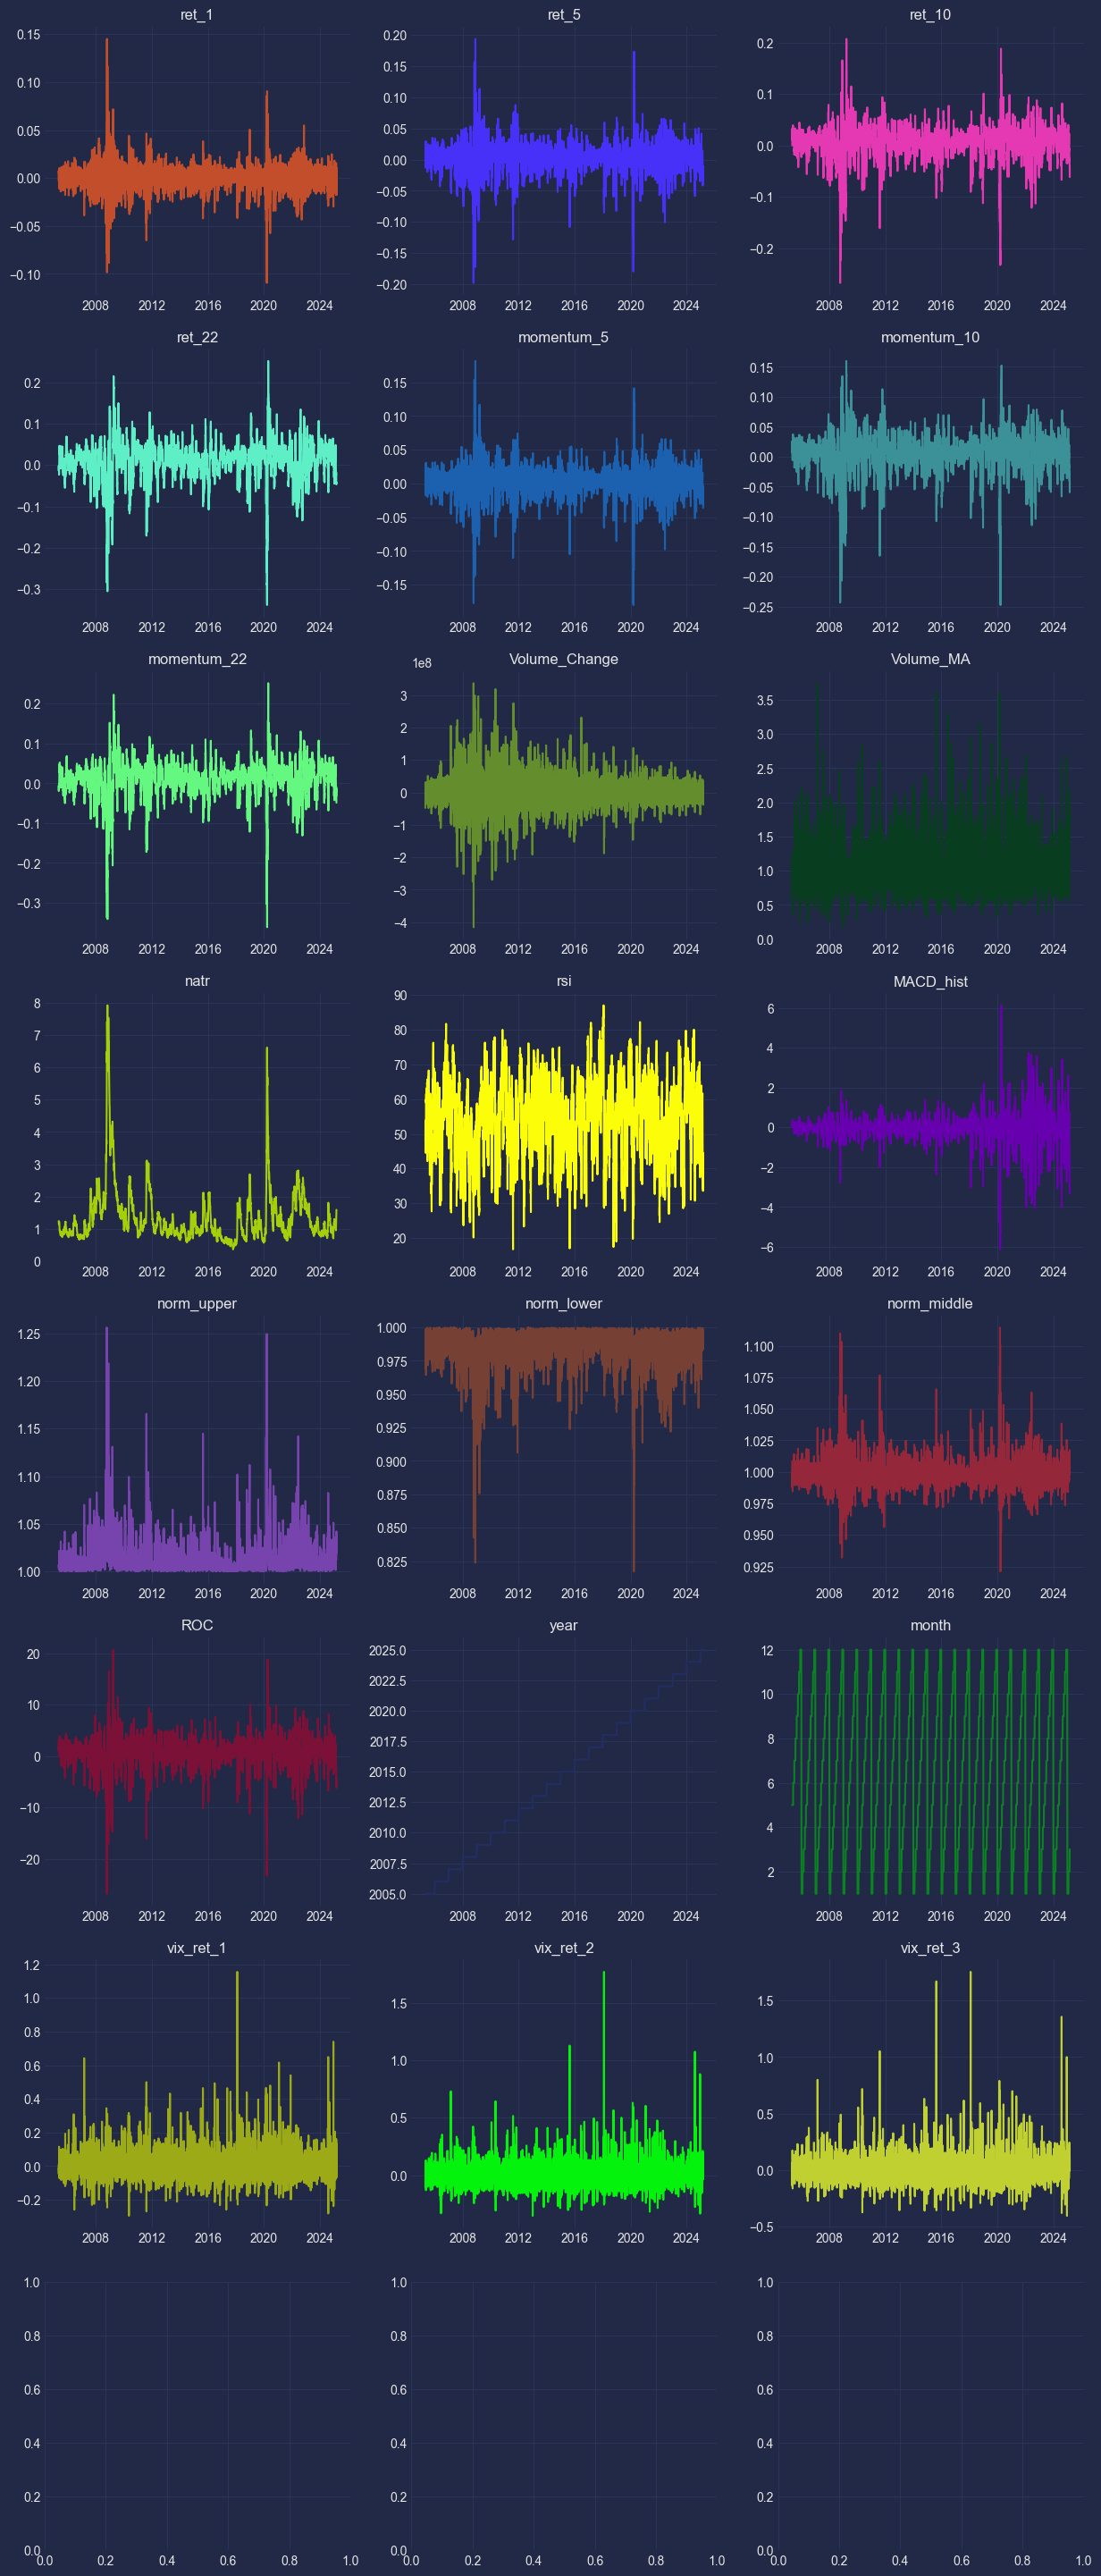

In [23]:
# Get the total count of features
num_of_features = len(features.columns)

# Define the layout and size for subplots
fig, axs = plt.subplots(int(num_of_features/3)+1, 3,
                        figsize=(15, 5*(num_of_features+1)/3))
axs = axs.ravel()
mplcyberpunk.add_glow_effects()

# Loop to plot the individual features
for i in range(num_of_features):
    axs[i].plot(df[features.columns[i]], color=np.random.rand(3,))
    axs[i].set_title(features.columns[i].replace('f_',''))
    mplcyberpunk.add_glow_effects()

plt.show()

After reviewing the feature plots, everything appears as expected.

Next, we define the target variable, assigning a value of `1` if the next day's returns are positive and `0` if they are negative.  Then assign the features to `X` and the target to `y`.

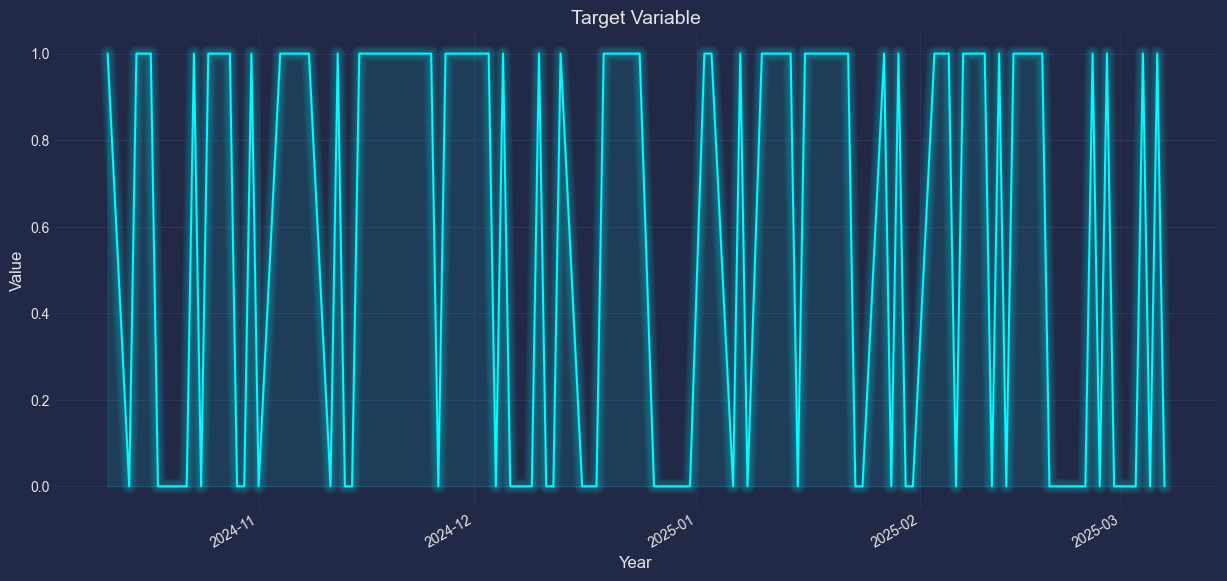

In [24]:
# Create the target variable
df['return'] = df.Close.pct_change(1).shift(-1)
df['target'] = np.where(df['return'] > 0, 1, 0)

# Plot the target
plt.figure(figsize=(15, 7))
df.iloc[-100:].target.plot()

# Set the title and axes labels
plt.title('Target Variable', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Value', fontsize=12)
mplcyberpunk.add_glow_effects()
plt.show()

In [25]:
# Store the features data in variable X
X = df.filter(like='f_')
X.tail()

,f_ret_1,f_ret_5,f_ret_10,f_ret_22,f_momentum_5,f_momentum_10,f_momentum_22,f_Volume_Change,f_Volume_MA,f_natr,...,f_MACD_hist,f_norm_upper,f_norm_lower,f_norm_middle,f_ROC,f_year,f_month,f_vix_ret_1,f_vix_ret_2,f_vix_ret_3
Date,,,,,,,,,,,,,,,,,,,,,
2025-03-03,-0.017520,-0.022505,-0.042529,-0.029976,-0.004985,-0.025009,-0.012456,-14494900.0,1.552971,1.387304,...,-2.676489,1.027978,0.994586,1.011282,-4.252910,2025,3,0.160469,0.078088,0.192670
2025-03-04,-0.011837,-0.029247,-0.056632,-0.046575,-0.017411,-0.044795,-0.034739,35399000.0,2.149562,1.466345,...,-3.223215,1.040648,0.994092,1.017370,-5.663217,2025,3,0.032046,0.197657,0.112636
2025-03-05,0.010748,-0.019309,-0.048733,-0.031172,-0.030057,-0.059481,-0.041920,-38417700.0,1.390765,1.491685,...,-2.994333,1.021709,0.983519,1.002614,-4.873313,2025,3,-0.067205,-0.037313,0.117168
2025-03-06,-0.017751,-0.021092,-0.061716,-0.041922,-0.003341,-0.043964,-0.024171,8864400.0,1.544327,1.571556,...,-3.340669,1.041860,0.990988,1.016424,-6.171562,2025,3,0.134063,0.057848,0.091747
2025-03-07,0.005605,-0.030731,-0.040037,-0.042973,-0.036336,-0.045642,-0.048577,1063900.0,1.502046,1.597022,...,-3.156409,1.019267,0.989567,1.004417,-4.003737,2025,3,-0.060314,0.065663,-0.005955


In [26]:
# Store the target data in variable y
y = df['target']
y.tail()

Date
2025-03-03    0
2025-03-04    1
2025-03-05    0
2025-03-06    1
2025-03-07    0
Name: target, dtype: int32

We split the data into training and test sets while preserving the sequential order to maintain the integrity of time-series patterns.

In [27]:
# Set the split threshold
split_percentage = 0.7
split = int(split_percentage*len(X))

# Train dataset
X_train = X[:split]
y_train = y[:split]

# Test dataset
X_test = X[split:]
y_test = y[split:]

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(3496, 21) (3496,)
(1499, 21) (1499,)


In [28]:
print(y_train.value_counts())  

target
1    1901
0    1595
Name: count, dtype: int64


The target variable is slightly imbalanced, with approximately 16% more days of positive returns than negative returns.

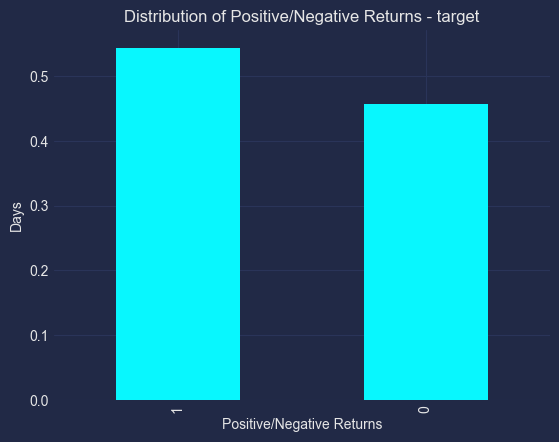

In [29]:
# Display the target distribution

y_train.value_counts(normalize=True).plot.bar()
plt.xlabel("Positive/Negative Returns")
plt.ylabel("Days")
plt.title("Distribution of Positive/Negative Returns - target")
plt.show()

### Decision Tree Model

In [30]:
# Initialise the decision tree classifier
dt_model = DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=42)
dt_model

DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=42)

First, we initialize and train a decision tree model using a set of arbitrary hyperparameters, ensuring a shallow depth to mitigate the risk of overfitting.

In [31]:
# Train the model on the training set
dt_model = dt_model.fit(X_train, y_train)

In [32]:
y_pred_test = dt_model.predict(X_test)
y_pred_train = dt_model.predict(X_train)

In [33]:
# Evaluate the model on the train dataset
accuracy_train = accuracy_score(y_train, y_pred_train)
precision_train = precision_score(y_train, y_pred_train, average='binary')
recall_train = recall_score(y_train, y_pred_train, average='binary')
f1_train = f1_score(y_train, y_pred_train, average='binary')

print('\nTrain Accuracy: {:.2f}%'.format(accuracy_train * 100))
print('Train Precision: {:.2f}%'.format(precision_train * 100))
print('Train Recall: {:.2f}%'.format(recall_train * 100))
print('Train F1 Score: {:.2f}%'.format(f1_train * 100))

# Evaluate the model on the test dataset
accuracy_test = accuracy_score(y_test, y_pred_test)
precision_test = precision_score(y_test, y_pred_test, average='binary')
recall_test = recall_score(y_test, y_pred_test, average='binary')
f1_test = f1_score(y_test, y_pred_test, average='binary')

print('\nTest Accuracy: {:.2f}%'.format(accuracy_test * 100))
print('Test Precision: {:.2f}%'.format(precision_test * 100))
print('Test Recall: {:.2f}%'.format(recall_test * 100))
print('Test F1 Score: {:.2f}%'.format(f1_test * 100))



Train Accuracy: 56.81%
Train Precision: 55.93%
Train Recall: 97.05%
Train F1 Score: 70.96%

Test Accuracy: 54.77%
Test Precision: 55.22%
Test Recall: 94.18%
Test F1 Score: 69.62%


The model exhibits slight overfitting, as the training set accuracy is approximately 2.2% higher than the test set. Additionally, the recall is very high, indicating that the model predominantly predicts positive returns.

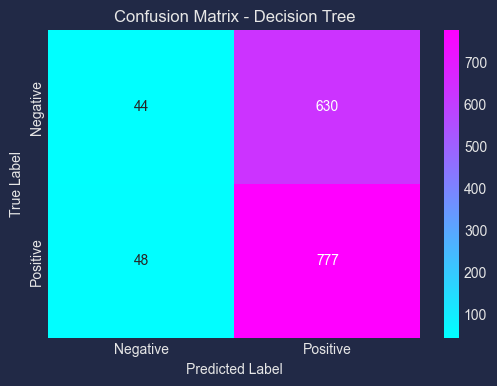

In [34]:
# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

# Define class labels
labels = ["Negative", "Positive"]

# Plot the confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="cool", xticklabels=labels, yticklabels=labels)

# Labels, title, and axis names
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Decision Tree")

plt.show()

### Hyperparameter Tuning

In [35]:
dt_model = DecisionTreeClassifier(random_state=42)

# Define the hyperparameter grid
param_dist = {
    'max_depth': randint(2, 10),                 # Random depth between 2 and 20
    'min_samples_split': randint(2, 10),         # Min samples required to split a node
    'min_samples_leaf': randint(1, 10),          # Min samples per leaf
    'criterion': ['gini', 'entropy'],            # Split criteria
}

Next, we will perform a random search for hyperparameter optimization, carefully setting reasonable upper limits on parameters to reduce the risk of overfitting.

In [36]:
# Randomized Search CV
random_search = RandomizedSearchCV(
    estimator=dt_model, 
    param_distributions=param_dist, 
    n_iter=1000,                  # Number of random samples
    scoring='accuracy',         # Evaluation metric
    cv=5,                       # 5-fold cross-validation
    random_state=42,
    n_jobs=-1                   # Use all CPU cores
)

In [37]:
# Fit on training data
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
                   n_iter=1000, n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000016BF13B0200>,
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000016BED84F020>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000016BF0E6FB00>},
                   random_state=42, scoring='accuracy')

In [38]:
# Best parameters and score
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Accuracy: {random_search.best_score_:.4f}")

Best Parameters: {'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 2, 'min_samples_split': 4}
Best Accuracy: 0.5329


In [39]:
best_params = random_search.best_params_

In [40]:
# Create a new model using the best hyperparameters
best_dt_model = DecisionTreeClassifier(**best_params, random_state=42)

# Fit the model on the full training data
best_dt_model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=9, min_samples_leaf=2,
                       min_samples_split=4, random_state=42)

In [41]:
y_pred_test = best_dt_model.predict(X_test)
y_pred_train = best_dt_model.predict(X_train)

In [42]:
# Evaluate the model on the train dataset
accuracy_train = accuracy_score(y_train, y_pred_train)
precision_train = precision_score(y_train, y_pred_train, average='binary')
recall_train = recall_score(y_train, y_pred_train, average='binary')
f1_train = f1_score(y_train, y_pred_train, average='binary')

print('\nTrain Accuracy: {:.2f}%'.format(accuracy_train * 100))
print('Train Precision: {:.2f}%'.format(precision_train * 100))
print('Train Recall: {:.2f}%'.format(recall_train * 100))
print('Train F1 Score: {:.2f}%'.format(f1_train * 100))

# Evaluate the model on the test dataset
accuracy_test = accuracy_score(y_test, y_pred_test)
precision_test = precision_score(y_test, y_pred_test, average='binary')
recall_test = recall_score(y_test, y_pred_test, average='binary')
f1_test = f1_score(y_test, y_pred_test, average='binary')

print('\nTest Accuracy: {:.2f}%'.format(accuracy_test * 100))
print('Test Precision: {:.2f}%'.format(precision_test * 100))
print('Test Recall: {:.2f}%'.format(recall_test * 100))
print('Test F1 Score: {:.2f}%'.format(f1_test * 100))


Train Accuracy: 59.18%
Train Precision: 58.54%
Train Recall: 85.43%
Train F1 Score: 69.48%

Test Accuracy: 55.04%
Test Precision: 55.98%
Test Recall: 85.70%
Test F1 Score: 67.72%


There are still signs of overfitting, but the model is no longer overwhelmingly predicting positive returns. However, it continues to produce too many false positives.

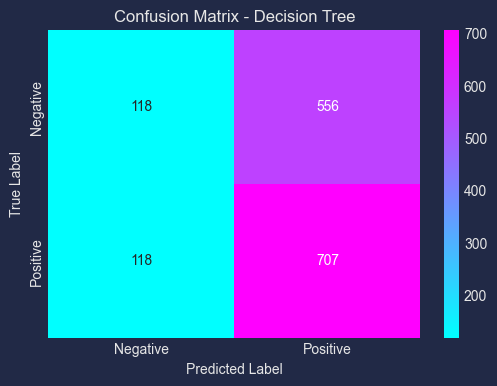

In [43]:
# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

# Define class labels
labels = ["Negative", "Positive"]

# Plot the confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="cool", xticklabels=labels, yticklabels=labels)

# Labels, title, and axis names
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Decision Tree")

plt.show()

### Interpretation

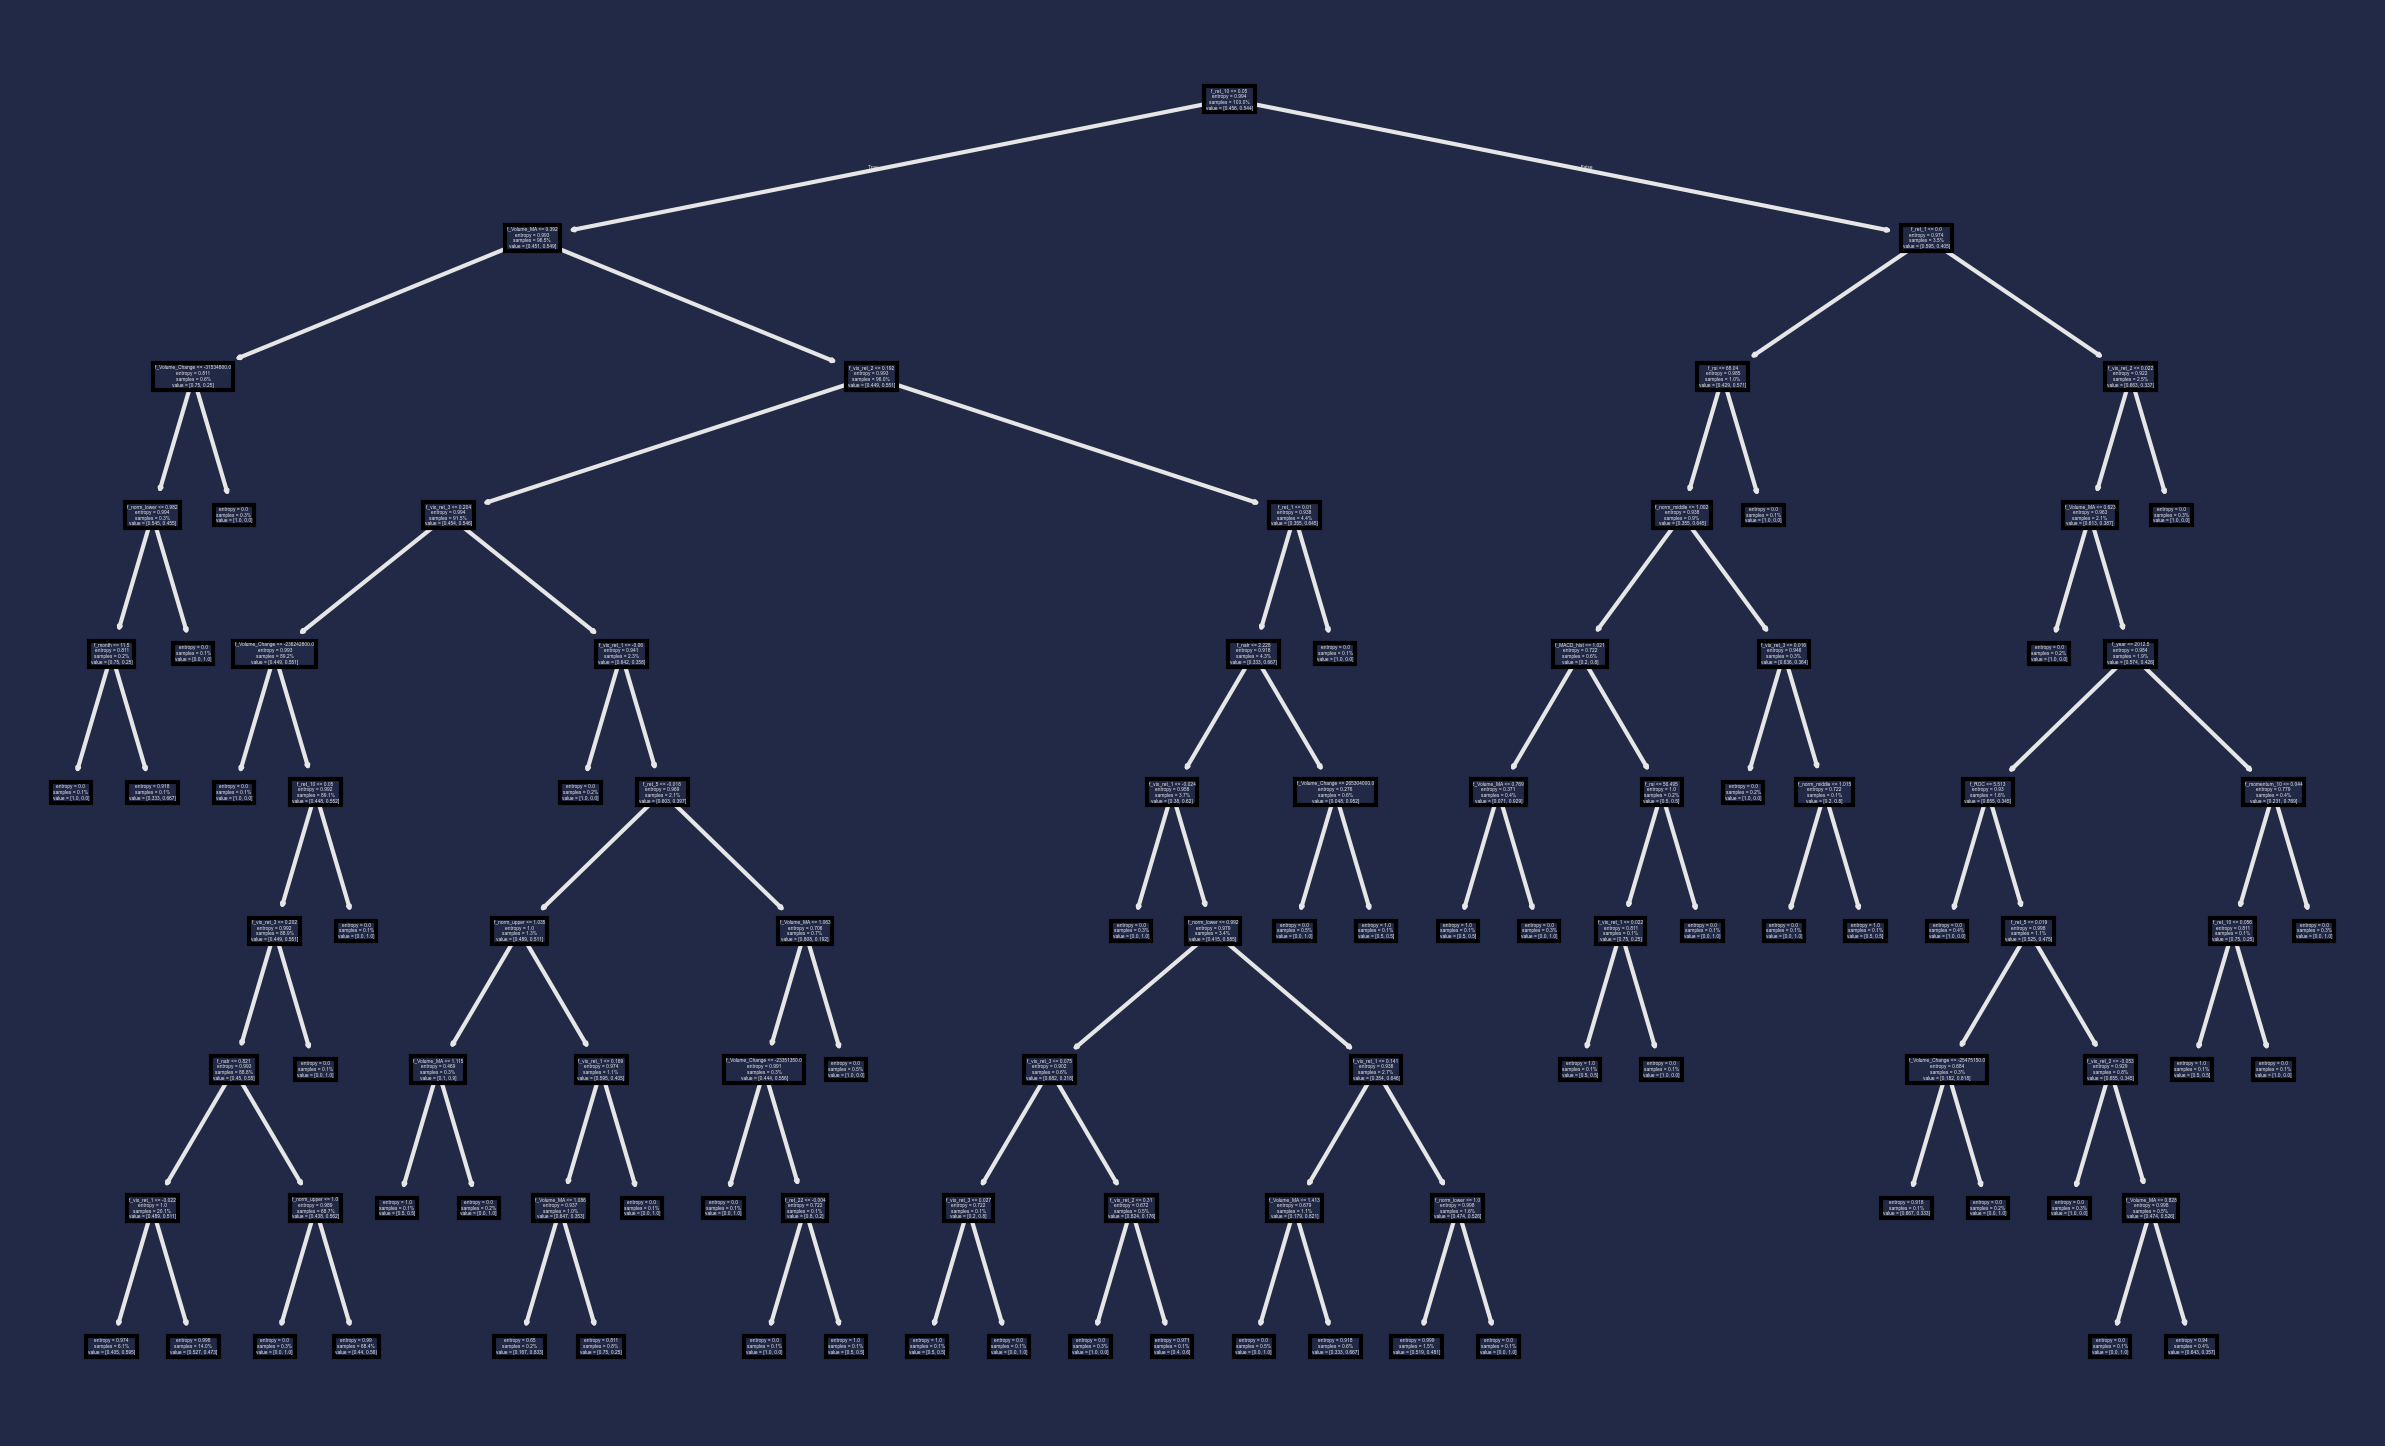

In [44]:
plt.figure(figsize=(10, 6), dpi=300)

plot_tree(
    decision_tree = best_dt_model,
    feature_names=X_train.columns.to_list(),
    filled=False,
    proportion=True, # proportion of observations at each node
)

plt.show()

Unfortunately, the tree plot is difficult to read within a Jupyter Notebook. A more effective analysis would require generating the plot in a different IDE or exporting it as a high-resolution image for better readability.

In [45]:
# The sum of the importances = 1

pd.Series(best_dt_model.feature_importances_).sum()

1.0

In [46]:
global_exp = pd.Series(best_dt_model.feature_importances_, index=best_dt_model.feature_names_in_)

global_exp

f_ret_1            0.042517
f_ret_5            0.039361
f_ret_10           0.045427
f_ret_22           0.005831
f_momentum_5       0.000000
f_momentum_10      0.024948
f_momentum_22      0.000000
f_Volume_Change    0.090393
f_Volume_MA        0.160016
f_natr             0.045324
f_rsi              0.029526
f_MACD_hist        0.011743
f_norm_upper       0.049852
f_norm_lower       0.054535
f_norm_middle      0.021217
f_ROC              0.040644
f_year             0.020494
f_month            0.013532
f_vix_ret_1        0.116042
f_vix_ret_2        0.094165
f_vix_ret_3        0.094431
dtype: float64

Looking at the feature importance, we see that the moving average of volume was the most significant feature, followed by the VIX returns, volume change, and the Bollinger Bands (both upper and lower). This suggests that the model's predictions were primarily driven by volatility-related features, emphasizing the importance of market sentiment and price fluctuations in predicting future returns.

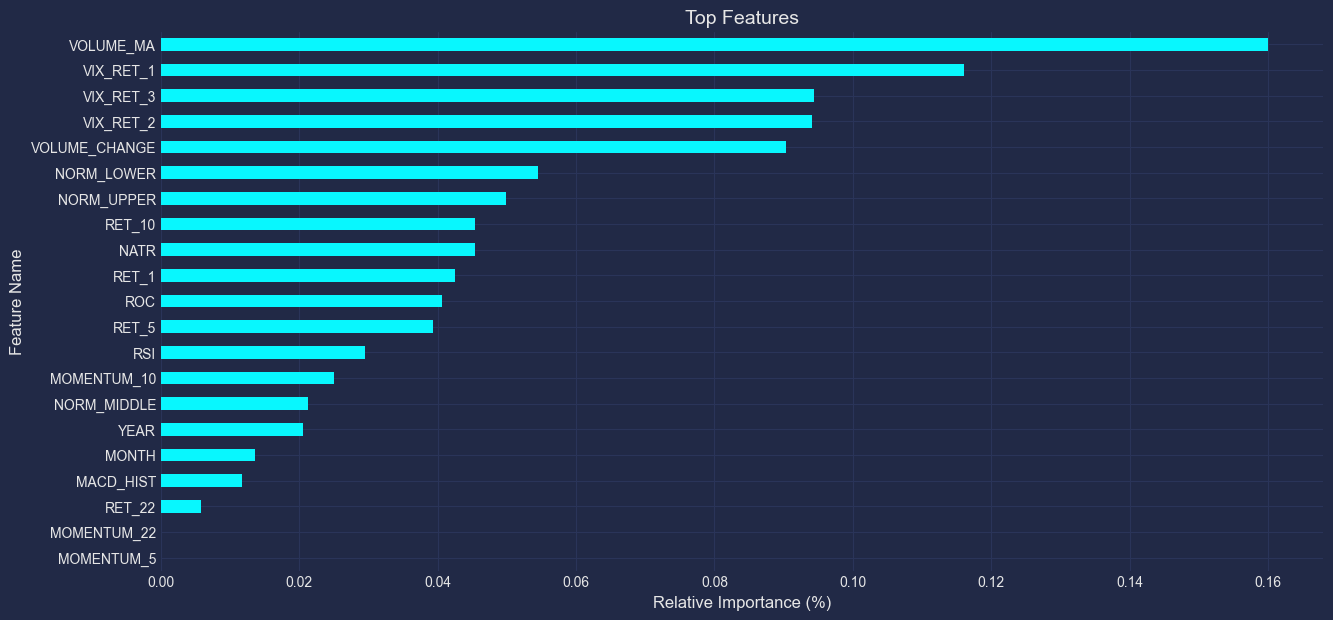

In [47]:
# Initialise the feature labels
labels = X.columns.str.replace('f_', '').str.upper()

# Calculate and sort the feature importances in descending order
feature_importance = (pd.Series(best_dt_model.feature_importances_,
                                index=labels).sort_values(ascending=False))

# Plot the feature ranking
plt.figure(figsize=(15, 7))
feature_importance.sort_values().plot.barh(title='Feature Importance')
plt.title(f'Top Features', fontsize=14)
plt.xlabel('Relative Importance (%)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.show()

In [48]:
sel = SelectBySingleFeaturePerformance(
    estimator = best_dt_model, 
    scoring='accuracy', 
    cv=3, 
    threshold=None,
)

sel.fit(X_train, y_train)

SelectBySingleFeaturePerformance(estimator=DecisionTreeClassifier(criterion='entropy',
                                                                  max_depth=9,
                                                                  min_samples_leaf=2,
                                                                  min_samples_split=4,
                                                                  random_state=42),
                                 scoring='accuracy')

In [49]:
pd.Series(sel.feature_performance_).sort_values(ascending=False)

f_ret_10           0.542047
f_ROC              0.542047
f_momentum_22      0.538327
f_momentum_10      0.536328
f_vix_ret_3        0.536042
f_norm_middle      0.536042
f_ret_5            0.535757
f_Volume_MA        0.535182
f_momentum_5       0.534606
f_month            0.533464
f_MACD_hist        0.533463
f_ret_1            0.532323
f_natr             0.531749
f_norm_upper       0.531749
f_vix_ret_1        0.531465
f_vix_ret_2        0.530608
f_rsi              0.528602
f_Volume_Change    0.526601
f_ret_22           0.525744
f_norm_lower       0.524024
f_year             0.515177
dtype: float64

When evaluating the effectiveness of individual features, we observe that the 10-day returns were the most impactful, followed by the Rate of Change (ROC), 22-day momentum, and the 10-day momentum. This indicates that momentum-related features, particularly those based on short-term price changes, are the most predictive when considered alone. This suggests that capturing price momentum over different time horizons plays a significant role in predicting SPY returns.

Text(0.5, 1.0, 'Single feature classifiers')

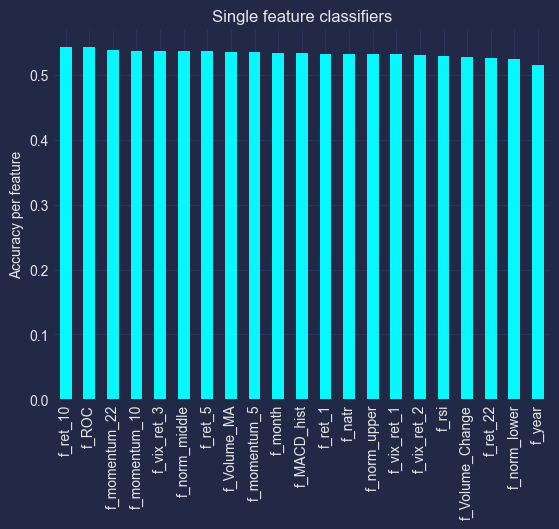

In [50]:
pd.Series(sel.feature_performance_).sort_values(ascending=False).plot.bar()
plt.ylabel("Accuracy per feature")
plt.title("Single feature classifiers")

### Backtesting

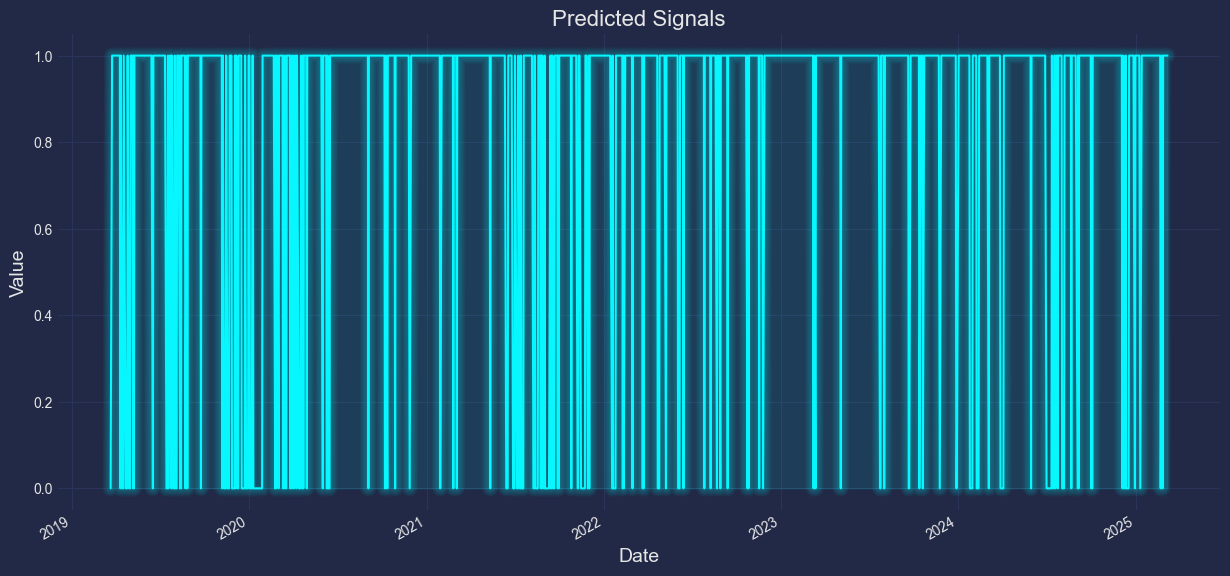

In [51]:
# Compute and store the predicted signal
df['predicted_signal'] = random_search.predict(X)

# Plot the predicted signal
plt.figure(figsize=(15, 7))
df.iloc[split:].predicted_signal.plot()

# Set the title and axes labels
plt.title('Predicted Signals', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Value', fontsize=14)
mplcyberpunk.add_glow_effects()
plt.show()

Looking at the predicted signals, it becomes evident that this model would generate a high number of trades, the frequent trading could lead to significant transaction costs. These costs would likely erode any potential profits, making it crucial to incorporate a strategy that limits unnecessary trades—perhaps by introducing a threshold or adjusting the frequency of predictions.

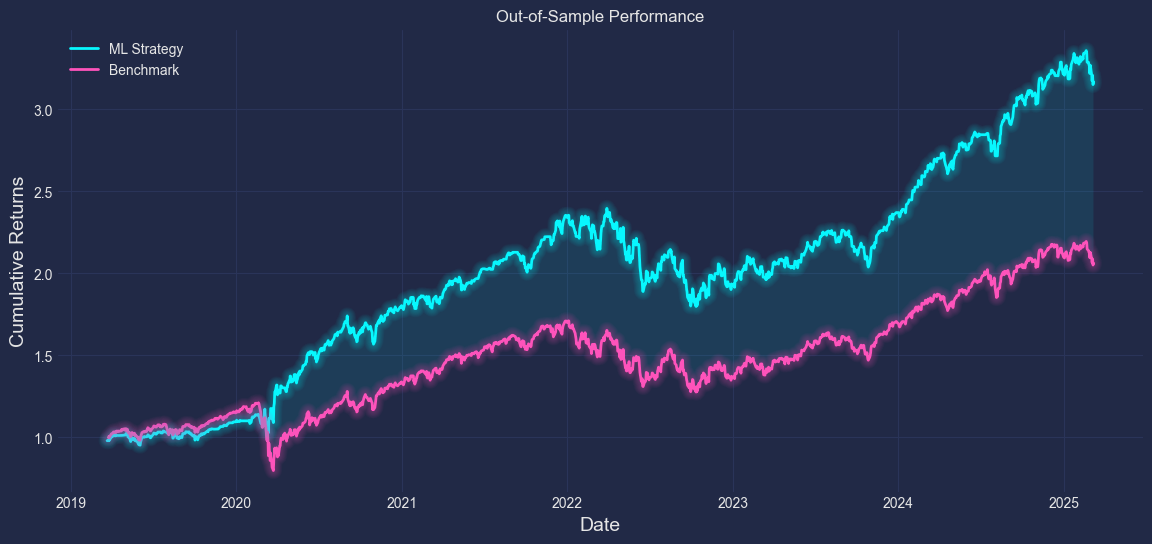

Benchmark returns: 2.06
Strategy returns: 3.17
Benchmark Sharpe: 0.71
ML Strategy Sharpe: 1.2


In [52]:
# Calculate strategy returns for out-of-sample period
df['strategy_returns'] = df.Close.pct_change() * df.predicted_signal.shift(1)
test_data = df.iloc[split:]

# Plot the returns
plt.figure(figsize=(14, 6))

# Calculate cumulative returns
benchmark_returns = (test_data.Close.pct_change()+1).cumprod()
strategy_returns = (test_data['strategy_returns']+1).cumprod()

# Plot both lines
plt.plot(strategy_returns, label='ML Strategy', lw=2)
plt.plot(benchmark_returns, label='Benchmark', lw=2)

# Titles and labels
plt.title('Out-of-Sample Performance')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Cumulative Returns', fontsize=14)
# Add glow effect between the two lines
# Apply cyberpunk effects
# mplcyberpunk.add_glow_effects()
plt.fill_between(test_data.index, benchmark_returns, strategy_returns, where=(strategy_returns > benchmark_returns), alpha=0.1)
plt.fill_between(test_data.index, benchmark_returns, strategy_returns, where=(strategy_returns < benchmark_returns), alpha=0.1)

plt.legend()
mplcyberpunk.make_lines_glow()
plt.show()

# Print total returns
print(f"Benchmark returns: {round(benchmark_returns.iloc[-1],2)}")
print(f"Strategy returns: {round(strategy_returns.iloc[-1],2)}")

# Function to compute Sharpe ratio
def get_sr(ret):
    return round(ret.mean()/ret.std()*252**0.5, 2)

# Print the Sharpe ratios for the strategies
print(f"Benchmark Sharpe: {get_sr(test_data.Close.pct_change())}")
print(f"ML Strategy Sharpe: {get_sr(test_data['strategy_returns'])}")

The backtest results indicate that the decision tree strategy's Sharpe ratio is notably higher at 1.2, compared to the buy-and-hold strategy's Sharpe ratio of 0.71. While this suggests that the model has outperformed the benchmark, there are signs of overfitting, meaning these results might not hold across different timeframes. Despite the potential overfitting, it's important to note that the decision tree model, which was intended as a baseline for this project, appears to perform quite well in this specific instance. Further validation across various periods and additional robustness checks would be necessary to confirm its effectiveness in other market conditions.

## Random Forest

Next, we will follow a similar approach but utilize a Random Forest Classifier as our model. This ensemble method, which aggregates multiple decision trees, aims to improve predictive performance and reduce overfitting compared to a single decision tree.

In [53]:
df = data.copy()
df.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2005-03-15,82.454544,120.139999,121.459999,120.080002,121.419998,62438500
2005-03-16,81.754440,119.120003,120.160004,118.900002,119.699997,74874200
2005-03-17,81.919174,119.360001,119.739998,118.980003,119.309998,62584200
2005-03-18,81.675919,118.540001,119.529999,118.150002,119.110001,60232000
2005-03-21,81.372765,118.099998,118.779999,117.760002,118.709999,61244300


### Feature Engineering

In [54]:
# Define time periods to calculate returns
intervals = [1, 2]

# Loop to calculate log returns for time periods specified in 'intervals'
for t in intervals:
    # Create new columns for features in 'df' and store the value of returns
    df[f'f_ret_{t}'] = df.Close.pct_change(t)

# Display the data
df.dropna(inplace=True)
df.tail()

,Adj Close,Close,High,Low,Open,Volume,f_ret_1,f_ret_2
Date,,,,,,,,
2025-03-03,583.770020,583.770020,597.340027,579.900024,596.179993,74249200,-0.017520,-0.002188
2025-03-04,576.859985,576.859985,585.390015,572.250000,579.710022,109648200,-0.011837,-0.029149
2025-03-05,583.059998,583.059998,584.880005,573.080017,576.690002,71230500,0.010748,-0.001216
2025-03-06,572.710022,572.710022,580.169983,570.119995,575.479980,80094900,-0.017751,-0.007194
2025-03-07,575.919983,575.919983,577.390015,565.630005,570.900024,81158800,0.005605,-0.012246


In [55]:
kf = KalmanFilter(transition_matrices = [1],
                  observation_matrices = [1],
                  initial_state_mean = 0,
                  initial_state_covariance = 1,
                  observation_covariance=1,
                  transition_covariance=.01)

Next, we will introduce a new feature by applying a Kalman filter to the daily returns. The Kalman filter helps smooth noisy return data, capturing the underlying trend more effectively. This can improve model stability by reducing the impact of short-term fluctuations and market noise, potentially enhancing predictive performance.

In [56]:
state_means, _ = kf.filter(df['f_ret_1'])
# Add the filtered values as a new column
df['f_ret_1_kalman_filtered'] = state_means

In [57]:
# Calculate and store the NATR values
df['f_natr'] = ta.NATR(df.High, df.Low, df.Close)

To improve the performance of the Random Forest model, we reduced the number of features, as the initial model, when given too many features, tended to overfit by consistently predicting positive next-day returns. By selecting only the most relevant features, we aim to create a more balanced and generalizable model that better captures the underlying market dynamics.

In [58]:
# Store features data in 'features'
features = df.filter(like='f_')

# Display the last 5 rows
features.tail()

,f_ret_1,f_ret_2,f_ret_1_kalman_filtered,f_natr
Date,,,,
2025-03-03,-0.017520,-0.002188,-0.002540,1.387304
2025-03-04,-0.011837,-0.029149,-0.003424,1.466345
2025-03-05,0.010748,-0.001216,-0.002076,1.491685
2025-03-06,-0.017751,-0.007194,-0.003567,1.571556
2025-03-07,0.005605,-0.012246,-0.002695,1.597022


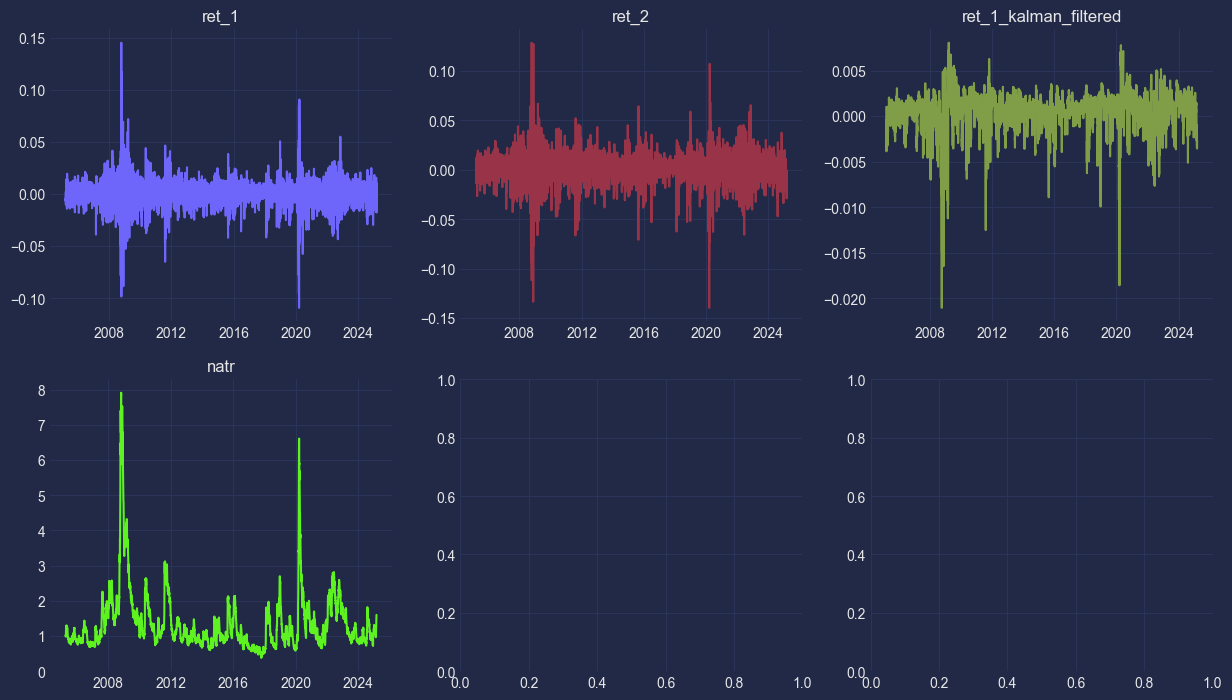

In [59]:
# Get the total count of features
num_of_features = len(features.columns)

# Define the layout and size for subplots
fig, axs = plt.subplots(int(num_of_features/3)+1, 3,
                        figsize=(15, 5*(num_of_features+1)/3))
axs = axs.ravel()
mplcyberpunk.add_glow_effects()

# Loop to plot the individual features
for i in range(num_of_features):
    axs[i].plot(df[features.columns[i]], color=np.random.rand(3,))
    axs[i].set_title(features.columns[i].replace('f_',''))
    mplcyberpunk.add_glow_effects()

plt.show()

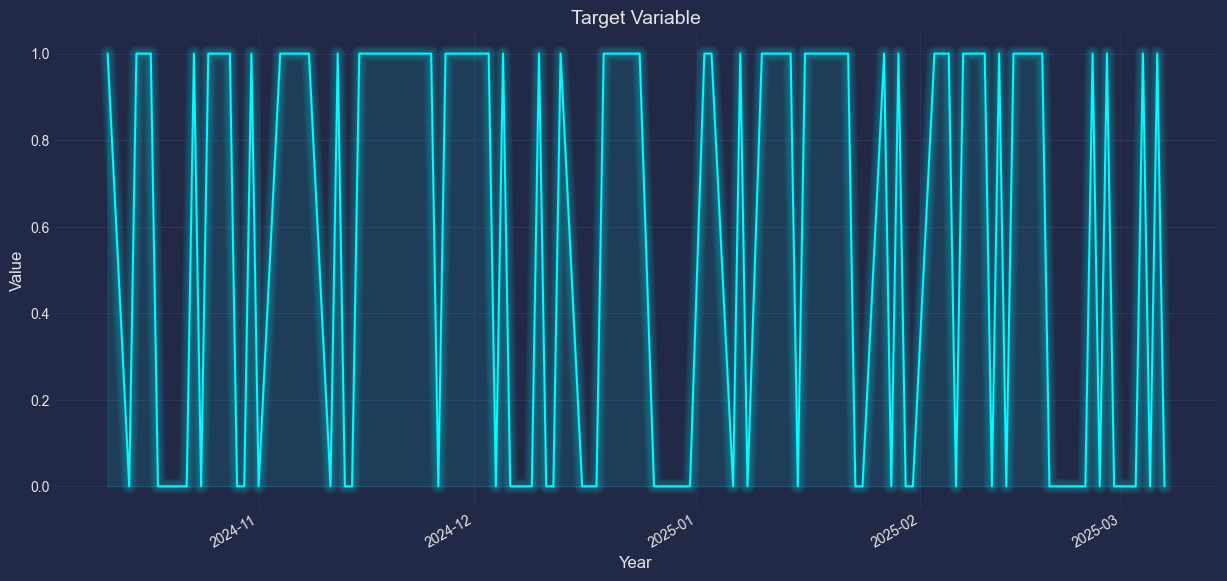

In [60]:
# Create the target variable
df['return'] = df.Close.pct_change(1).shift(-1)
df['target'] = np.where(df['return'] > 0, 1, 0)

# Plot the target
plt.figure(figsize=(15, 7))
df.iloc[-100:].target.plot()

# Set the title and axes labels
plt.title('Target Variable', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Value', fontsize=12)
mplcyberpunk.add_glow_effects()
plt.show()

In [61]:
# Store the features data in variable X
X = df.filter(like='f_')
X.tail()

,f_ret_1,f_ret_2,f_ret_1_kalman_filtered,f_natr
Date,,,,
2025-03-03,-0.017520,-0.002188,-0.002540,1.387304
2025-03-04,-0.011837,-0.029149,-0.003424,1.466345
2025-03-05,0.010748,-0.001216,-0.002076,1.491685
2025-03-06,-0.017751,-0.007194,-0.003567,1.571556
2025-03-07,0.005605,-0.012246,-0.002695,1.597022


In [62]:
# Store the target data in variable y
y = df['target']
y.tail()

Date
2025-03-03    0
2025-03-04    1
2025-03-05    0
2025-03-06    1
2025-03-07    0
Name: target, dtype: int32

In [63]:
# Set the split threshold
split_percentage = 0.7
split = int(split_percentage*len(X))

# Train dataset
X_train = X[:split]
y_train = y[:split]

# Test dataset
X_test = X[split:]
y_test = y[split:]

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(3518, 4) (3518,)
(1508, 4) (1508,)


### Random Forest Model

Next, we again use arbitrary shallow depth hyperparameters to mitigate overfitting when we instantiate a random forest model.

In [64]:
# fit model

rf =RandomForestClassifier(
    criterion="gini",
    n_estimators=3,
    max_depth=3,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=3, n_estimators=3,
                       random_state=42)

In [65]:
y_pred_test = rf.predict(X_test)
y_pred_train = rf.predict(X_train)

In [66]:
# Evaluate the model on the train dataset
accuracy_train = accuracy_score(y_train, y_pred_train)
precision_train = precision_score(y_train, y_pred_train, average='binary')
recall_train = recall_score(y_train, y_pred_train, average='binary')
f1_train = f1_score(y_train, y_pred_train, average='binary')

print('\nTrain Accuracy: {:.2f}%'.format(accuracy_train * 100))
print('Train Precision: {:.2f}%'.format(precision_train * 100))
print('Train Recall: {:.2f}%'.format(recall_train * 100))
print('Train F1 Score: {:.2f}%'.format(f1_train * 100))

# Evaluate the model on the test dataset
accuracy_test = accuracy_score(y_test, y_pred_test)
precision_test = precision_score(y_test, y_pred_test, average='binary')
recall_test = recall_score(y_test, y_pred_test, average='binary')
f1_test = f1_score(y_test, y_pred_test, average='binary')

print('\nTest Accuracy: {:.2f}%'.format(accuracy_test * 100))
print('Test Precision: {:.2f}%'.format(precision_test * 100))
print('Test Recall: {:.2f}%'.format(recall_test * 100))
print('Test F1 Score: {:.2f}%'.format(f1_test * 100))


Train Accuracy: 55.12%
Train Precision: 57.22%
Train Recall: 68.99%
Train F1 Score: 62.56%

Test Accuracy: 54.71%
Test Precision: 57.14%
Test Recall: 71.24%
Test F1 Score: 63.42%


This initial attempt appears promising, as the training and test accuracies are closely aligned. However, the model still generates a high number of false positives.

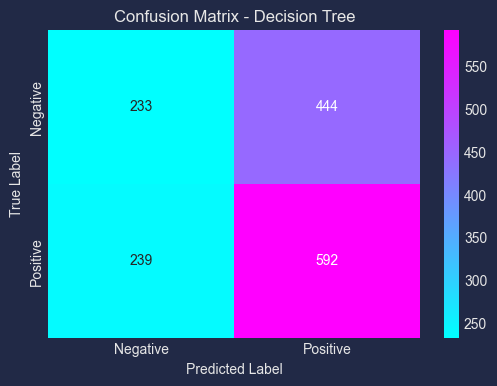

In [67]:
# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

# Define class labels
labels = ["Negative", "Positive"]

# Plot the confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="cool", xticklabels=labels, yticklabels=labels)

# Labels, title, and axis names
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Decision Tree")

plt.show()

### Hyperparameter Tuning

In [68]:
# Define the hyperparameter grid
param_dist = {
    'n_estimators': randint(2, 100),  # Number of trees
    'max_depth': randint(1, 20),       # Tree depth
    'min_samples_split': randint(2, 20),  
    'min_samples_leaf': randint(1, 20),
}

We will next tune the hyperparameters using randomized search.

In [69]:
# Initialize Random Forest model
rf = RandomForestClassifier(random_state=42)

In [70]:
# Perform Randomized Search
random_search = RandomizedSearchCV(
    rf, param_distributions=param_dist, 
    n_iter=500,  # Number of random combinations to try
    cv=5,       # 5-fold cross-validation
    scoring='accuracy',  # Metric to optimize
    n_jobs=-1,   # Use all available CPU cores
    random_state=42
)

# Fit search
random_search.fit(X_train, y_train)

C:\Users\Andrew\anaconda3\envs\env\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=500, n_jobs=-1,
                   param_distributions={'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000016BF2A026C0>,
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000016BF310D880>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000016BF2A1DC10>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000016BF2A4E480>},
                   random_state=42, scoring='accuracy')

In [71]:
# Best hyperparameters
print("Best Hyperparameters:", random_search.best_params_)

Best Hyperparameters: {'max_depth': 3, 'min_samples_leaf': 12, 'min_samples_split': 17, 'n_estimators': 52}


In [72]:
# Train final model with best parameters
best_rf = random_search.best_estimator_
accuracy = best_rf.score(X_test, y_test)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.5603448275862069


In [73]:
y_pred_test = best_rf.predict(X_test)
y_pred_train = best_rf.predict(X_train)

In [74]:
# Evaluate the model on the train dataset
accuracy_train = accuracy_score(y_train, y_pred_train)
precision_train = precision_score(y_train, y_pred_train, average='binary')
recall_train = recall_score(y_train, y_pred_train, average='binary')
f1_train = f1_score(y_train, y_pred_train, average='binary')

print('\nTrain Accuracy: {:.2f}%'.format(accuracy_train * 100))
print('Train Precision: {:.2f}%'.format(precision_train * 100))
print('Train Recall: {:.2f}%'.format(recall_train * 100))
print('Train F1 Score: {:.2f}%'.format(f1_train * 100))

# Evaluate the model on the test dataset
accuracy_test = accuracy_score(y_test, y_pred_test)
precision_test = precision_score(y_test, y_pred_test, average='binary')
recall_test = recall_score(y_test, y_pred_test, average='binary')
f1_test = f1_score(y_test, y_pred_test, average='binary')

print('\nTest Accuracy: {:.2f}%'.format(accuracy_test * 100))
print('Test Precision: {:.2f}%'.format(precision_test * 100))
print('Test Recall: {:.2f}%'.format(recall_test * 100))
print('Test F1 Score: {:.2f}%'.format(f1_test * 100))


Train Accuracy: 55.66%
Train Precision: 55.33%
Train Recall: 95.55%
Train F1 Score: 70.08%

Test Accuracy: 56.03%
Test Precision: 56.27%
Test Recall: 90.73%
Test F1 Score: 69.46%


After hyperparameter tuning, the test accuracy improved to 56%, surpassing the training accuracy. However, the increase in recall suggests that the model is still biased toward predicting positive returns. On a positive note, the model correctly identifies more true negatives than false negatives.

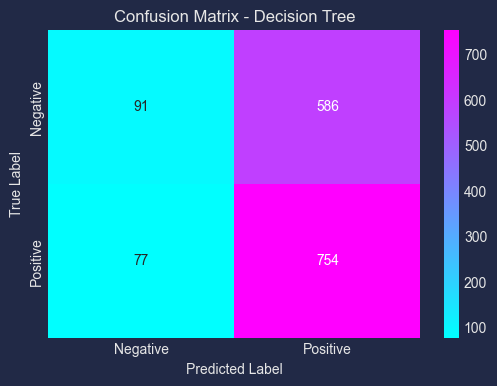

In [75]:
# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

# Define class labels
labels = ["Negative", "Positive"]

# Plot the confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="cool", xticklabels=labels, yticklabels=labels)

# Labels, title, and axis names
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Decision Tree")

plt.show()

### Interpretation

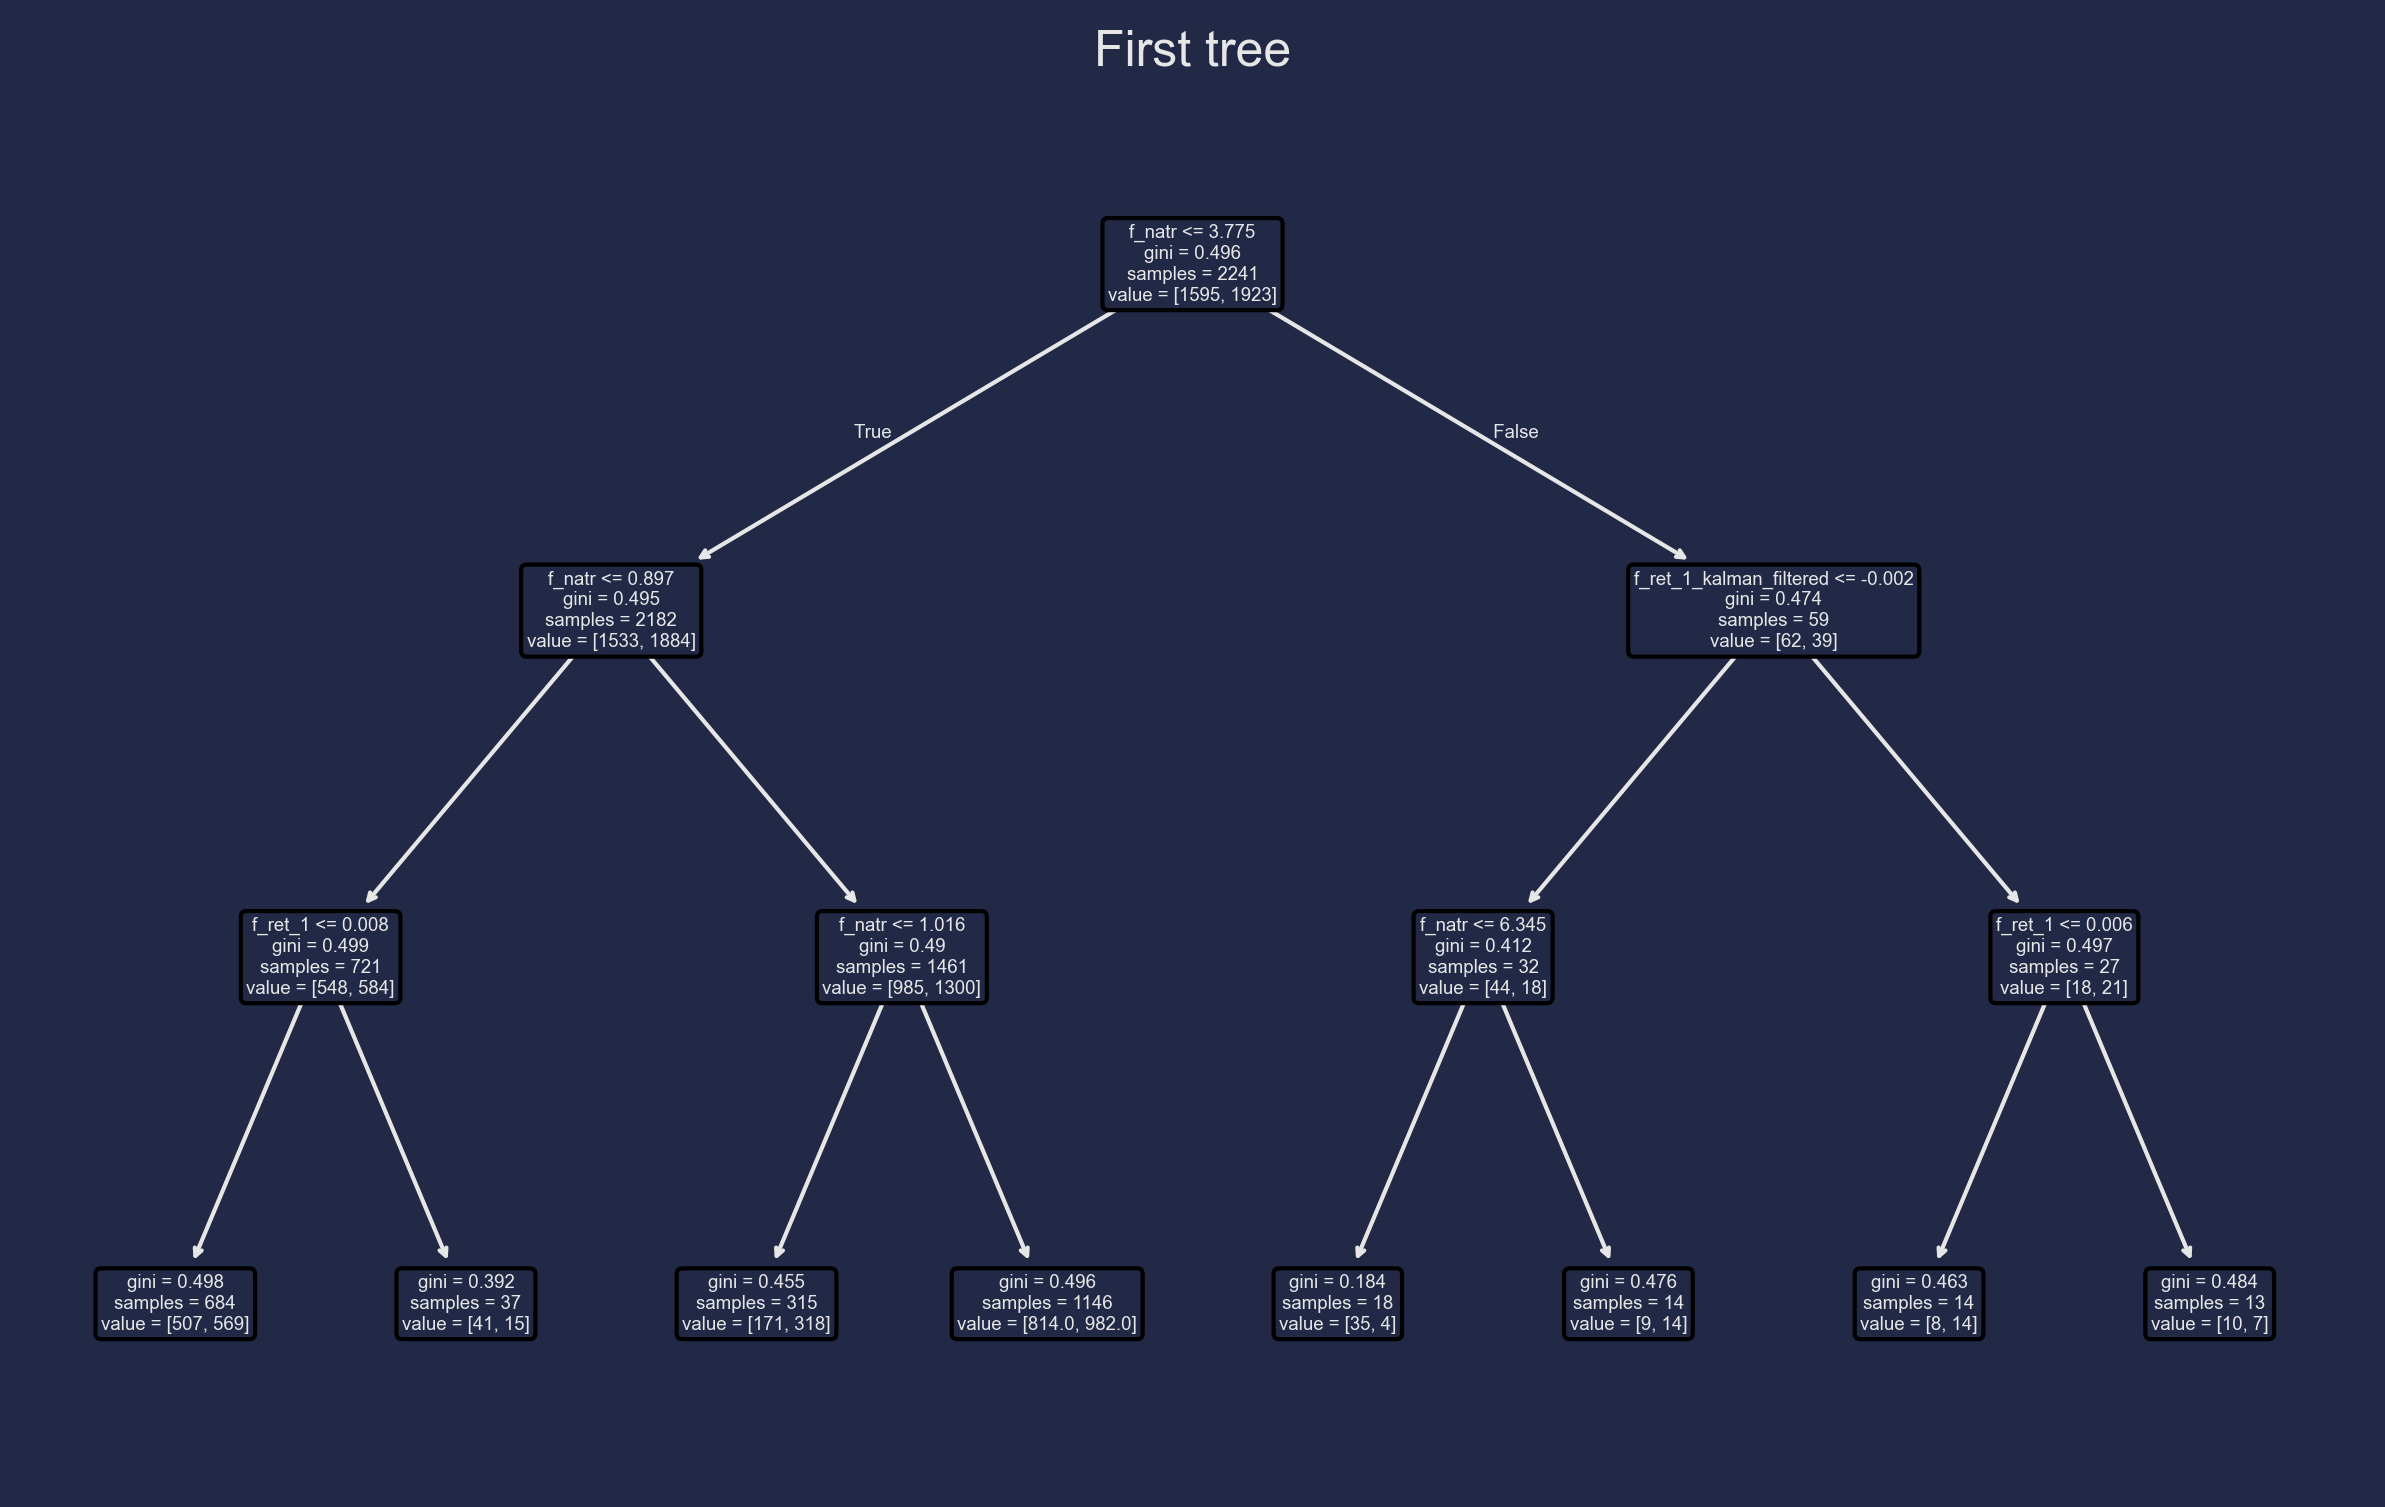

In [76]:
plt.figure(figsize=(10, 6), dpi=300)

plot_tree(
    decision_tree=best_rf.estimators_[0],
    feature_names=X_train.columns.to_list(),
    filled=False,  # color the squares
    rounded=True  # round squares
)
plt.title("First tree")
plt.show()

Plotting the first tree, we observe that the initial split is based on the normalized average true range (NATR). The left branch continues to split using NATR, while the right branch splits based on the Kalman-filtered returns. Subsequent splits on both sides primarily rely on the 1-day returns and NATR, indicating that the model heavily considers volatility and short-term price movements when making predictions.

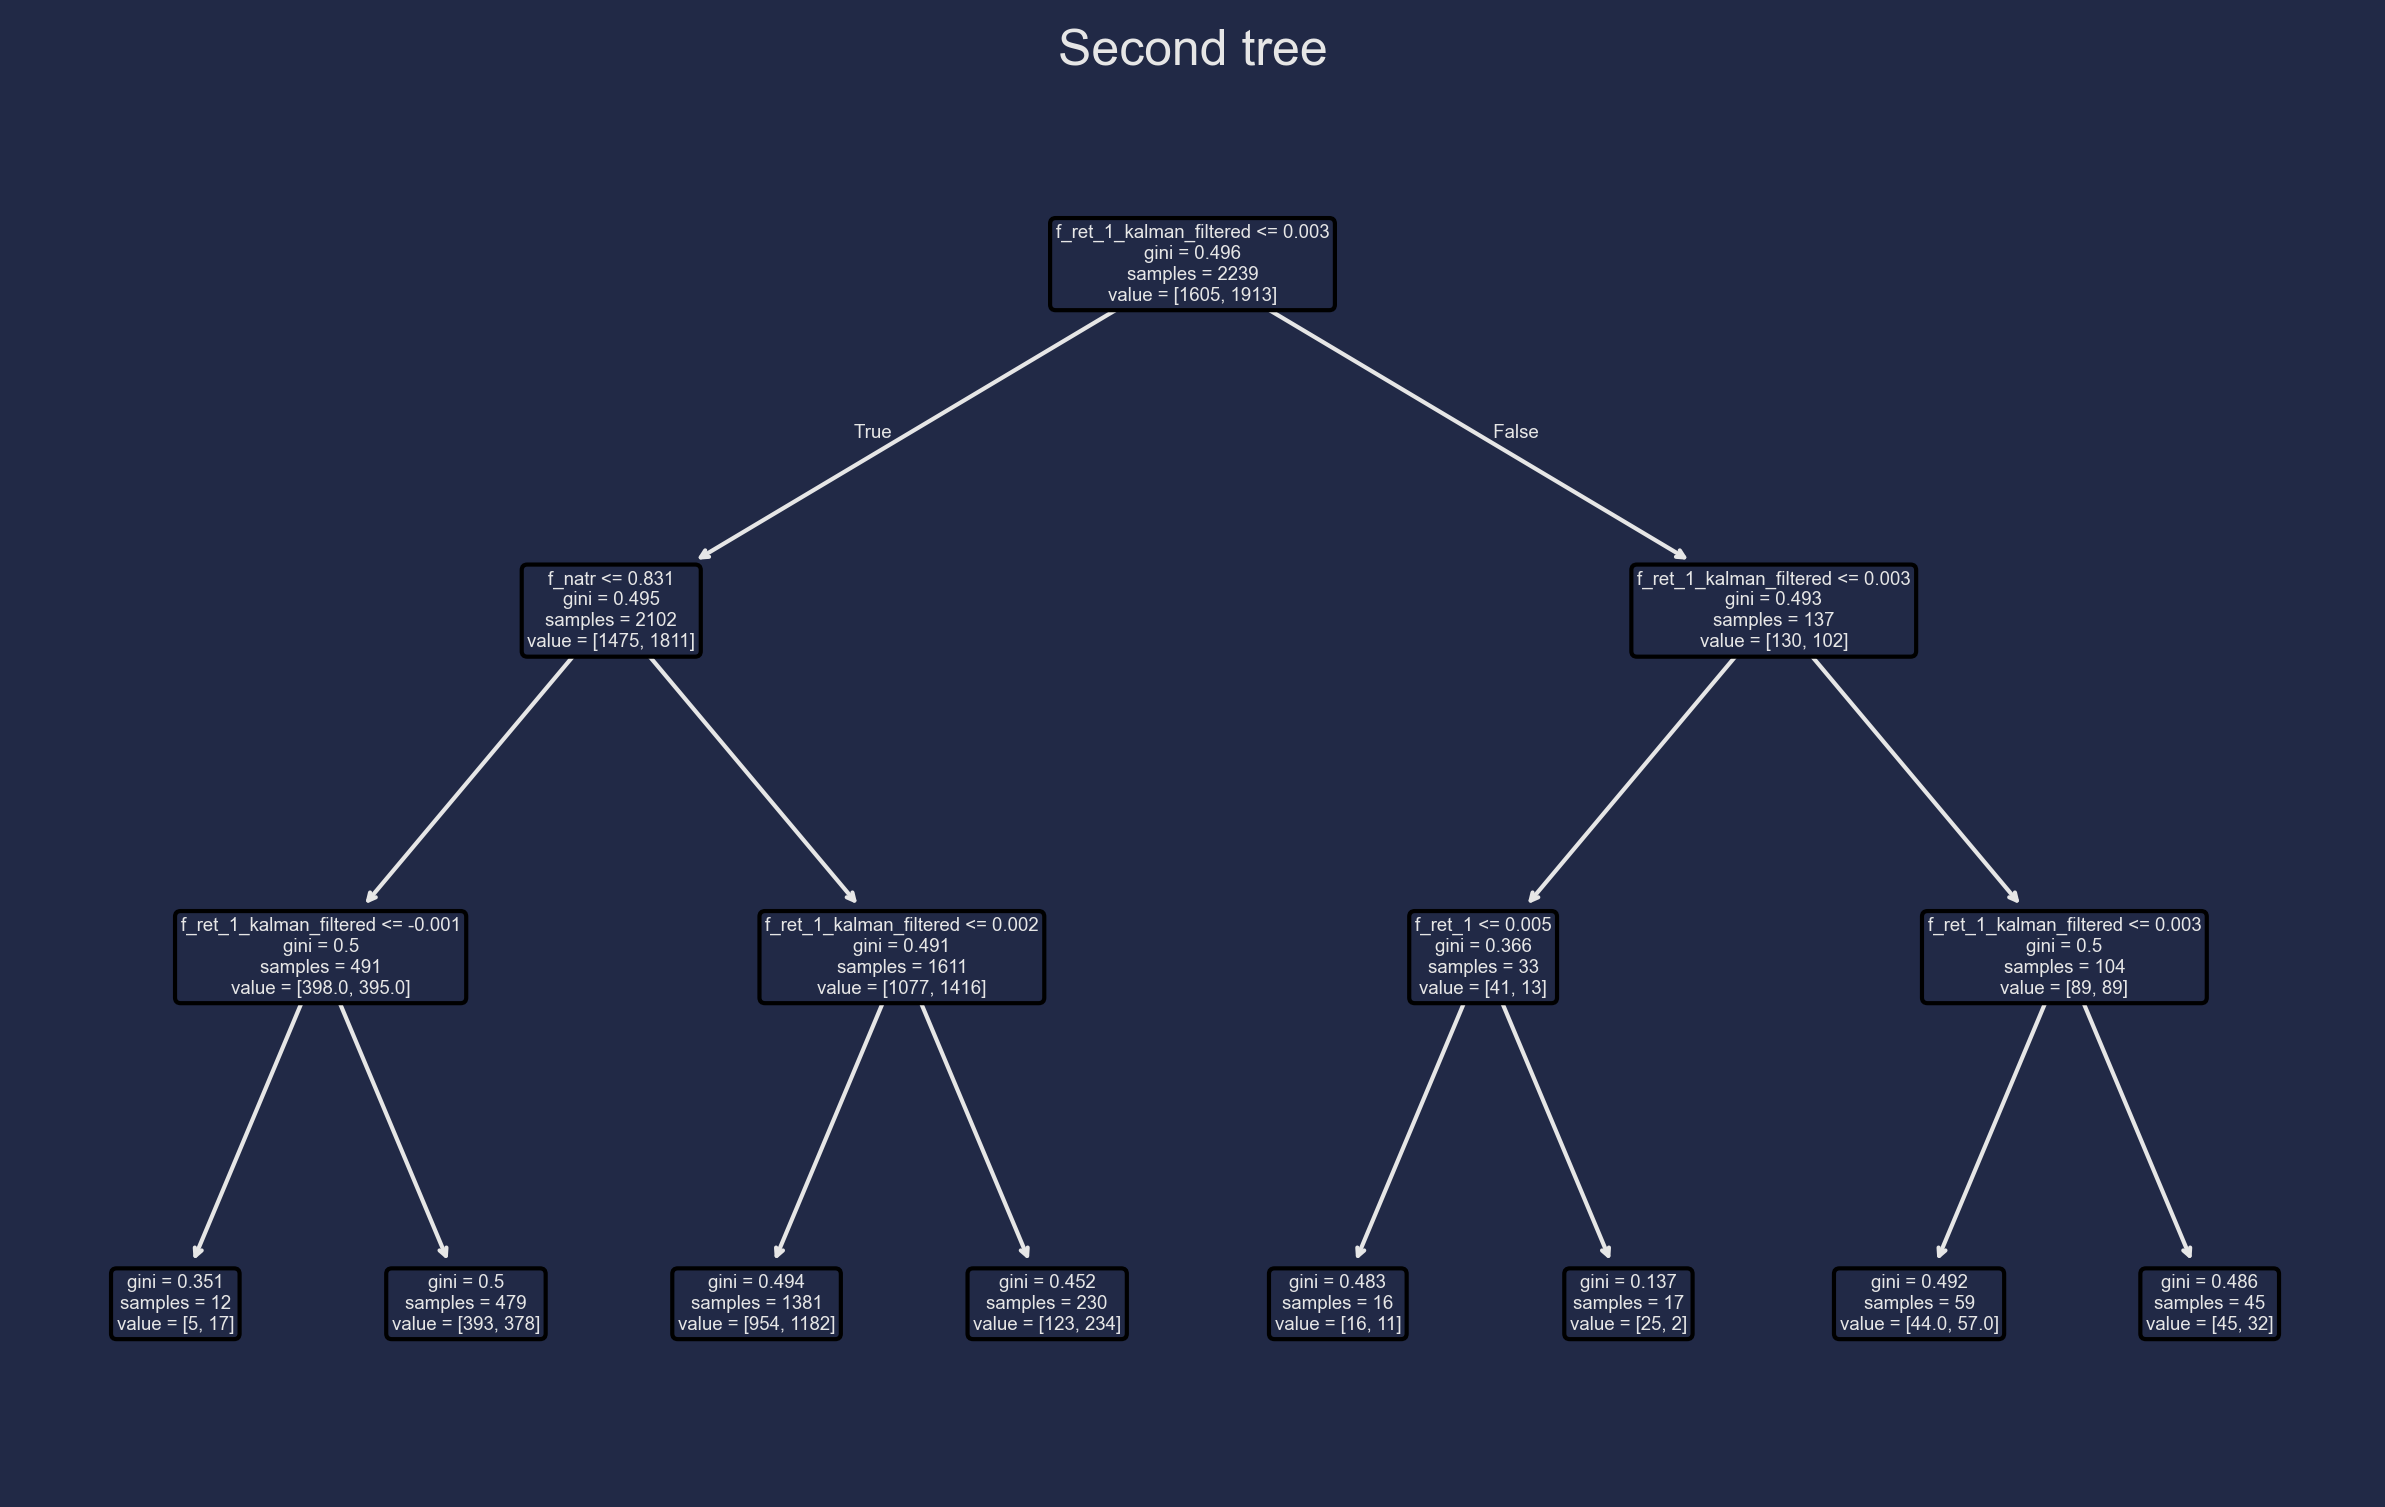

In [77]:
plt.figure(figsize=(10, 6), dpi=300)

plot_tree(
    decision_tree=best_rf.estimators_[1],
    feature_names=X_train.columns.to_list(),
    filled=False,  # color the squares
    rounded=True  # round squares
)
plt.title("Second tree")
plt.show()

The second tree begins with an initial split based on the Kalman-filtered returns. Similar to the first tree, the left branch continues to split using NATR, while the right branch relies on further splits using the Kalman-filtered returns. This reinforces the model's emphasis on volatility-adjusted returns and normalized price range as key decision factors.

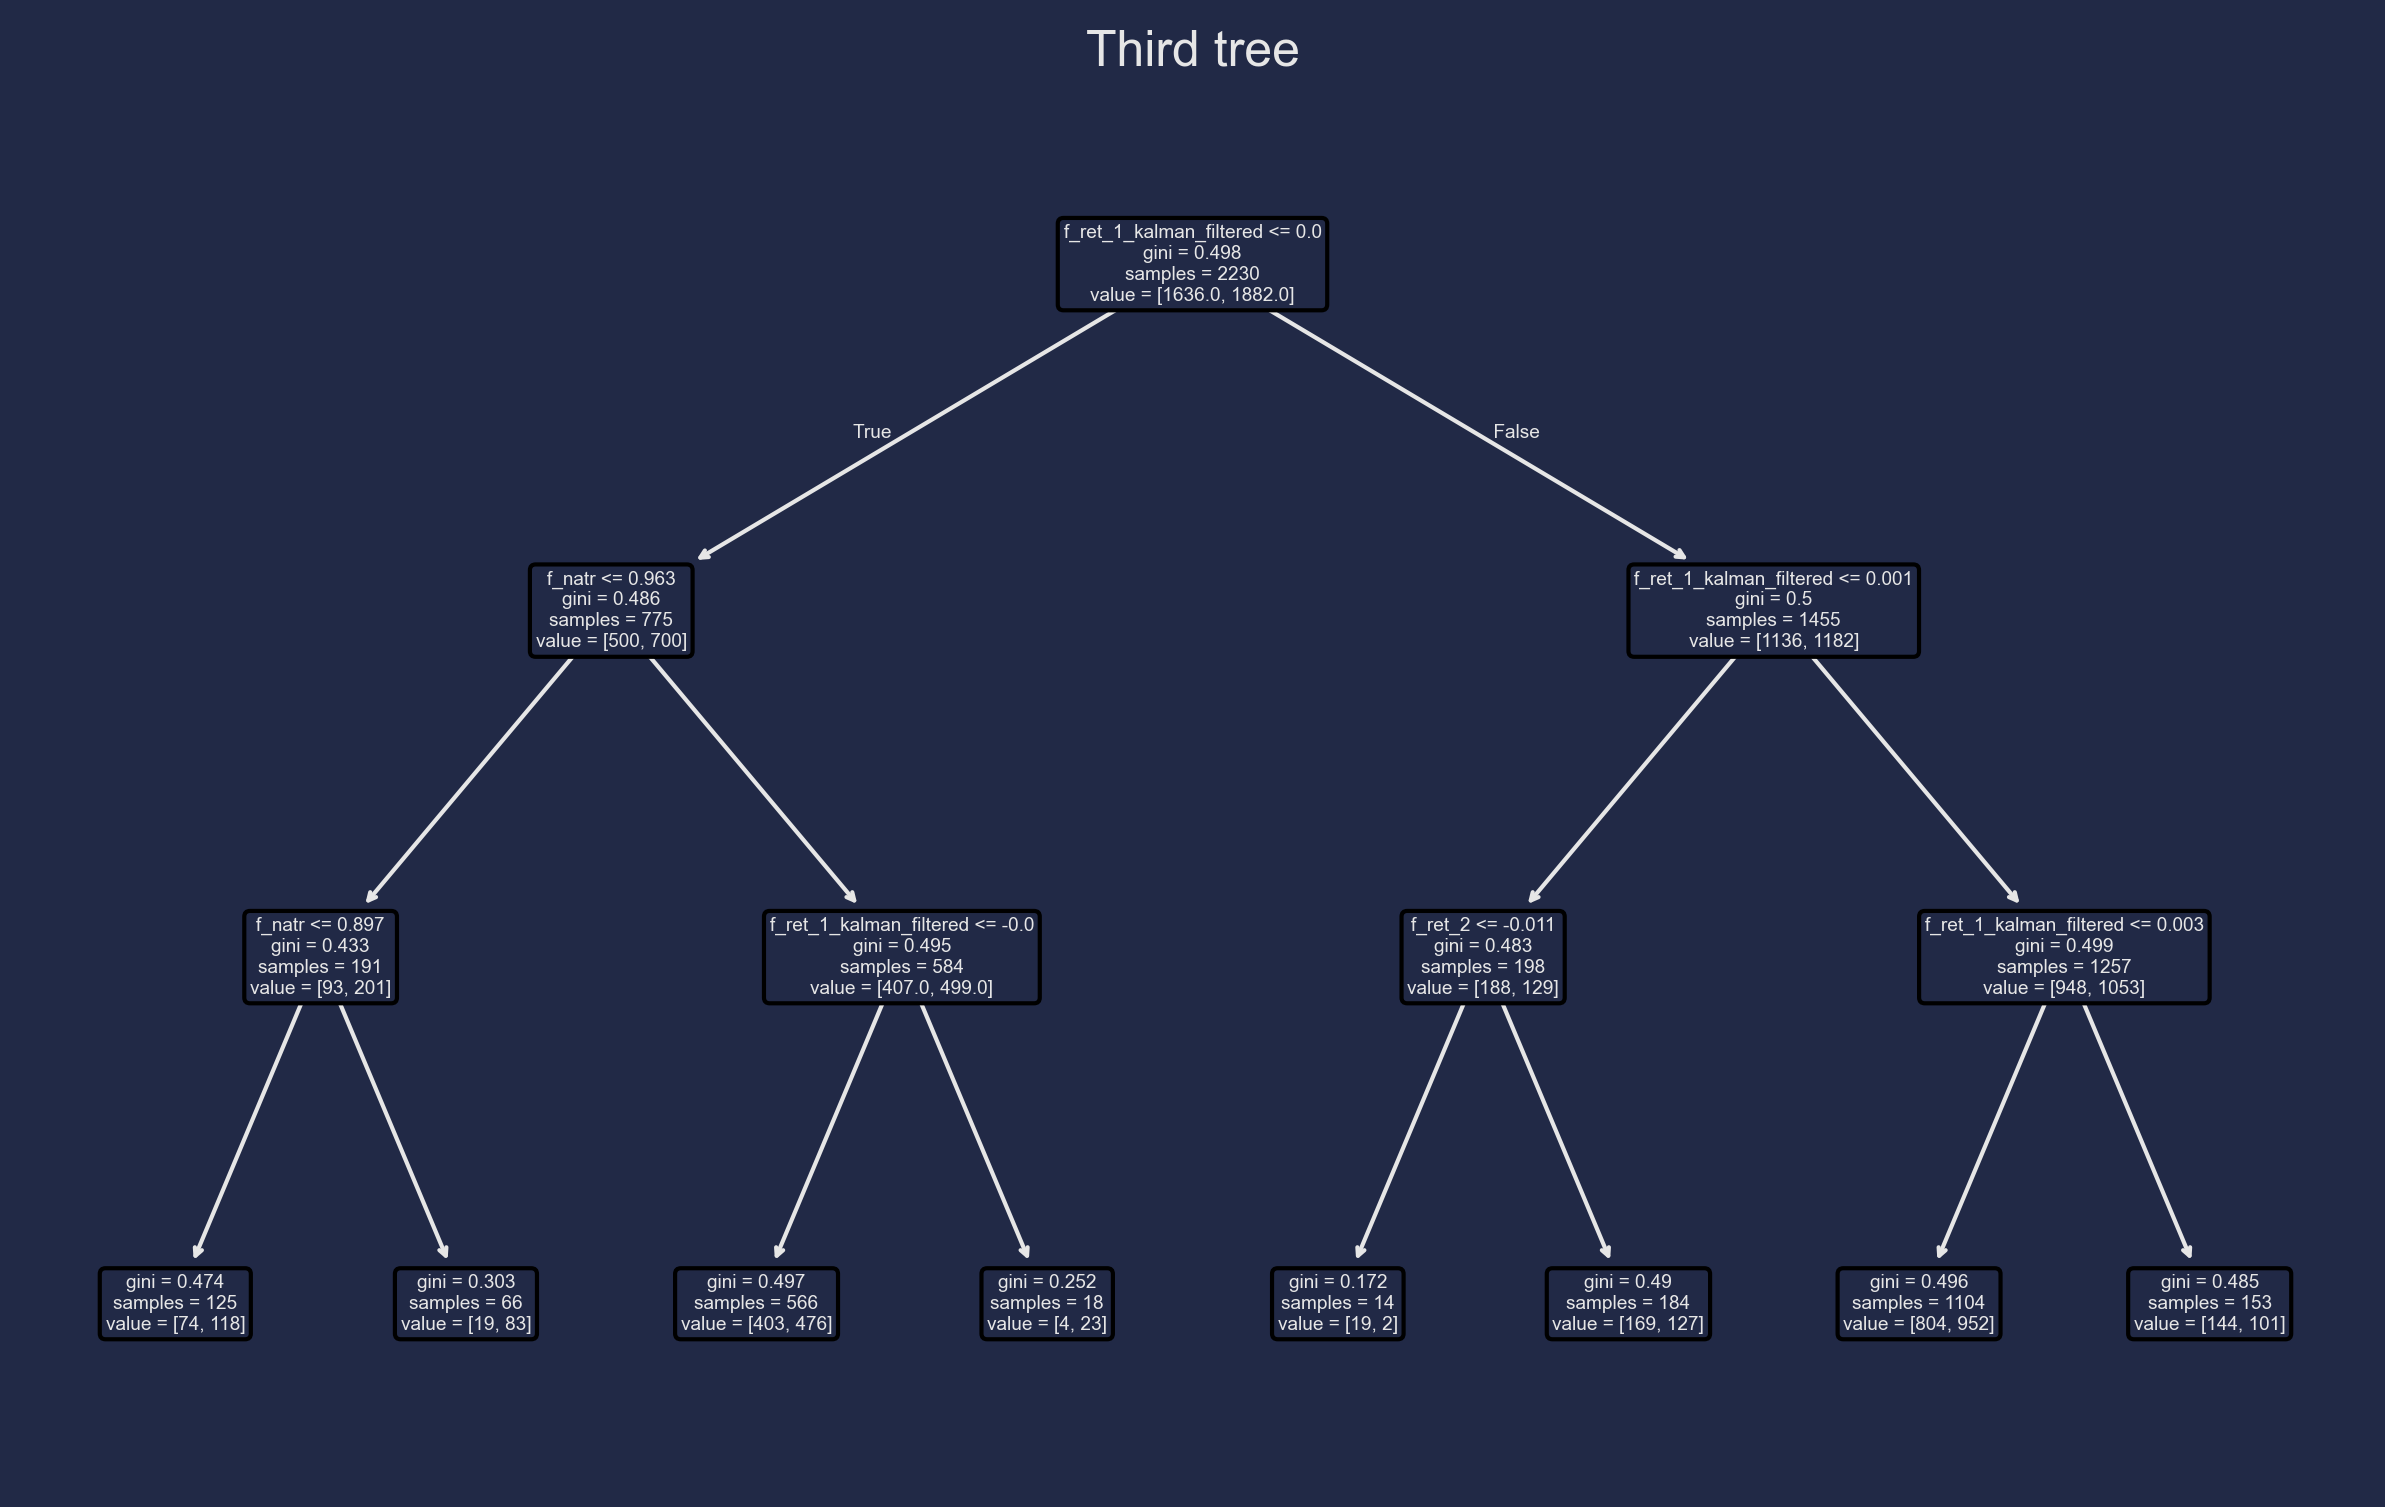

In [78]:
plt.figure(figsize=(10, 6), dpi=300)

plot_tree(
    decision_tree=best_rf.estimators_[2],
    feature_names=X_train.columns.to_list(),
    filled=False,  # color the squares
    rounded=True  # round squares
)
plt.title("Third tree")
plt.show()

The third tree is similar to the second tree.

In [79]:
# importance based on each tree

# Let's take the importance derived by each single decision tree

global_exp = pd.concat([
    pd.Series(best_rf.estimators_[0].feature_importances_),
    pd.Series(best_rf.estimators_[1].feature_importances_),
    pd.Series(best_rf.estimators_[2].feature_importances_),
], axis=1,
)

global_exp.columns = ["tree_1", "tree_2", "tree_3"]
global_exp.index = best_rf.feature_names_in_

global_exp["importance"] = global_exp.mean(axis=1)

global_exp

,tree_1,tree_2,tree_3,importance
f_ret_1,0.225551,0.095075,0.000000,0.106875
f_ret_2,0.000000,0.000000,0.094783,0.031594
f_ret_1_kalman_filtered,0.080925,0.718703,0.620562,0.473397
f_natr,0.693524,0.186222,0.284655,0.388134


Looking at the mean feature importance across the first three trees, it's clear that the Kalman-filtered returns and NATR (Normalized Average True Range) dominate the decision-making process, collectively accounting for approximately 85% of the total feature importance. This highlights the model's reliance on volatility-adjusted returns and price range volatility as the primary indicators for predicting next-day returns.

In [80]:
# random forest importance
global_exp = pd.Series(best_rf.feature_importances_, index=best_rf.feature_names_in_)

global_exp

f_ret_1                    0.222619
f_ret_2                    0.206464
f_ret_1_kalman_filtered    0.331416
f_natr                     0.239500
dtype: float64

Using the feature importance derived from the Random Forest model, we can see that the Kalman-filtered returns account for approximately 33% of the feature importance, making it the most influential predictor in the model. NATR follows with around 24%, while the 1-day and 2-day returns contribute roughly 22% and 21%, respectively. This suggests that both volatility-adjusted returns and recent price movements play a significant role in the model's decision-making process.

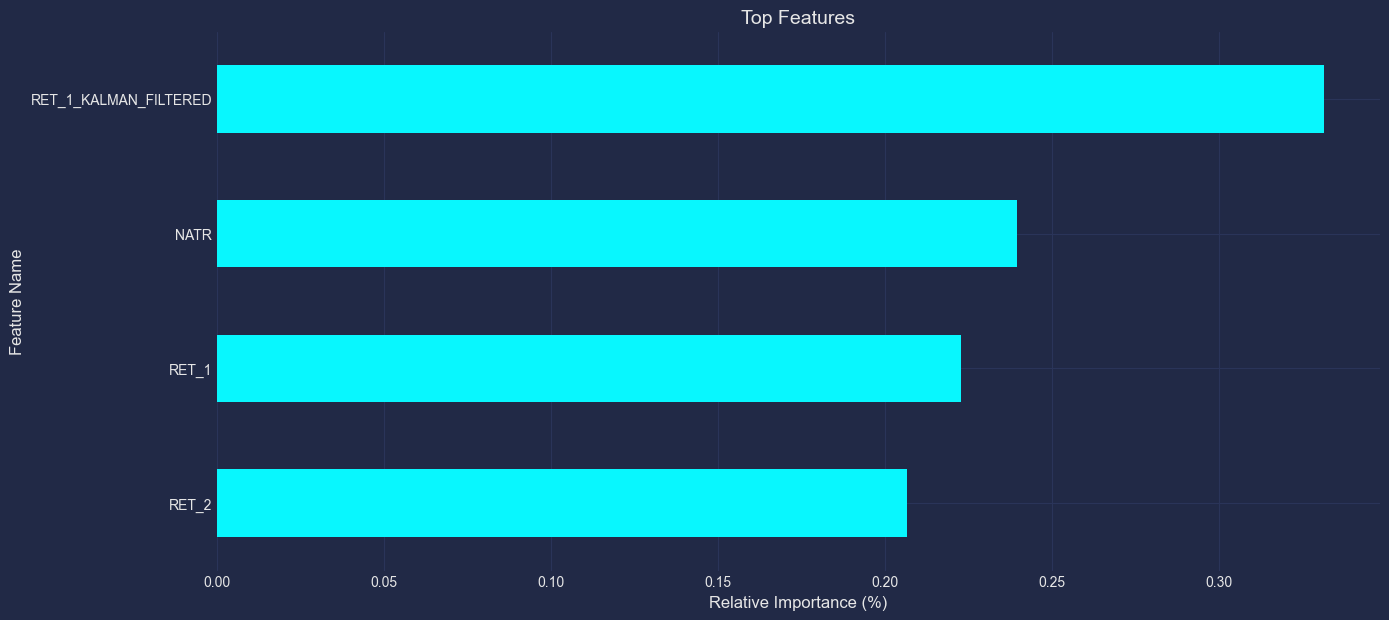

In [81]:
# Initialise the feature labels
labels = X.columns.str.replace('f_', '').str.upper()

# Calculate and sort the feature importances in descending order
feature_importance = (pd.Series(best_rf.feature_importances_,
                                index=labels).sort_values(ascending=False))

# Plot the feature ranking
plt.figure(figsize=(15, 7))
feature_importance.sort_values().plot.barh(title='Feature Importance')
plt.title(f'Top Features', fontsize=14)
plt.xlabel('Relative Importance (%)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.show()

### Backtesting

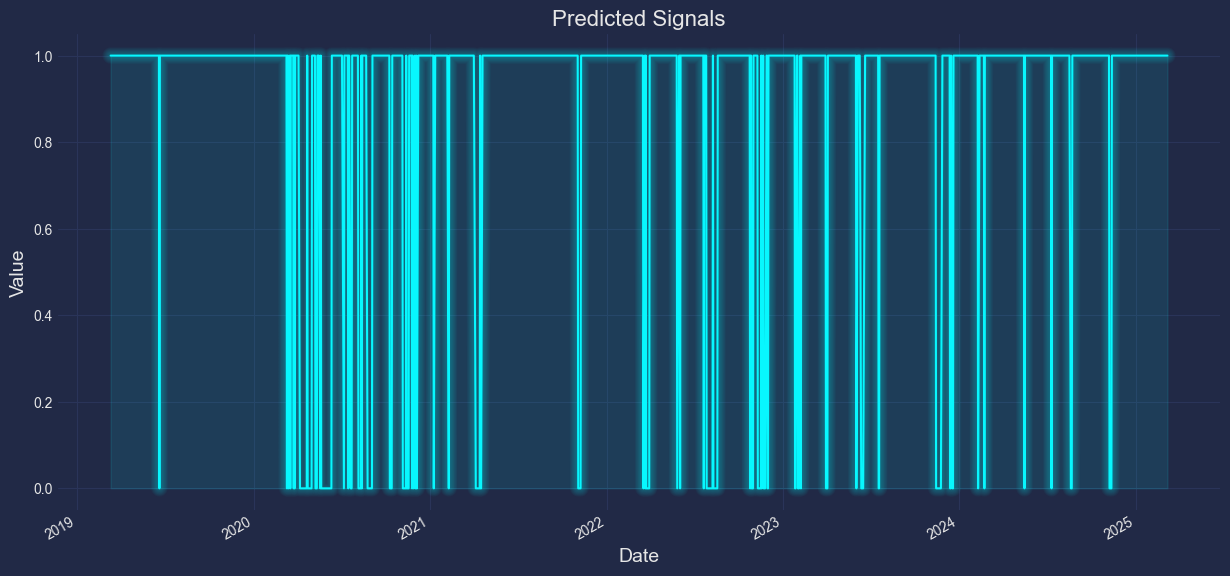

In [82]:
# Compute and store the predicted signal
df['predicted_signal'] = best_rf.predict(X)

# Plot the predicted signal
plt.figure(figsize=(15, 7))
df.iloc[split:].predicted_signal.plot()

# Set the title and axes labels
plt.title('Predicted Signals', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Value', fontsize=14)
mplcyberpunk.add_glow_effects()
plt.show()

The strategy using the Random Forest model trades less frequently than the Decision Tree model, which suggests that it might be more selective in its predictions. However, it still executes trades relatively often at certain points. While this is an improvement in terms of trade frequency, the model could still potentially benefit from further tuning to minimize overtrading and focus on higher-conviction signals.

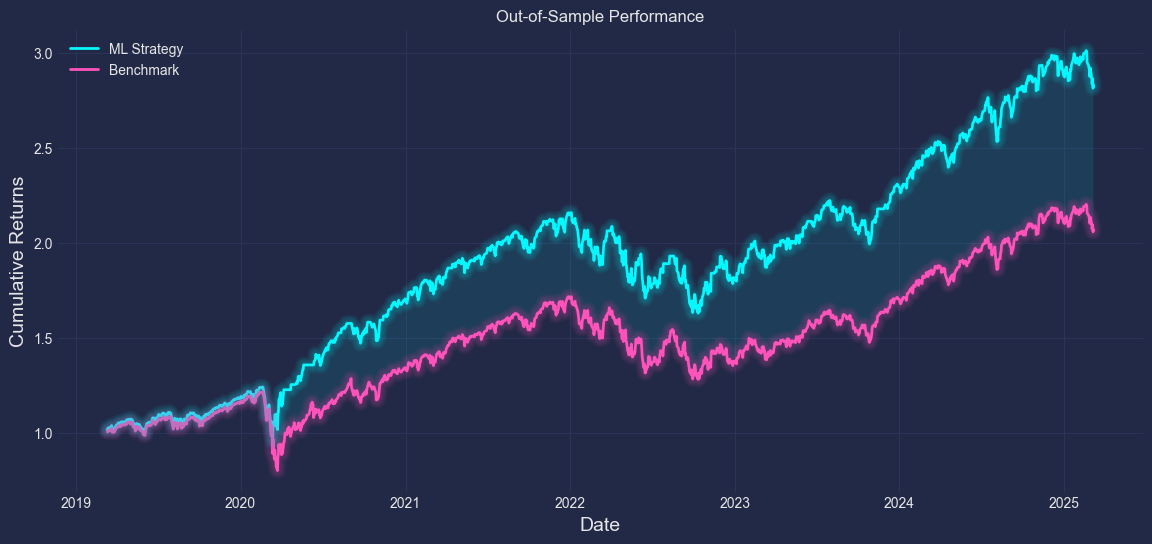

Benchmark returns: 2.07
Strategy returns: 2.83
Benchmark Sharpe: 0.71
ML Strategy Sharpe: 1.04


In [83]:
# Calculate strategy returns for out-of-sample period
df['strategy_returns'] = df.Close.pct_change() * df.predicted_signal.shift(1)
test_data = df.iloc[split:]

# Plot the returns
plt.figure(figsize=(14, 6))

# Calculate cumulative returns
benchmark_returns = (test_data.Close.pct_change()+1).cumprod()
strategy_returns = (test_data['strategy_returns']+1).cumprod()

# Plot both lines
plt.plot(strategy_returns, label='ML Strategy', lw=2)
plt.plot(benchmark_returns, label='Benchmark', lw=2)

# Titles and labels
plt.title('Out-of-Sample Performance')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Cumulative Returns', fontsize=14)
# Add glow effect between the two lines
# Apply cyberpunk effects
# mplcyberpunk.add_glow_effects()
plt.fill_between(test_data.index, benchmark_returns, strategy_returns, where=(strategy_returns > benchmark_returns), alpha=0.1)
plt.fill_between(test_data.index, benchmark_returns, strategy_returns, where=(strategy_returns < benchmark_returns), alpha=0.1)

plt.legend()
mplcyberpunk.make_lines_glow()
plt.show()

# Print total returns
print(f"Benchmark returns: {round(benchmark_returns.iloc[-1],2)}")
print(f"Strategy returns: {round(strategy_returns.iloc[-1],2)}")

# Function to compute Sharpe ratio
def get_sr(ret):
    return round(ret.mean()/ret.std()*252**0.5, 2)

# Print the Sharpe ratios for the strategies
print(f"Benchmark Sharpe: {get_sr(test_data.Close.pct_change())}")
print(f"ML Strategy Sharpe: {get_sr(test_data['strategy_returns'])}")

The Random Forest strategy outperformed the buy-and-hold strategy, achieving impressive returns of 283% with a Sharpe ratio of 1.04, compared to the buy-and-hold strategy's returns of 207% and a Sharpe ratio of 0.71 during the out-of-sample test period. This highlights the potential of the Random Forest model in capturing market movements more effectively, with better risk-adjusted returns, with less overfitting concerns than the decision tree model.

In [84]:
# Store probability of occurrence values in new dataframe
probability = (best_rf.predict_proba(X))

# Store the probability of occurrence values for each output separately
df['probability_0'], df['probability_1'] = probability[:,0], probability[:,1]

# Print the dataframe with probability of occurrence values
df.filter(like='prob').tail().round(3)

,probability_0,probability_1
Date,,
2025-03-03,0.426,0.574
2025-03-04,0.446,0.554
2025-03-05,0.437,0.563
2025-03-06,0.439,0.561
2025-03-07,0.455,0.545


Next, we will explore whether setting probability thresholds for classifying returns as `0` or `1` can enhance the strategy’s performance. By adjusting these thresholds, we aim to reduce false positives and improve the overall precision of trade signals.

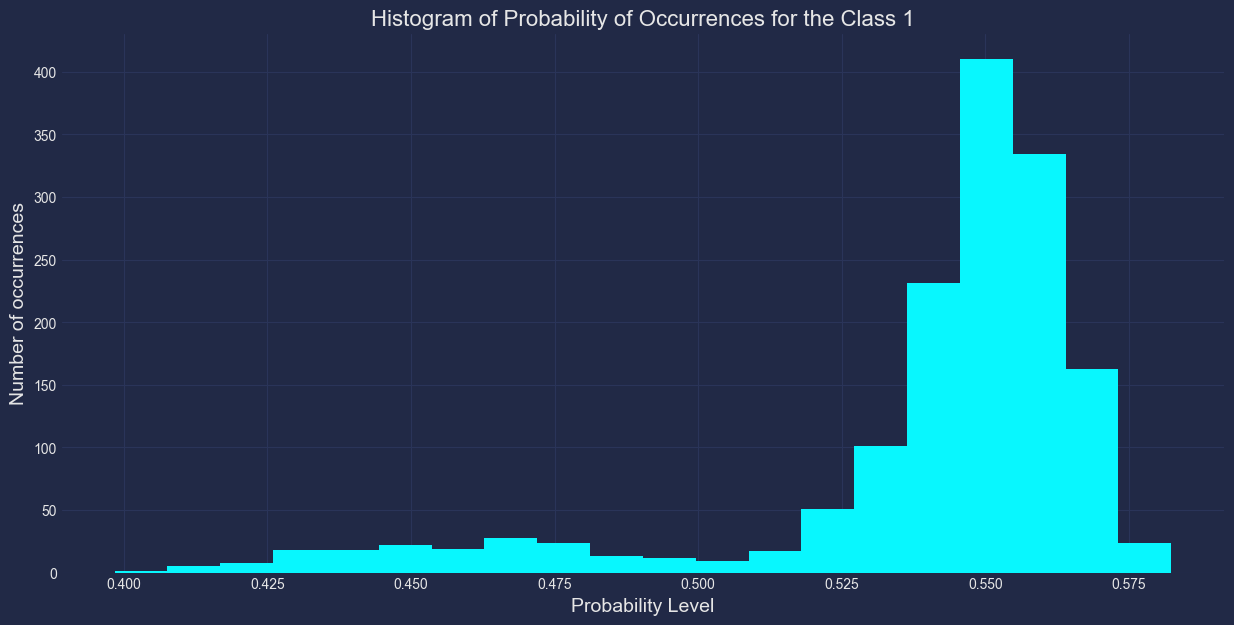

In [85]:
# Declare train and test percentage and split the dataset
split_percentage = 0.7
split = int(split_percentage*len(X))

# Create a new dataframe to store the test data
test_data = df.iloc[split:]

# Plot the probability values in a histogram
test_data.probability_1.hist(bins=20, figsize = (15,7))
# Set title
plt.title('Histogram of Probability of Occurrences for the Class 1', fontsize=16)
# Set x and y axis labels
plt.xlabel('Probability Level', fontsize=14)
plt.ylabel('Number of occurrences', fontsize=14)
plt.show()

From the histogram, we observe that the probability of a `1` has a peak around 0.550. This suggests that the model tends to predict positive returns with moderate confidence, which may warrant adjusting the probability threshold to improve classification performance.

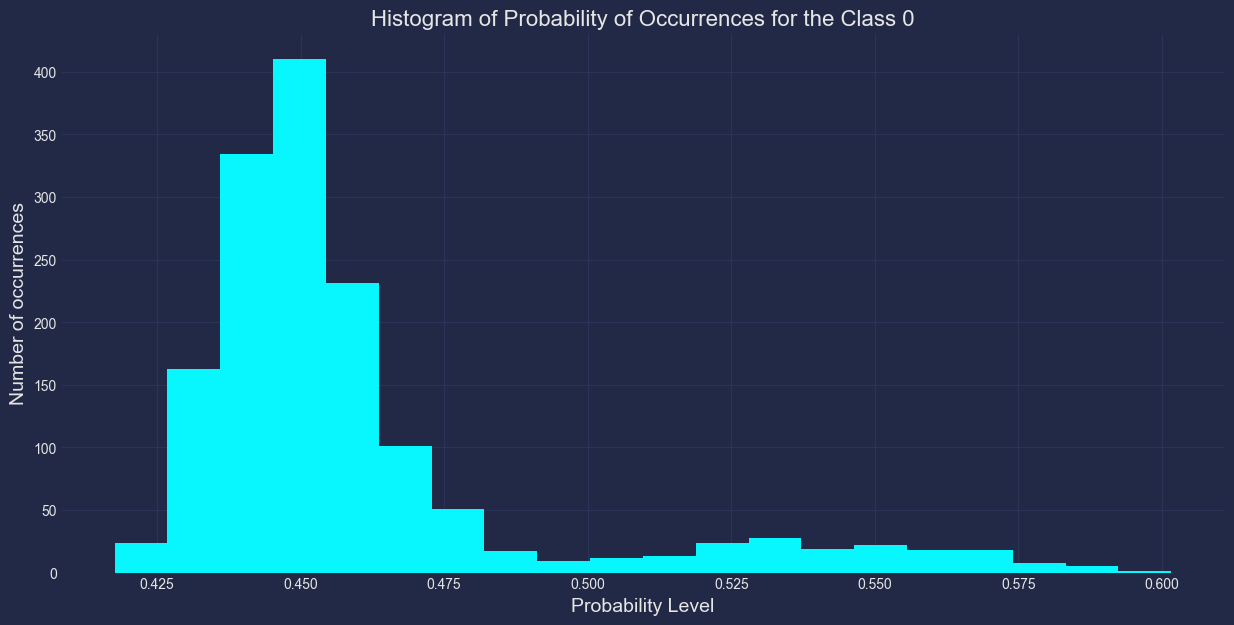

In [86]:
# Create a new dataframe to store the test data
test_data = df.iloc[split:]

# Plot the probability values in a histogram
test_data.probability_0.hist(bins=20, figsize = (15,7))
# Set title
plt.title('Histogram of Probability of Occurrences for the Class 0', fontsize=16)
# Set x and y axis labels
plt.xlabel('Probability Level', fontsize=14)
plt.ylabel('Number of occurrences', fontsize=14)
plt.show()

The probability of a `0` is the mirror image as expected.

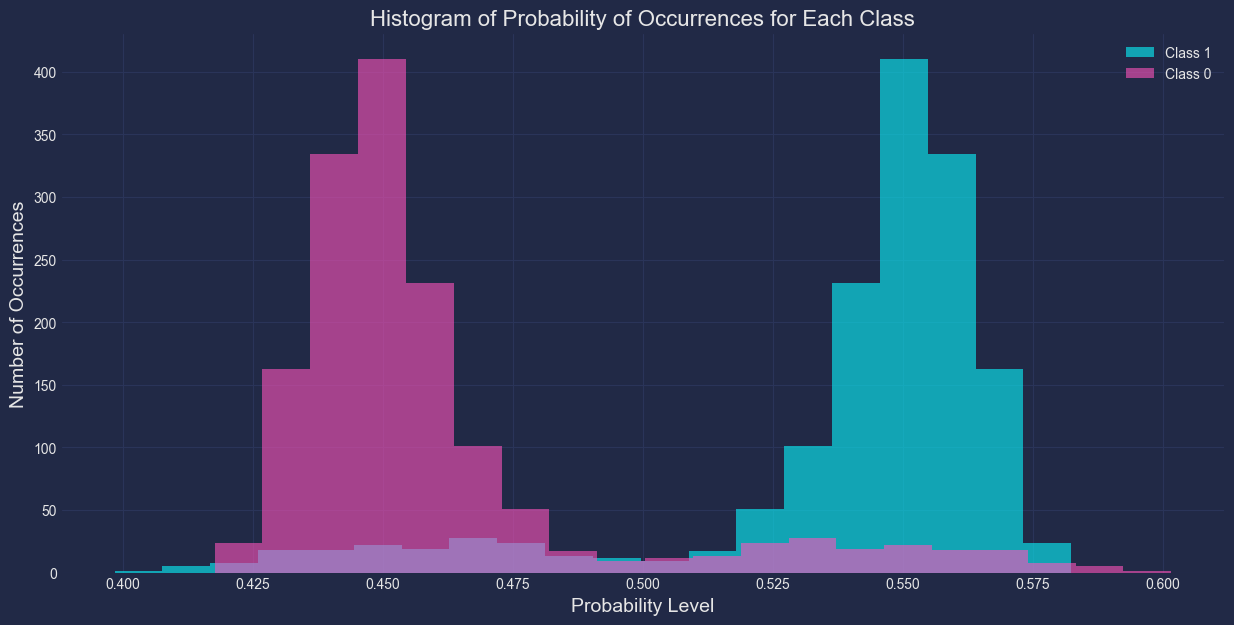

In [87]:
# Plot the probability values for Class 1 in a histogram
plt.figure(figsize=(15, 7))
plt.hist(test_data['probability_1'], bins=20, alpha=0.6, label='Class 1')

# Plot the probability values for Class 0 in a histogram
plt.hist(test_data['probability_0'], bins=20, alpha=0.6, label='Class 0')

# Set title and labels
plt.title('Histogram of Probability of Occurrences for Each Class', fontsize=16)
plt.xlabel('Probability Level', fontsize=14)
plt.ylabel('Number of Occurrences', fontsize=14)
plt.legend()
plt.show()

In [88]:
# Set long condition: predicted probability of 1 should be >= 0.55 and predicted_signal == 1
long_condition = (df['probability_1'] >= 0.51) & (df['predicted_signal'] == 1)

# Set short condition: predicted probability of 1 should be <= 0.45 and predicted_signal == 0
short_condition = (df['probability_1'] <= 0.48) & (df['predicted_signal'] == 0)

# Assign values: 1 for long, -1 for short, 0 otherwise
df['predicted_signal_refined'] = np.where(long_condition, 1, 
                                          np.where(short_condition, -1, 0))

We establish conditions for entering trades based on probability thresholds: going long when the predicted probability of a positive return exceeds a set threshold and going short when it falls below a different threshold. This approach aims to filter out lower-confidence predictions and potentially improve overall strategy performance.

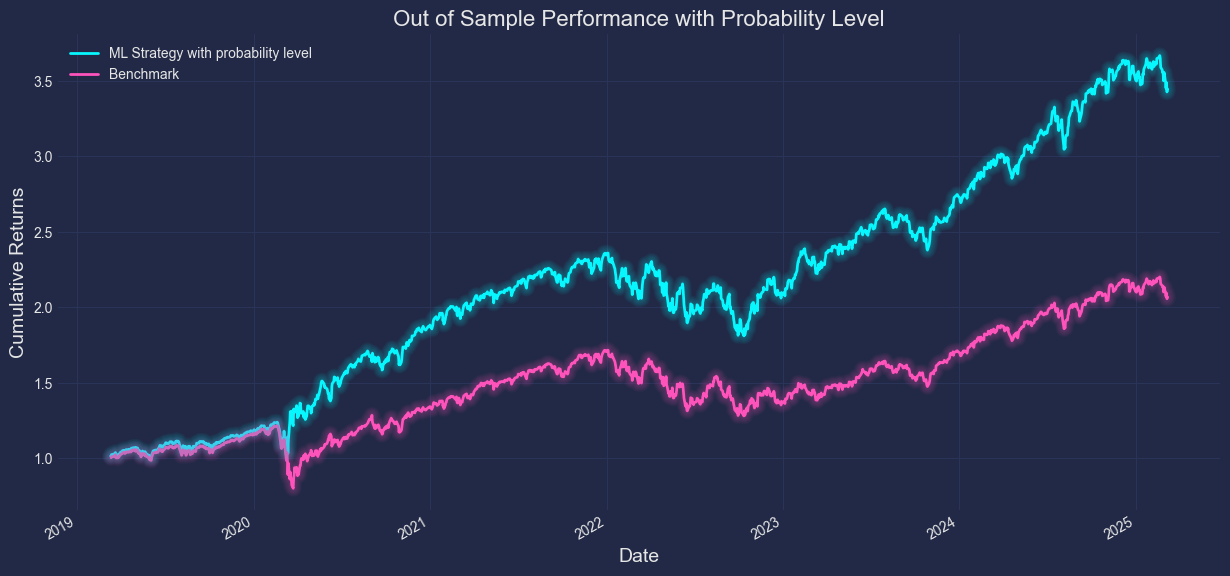

Benchmark SR: 0.71
Strategy SR: 1.16
Cumulative Returns after adding probability level: 3.45


In [89]:
# Calculate modified strategy returns
df['strategy_returns_refined'] = df.Close.pct_change() * \
    df.predicted_signal_refined.shift(1)

# Store the test data in the dataframe
test_data = df.iloc[split:]

# Calculate and plot the cumulative returns of the modified strategy
(test_data['strategy_returns_refined']+1).cumprod().plot(
    label='ML Strategy with probability level', figsize=(15, 7), lw=2)

# Calculate and plot the cumulative returns of the benchmark in the same time period
(test_data.Close.pct_change()+1).cumprod().plot(label='Benchmark', lw=2)
# Set title
plt.title('Out of Sample Performance with Probability Level', fontsize=16)
# Set x and y axis labels
plt.xlabel('Date', fontsize=14)
plt.ylabel('Cumulative Returns', fontsize=14)
plt.legend()
mplcyberpunk.make_lines_glow()
plt.show()

# Create a function to calculate sharpe ratio
def get_sr(ret):
    return round(ret.mean()/ret.std()*252**0.5, 2)


# Print the Sharpe ratio of benchmark and strategy as well as the cumulative returns
print(f"Benchmark SR: {get_sr(test_data.Close.pct_change())}")
print(f"Strategy SR: {get_sr(test_data['strategy_returns_refined'])}")
print(f"Cumulative Returns after adding probability level: "'%.2f' %
      (test_data['strategy_returns_refined']+1).cumprod().iloc[-1])

The backtest results on the out-of-sample data indicate that incorporating probability-based thresholds significantly enhances strategy performance. The Sharpe ratio improves to 1.16, and total returns increase to an impressive 345%, suggesting that filtering trades based on prediction confidence helps optimize trade selection and overall profitability.

## XGBoost

Next, we will take a similar approach but employ an XGBoost Classifier as our model, leveraging its gradient boosting framework to enhance predictive performance.

In [90]:
df = data.copy()
df.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2005-03-15,82.454544,120.139999,121.459999,120.080002,121.419998,62438500
2005-03-16,81.754440,119.120003,120.160004,118.900002,119.699997,74874200
2005-03-17,81.919174,119.360001,119.739998,118.980003,119.309998,62584200
2005-03-18,81.675919,118.540001,119.529999,118.150002,119.110001,60232000
2005-03-21,81.372765,118.099998,118.779999,117.760002,118.709999,61244300


### Feature Engineering

In [91]:
# Define time periods to calculate returns
intervals = [1, 2, 3]

# Loop to calculate log returns for time periods specified in 'intervals'
for t in intervals:
    # Create new columns for features in 'df' and store the value of returns
    df[f'f_ret_{t}'] = df.Close.pct_change(t)

# Display the data
df.dropna(inplace=True)
df.tail()

,Adj Close,Close,High,Low,Open,Volume,f_ret_1,f_ret_2,f_ret_3
Date,,,,,,,,,
2025-03-03,583.770020,583.770020,597.340027,579.900024,596.179993,74249200,-0.017520,-0.002188,-0.018115
2025-03-04,576.859985,576.859985,585.390015,572.250000,579.710022,109648200,-0.011837,-0.029149,-0.013999
2025-03-05,583.059998,583.059998,584.880005,573.080017,576.690002,71230500,0.010748,-0.001216,-0.018715
2025-03-06,572.710022,572.710022,580.169983,570.119995,575.479980,80094900,-0.017751,-0.007194,-0.018946
2025-03-07,575.919983,575.919983,577.390015,565.630005,570.900024,81158800,0.005605,-0.012246,-0.001630


In [92]:
state_means, _ = kf.filter(df['f_ret_1'])
df['f_ret_1_kalman_filtered'] = state_means

In [93]:
# Calculate and store the NATR values
df['f_natr'] = ta.NATR(df.High, df.Low, df.Close)

# Calculate and store the MACD values
_, _, df['f_MACD_hist'] = ta.MACD(df['Close'], fastperiod=12, slowperiod=26, signalperiod=9)

# Compute the Bollinger bands
upper, middle, lower = ta.BBANDS(df.Close)

df['f_norm_middle'] = middle/df.Close

In [94]:
# Download VIX data (1-day frequency)
vix_data = yf.download('^VIX', start=start_date, end=end_date, auto_adjust=False)

[*********************100%***********************]  1 of 1 completed


In [95]:
# Remove the second row (Ticker row)
vix_data.columns = vix_data.columns.droplevel(1)  # Drop the first level (Ticker row)
vix_data.columns.name = None  # Removes the extra label if set

In [96]:
# Define time periods to calculate returns
intervals = [1, 2, 3]

# Loop to calculate log returns for time periods specified in 'intervals'
for t in intervals:
    # Create new columns for features in 'df' and store the value of returns
    vix_data[f'f_vix_ret_{t}'] = vix_data.Close.pct_change(t)

In [97]:
df = df.join(vix_data[['f_vix_ret_1']], how='left')

In [98]:
# Store features data in 'features'
features = df.filter(like='f_')

# Display the last 5 rows
features.tail()

,f_ret_1,f_ret_2,f_ret_3,f_ret_1_kalman_filtered,f_natr,f_MACD_hist,f_norm_middle,f_vix_ret_1
Date,,,,,,,,
2025-03-03,-0.017520,-0.002188,-0.018115,-0.002540,1.387304,-2.676489,1.011282,0.160469
2025-03-04,-0.011837,-0.029149,-0.013999,-0.003424,1.466345,-3.223215,1.017370,0.032046
2025-03-05,0.010748,-0.001216,-0.018715,-0.002076,1.491685,-2.994333,1.002614,-0.067205
2025-03-06,-0.017751,-0.007194,-0.018946,-0.003567,1.571556,-3.340669,1.016424,0.134063
2025-03-07,0.005605,-0.012246,-0.001630,-0.002695,1.597022,-3.156409,1.004417,-0.060314


We will incorporate a larger set of features when using XGBoost compared to the Random Forest model, taking advantage of XGBoost's ability to handle complex feature interactions effectively.

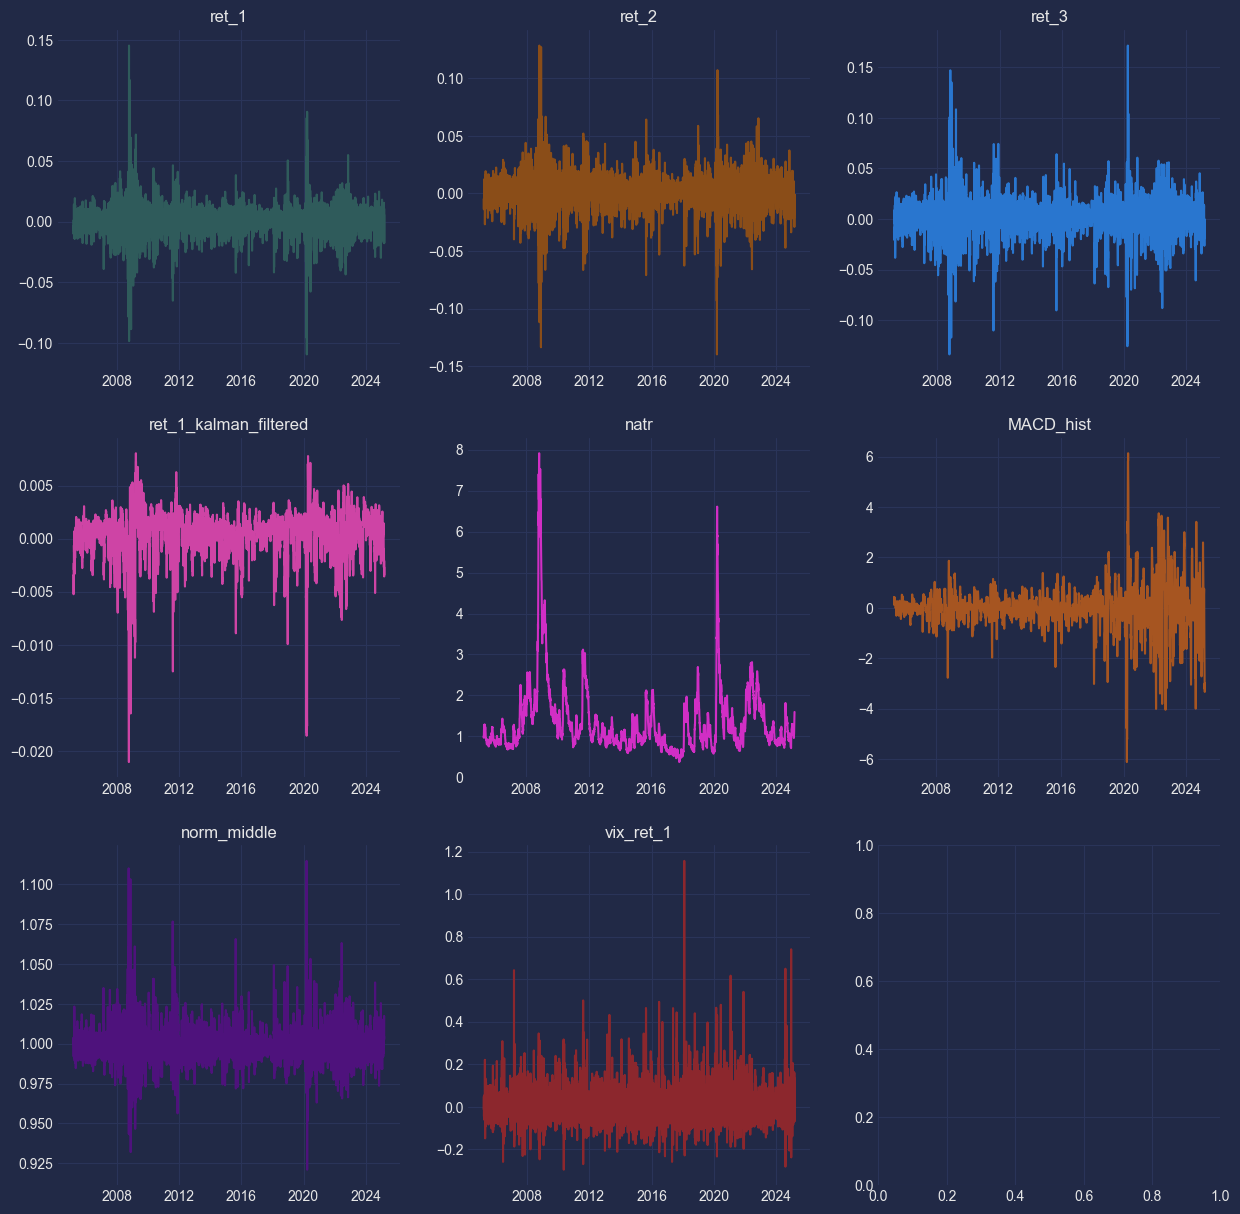

In [99]:
# Get the total count of features
num_of_features = len(features.columns)

# Define the layout and size for subplots
fig, axs = plt.subplots(int(num_of_features/3)+1, 3,
                        figsize=(15, 5*(num_of_features+1)/3))
axs = axs.ravel()
mplcyberpunk.add_glow_effects()

# Loop to plot the individual features
for i in range(num_of_features):
    axs[i].plot(df[features.columns[i]], color=np.random.rand(3,))
    axs[i].set_title(features.columns[i].replace('f_',''))
    mplcyberpunk.add_glow_effects()

plt.show()

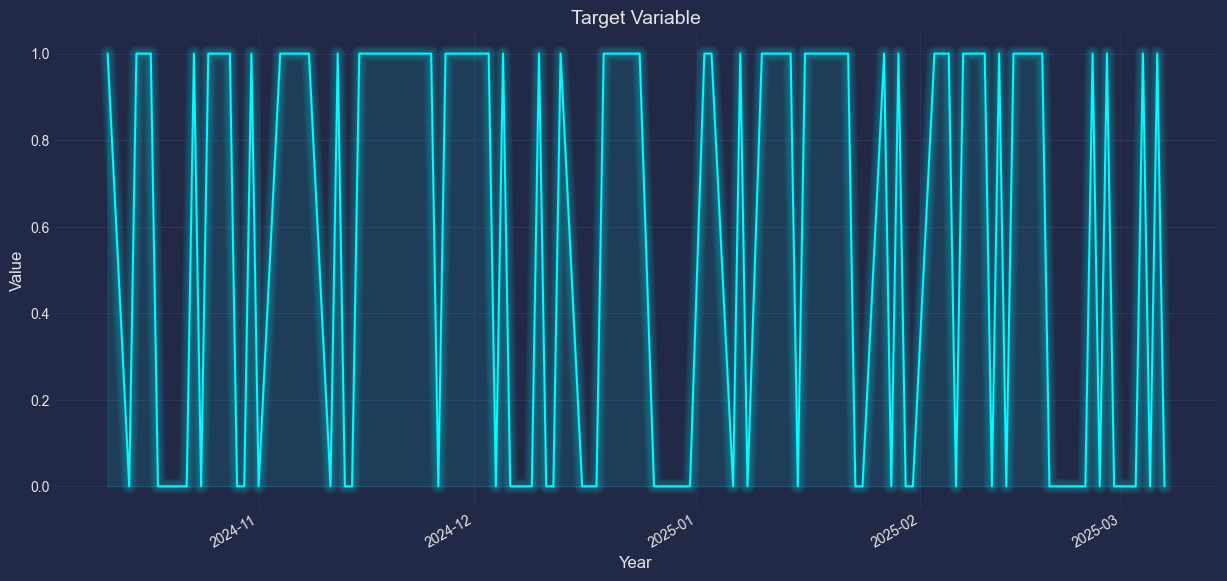

In [100]:
# Create the target variable
df['return'] = df.Close.pct_change(1).shift(-1)
df['target'] = np.where(df['return'] > 0, 1, 0)

# Plot the target
plt.figure(figsize=(15, 7))
df.iloc[-100:].target.plot()

# Set the title and axes labels
plt.title('Target Variable', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Value', fontsize=12)
mplcyberpunk.add_glow_effects()
plt.show()

In [101]:
# Store the features data in variable X
X = df.filter(like='f_')
X.tail()

,f_ret_1,f_ret_2,f_ret_3,f_ret_1_kalman_filtered,f_natr,f_MACD_hist,f_norm_middle,f_vix_ret_1
Date,,,,,,,,
2025-03-03,-0.017520,-0.002188,-0.018115,-0.002540,1.387304,-2.676489,1.011282,0.160469
2025-03-04,-0.011837,-0.029149,-0.013999,-0.003424,1.466345,-3.223215,1.017370,0.032046
2025-03-05,0.010748,-0.001216,-0.018715,-0.002076,1.491685,-2.994333,1.002614,-0.067205
2025-03-06,-0.017751,-0.007194,-0.018946,-0.003567,1.571556,-3.340669,1.016424,0.134063
2025-03-07,0.005605,-0.012246,-0.001630,-0.002695,1.597022,-3.156409,1.004417,-0.060314


In [102]:
# Store the target data in variable y
y = df['target']
y.tail()

Date
2025-03-03    0
2025-03-04    1
2025-03-05    0
2025-03-06    1
2025-03-07    0
Name: target, dtype: int32

In [103]:
# Set the split threshold
split_percentage = 0.7
split = int(split_percentage*len(X))

# Train dataset
X_train = X[:split]
y_train = y[:split]

# Test dataset
X_test = X[split:]
y_test = y[split:]

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(3517, 8) (3517,)
(1508, 8) (1508,)


### XGBoost Model

In [104]:
# Define XGBoost Classifier
xgb_clf = xgb.XGBClassifier(random_state=42)

xgb_clf.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

First, we will initialize and train an untuned XGBoost classifier to establish a baseline performance.

In [105]:
y_pred_test = xgb_clf.predict(X_test)
y_pred_train = xgb_clf.predict(X_train)

In [106]:
# Evaluate the model on the train dataset
accuracy_train = accuracy_score(y_train, y_pred_train)
precision_train = precision_score(y_train, y_pred_train, average='binary')
recall_train = recall_score(y_train, y_pred_train, average='binary')
f1_train = f1_score(y_train, y_pred_train, average='binary')

print('\nTrain Accuracy: {:.2f}%'.format(accuracy_train * 100))
print('Train Precision: {:.2f}%'.format(precision_train * 100))
print('Train Recall: {:.2f}%'.format(recall_train * 100))
print('Train F1 Score: {:.2f}%'.format(f1_train * 100))

# Evaluate the model on the test dataset
accuracy_test = accuracy_score(y_test, y_pred_test)
precision_test = precision_score(y_test, y_pred_test, average='binary')
recall_test = recall_score(y_test, y_pred_test, average='binary')
f1_test = f1_score(y_test, y_pred_test, average='binary')

print('\nTest Accuracy: {:.2f}%'.format(accuracy_test * 100))
print('Test Precision: {:.2f}%'.format(precision_test * 100))
print('Test Recall: {:.2f}%'.format(recall_test * 100))
print('Test F1 Score: {:.2f}%'.format(f1_test * 100))


Train Accuracy: 98.49%
Train Precision: 97.84%
Train Recall: 99.42%
Train F1 Score: 98.63%

Test Accuracy: 51.72%
Test Precision: 55.62%
Test Recall: 61.37%
Test F1 Score: 58.35%


We observe that the untuned XGBoost classifier heavily overfits the training dataset, achieving near-perfect accuracy while performing significantly worse on the test data.

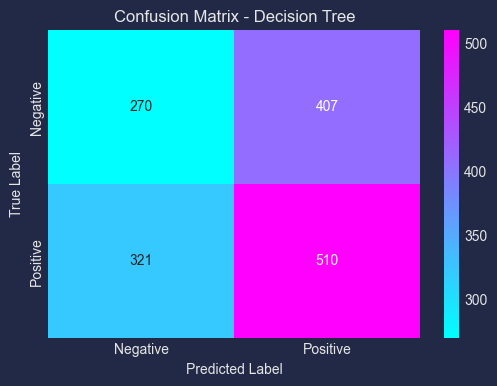

In [107]:
# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

# Define class labels
labels = ["Negative", "Positive"]

# Plot the confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="cool", xticklabels=labels, yticklabels=labels)

# Labels, title, and axis names
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Decision Tree")

plt.show()

### Hyperparameter Tuning

In [108]:
# 🔹 Hyperparameter Grid
param_dist = {
    'n_estimators': randint(10, 100),
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': randint(1, 15),
    'min_child_weight': randint(1, 10),
    'subsample': uniform(0.5, 0.5),
    'colsample_bytree': uniform(0.5, 0.5)
}

We will tune the hyperparameters using a randomized search, ensuring that the model remains relatively shallow to mitigate overfitting while optimizing performance.

In [109]:
random_search = RandomizedSearchCV(
    xgb_clf, param_distributions=param_dist, 
    n_iter=100, cv=5, scoring='accuracy', 
    n_jobs=-1, random_state=42
)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           gamma=None, grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning_rate...
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000016BF6E42C60>,
                                        'min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000016BF3A64530>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000016BF6A9E480>,
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000016BF3AC2CC0>},
                   random_state=42, scoring='accuracy')

In [110]:
# Best hyperparameters
best_params_ = random_search.best_params_
print("Best Hyperparameters:", best_params_)

Best Hyperparameters: {'colsample_bytree': 0.9250192888948996, 'learning_rate': 0.14483520224146101, 'max_depth': 1, 'min_child_weight': 7, 'n_estimators': 32, 'subsample': 0.8344206263318037}


In [111]:
best_xgb = random_search.best_estimator_
y_pred_test = best_xgb.predict(X_test)
y_pred_train = best_xgb.predict(X_train)

In [112]:
# Evaluate the model on the train dataset
accuracy_train = accuracy_score(y_train, y_pred_train)
precision_train = precision_score(y_train, y_pred_train, average='binary')
recall_train = recall_score(y_train, y_pred_train, average='binary')
f1_train = f1_score(y_train, y_pred_train, average='binary')

print('\nTrain Accuracy: {:.2f}%'.format(accuracy_train * 100))
print('Train Precision: {:.2f}%'.format(precision_train * 100))
print('Train Recall: {:.2f}%'.format(recall_train * 100))
print('Train F1 Score: {:.2f}%'.format(f1_train * 100))

# Evaluate the model on the test dataset
accuracy_test = accuracy_score(y_test, y_pred_test)
precision_test = precision_score(y_test, y_pred_test, average='binary')
recall_test = recall_score(y_test, y_pred_test, average='binary')
f1_test = f1_score(y_test, y_pred_test, average='binary')

print('\nTest Accuracy: {:.2f}%'.format(accuracy_test * 100))
print('Test Precision: {:.2f}%'.format(precision_test * 100))
print('Test Recall: {:.2f}%'.format(recall_test * 100))
print('Test F1 Score: {:.2f}%'.format(f1_test * 100))


Train Accuracy: 55.13%
Train Precision: 55.02%
Train Recall: 95.82%
Train F1 Score: 69.90%

Test Accuracy: 55.97%
Test Precision: 56.19%
Test Recall: 91.22%
Test F1 Score: 69.54%


The tuned XGBoost model achieves results similar to the random forest model, with train and test accuracy around 55%. However, the high recall suggests that the model leans toward predicting positive returns.

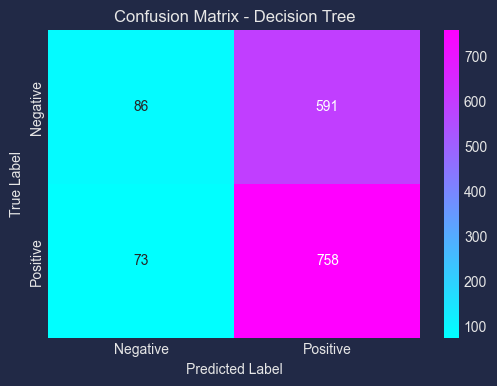

In [113]:
# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

# Define class labels
labels = ["Negative", "Positive"]

# Plot the confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="cool", xticklabels=labels, yticklabels=labels)

# Labels, title, and axis names
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Decision Tree")

plt.show()

### Interpretation

In [114]:
# xgb importance
global_exp = pd.Series(best_xgb.feature_importances_, index=best_xgb.feature_names_in_)

global_exp

f_ret_1                    0.136336
f_ret_2                    0.119061
f_ret_3                    0.133033
f_ret_1_kalman_filtered    0.146286
f_natr                     0.118621
f_MACD_hist                0.110021
f_norm_middle              0.098936
f_vix_ret_1                0.137706
dtype: float32

Using XGBoost's feature importance, we observe that, similar to the random forest model, the Kalman-filtered returns are the most important feature. Following that, the VIX returns and SPY returns also play significant roles in the model's decision-making process.

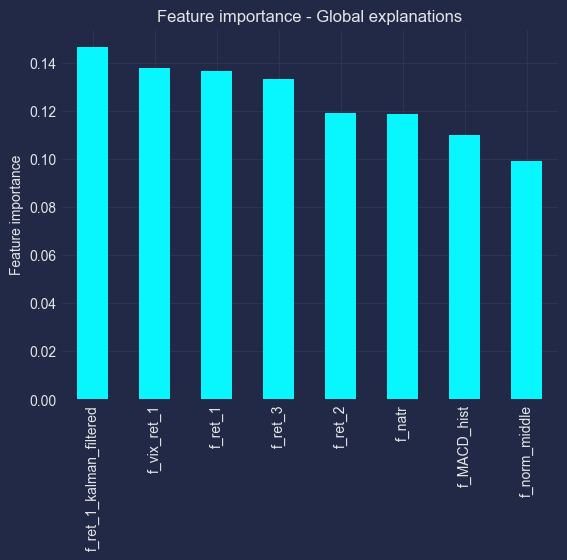

In [115]:
global_exp.sort_values(ascending=False).plot.bar()
plt.ylabel("Feature importance")
plt.title("Feature importance - Global explanations")
plt.show()

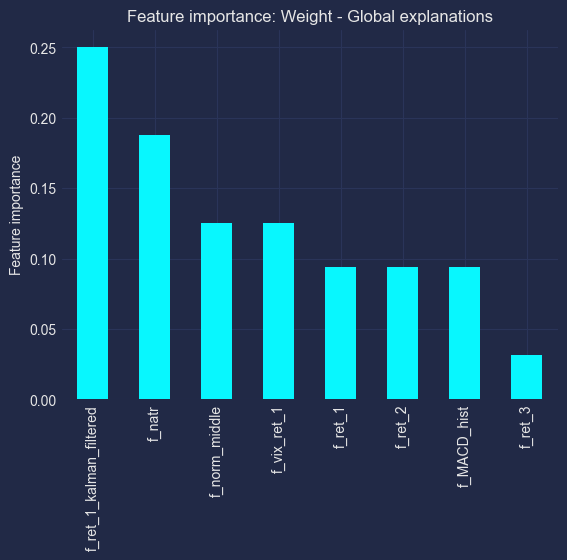

In [116]:
xgb_weight = xgb.XGBClassifier(
    importance_type="weight",
    **best_params_)

xgb_weight.fit(X_train, y_train)

global_exp = pd.Series(xgb_weight.feature_importances_, index=xgb_weight.feature_names_in_)
global_exp.sort_values(ascending=False).plot.bar()
plt.ylabel("Feature importance")
plt.title("Feature importance: Weight - Global explanations")
plt.show()

When setting the importance type to "weight," we find that the Kalman-filtered returns remain the most important feature. However, the NATR (Normalized Average True Range) now takes the second spot in terms of importance, followed by the Bollinger Bands' middle band. This suggests that volatility-based features, such as NATR, are gaining more weight in predicting future returns when using XGBoost.

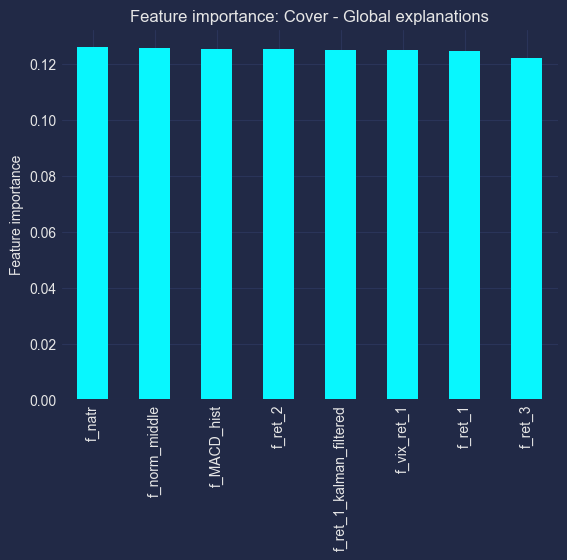

In [117]:
xgb_cover = xgb.XGBClassifier(
    importance_type="cover",
    **best_params_)

xgb_cover.fit(X_train, y_train)

global_exp = pd.Series(xgb_cover.feature_importances_, index=xgb_cover.feature_names_in_)
global_exp.sort_values(ascending=False).plot.bar()
plt.ylabel("Feature importance")
plt.title("Feature importance: Cover - Global explanations")
plt.show()

When the feature importance is set to "cover" in XGBoost, it measures how much a feature contributes to reducing residuals across all trees, reflecting how often it improves the model's performance. With all features having relatively the same importance, it suggests that no single feature is dominant, implying that the model is relying on a combination of features rather than any one of them. This could indicate weak feature relationships, overfitting, or underfitting, where the model is either overly complex and unable to generalize or too simple to capture meaningful patterns in the data.  In either case, this may warrant further investigation into feature engineering, feature selection, or adjustments to the model to help uncover better predictive patterns in the data.

### Backtesting

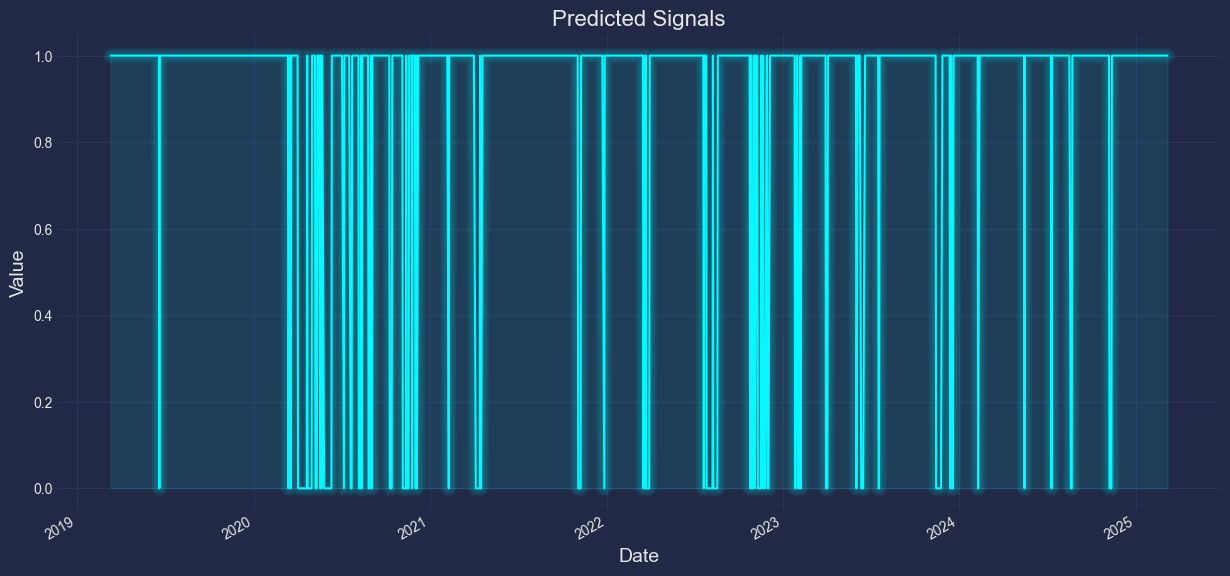

In [118]:
# Compute and store the predicted signal
df['predicted_signal'] = best_xgb.predict(X)

# Plot the predicted signal
plt.figure(figsize=(15, 7))
df.iloc[split:].predicted_signal.plot()

# Set the title and axes labels
plt.title('Predicted Signals', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Value', fontsize=14)
mplcyberpunk.add_glow_effects()
plt.show()

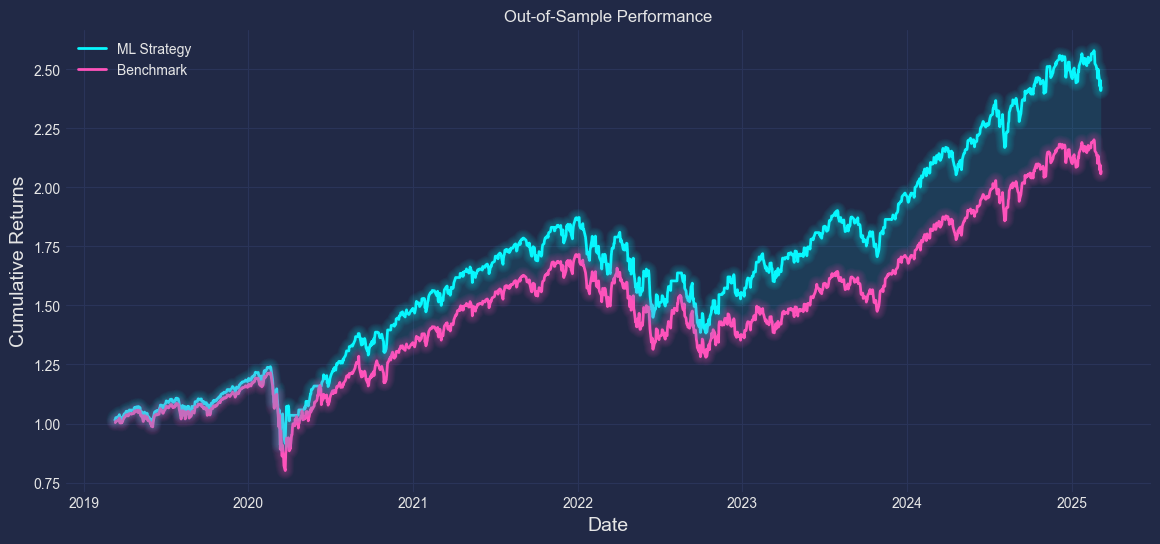

Benchmark returns: 2.07
Strategy returns: 2.42
Benchmark Sharpe: 0.71
ML Strategy Sharpe: 0.9


In [119]:
# Calculate strategy returns for out-of-sample period
df['strategy_returns'] = df.Close.pct_change() * df.predicted_signal.shift(1)
test_data = df.iloc[split:]

# Plot the returns
plt.figure(figsize=(14, 6))

# Calculate cumulative returns
benchmark_returns = (test_data.Close.pct_change()+1).cumprod()
strategy_returns = (test_data['strategy_returns']+1).cumprod()

# Plot both lines
plt.plot(strategy_returns, label='ML Strategy', lw=2)
plt.plot(benchmark_returns, label='Benchmark', lw=2)

# Titles and labels
plt.title('Out-of-Sample Performance')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Cumulative Returns', fontsize=14)
# Add glow effect between the two lines
# Apply cyberpunk effects
# mplcyberpunk.add_glow_effects()
plt.fill_between(test_data.index, benchmark_returns, strategy_returns, where=(strategy_returns > benchmark_returns), alpha=0.1)
plt.fill_between(test_data.index, benchmark_returns, strategy_returns, where=(strategy_returns < benchmark_returns), alpha=0.1)

plt.legend()
mplcyberpunk.make_lines_glow()
plt.show()

# Print total returns
print(f"Benchmark returns: {round(benchmark_returns.iloc[-1],2)}")
print(f"Strategy returns: {round(strategy_returns.iloc[-1],2)}")

# Function to compute Sharpe ratio
def get_sr(ret):
    return round(ret.mean()/ret.std()*252**0.5, 2)

# Print the Sharpe ratios for the strategies
print(f"Benchmark Sharpe: {get_sr(test_data.Close.pct_change())}")
print(f"ML Strategy Sharpe: {get_sr(test_data['strategy_returns'])}")

The strategy using the XGBoost model doesn't quite match the performance of the random forest model, but it still outperforms the buy-and-hold benchmark. With a Sharpe ratio of 0.9 and a return of 242% during the testing period, it demonstrates solid profitability and risk-adjusted returns, even though there is room for improvement compared to the random forest model.

In [120]:
# Store probability of occurrence values in new dataframe
probability = (best_xgb.predict_proba(X))

# Store the probability of occurrence values for each output separately
df['probability_0'], df['probability_1'] = probability[:,0], probability[:,1]

# Print the dataframe with probability of occurrence values
df.filter(like='prob').tail().round(3)

,probability_0,probability_1
Date,,
2025-03-03,0.408,0.592
2025-03-04,0.450,0.550
2025-03-05,0.435,0.565
2025-03-06,0.416,0.584
2025-03-07,0.443,0.557


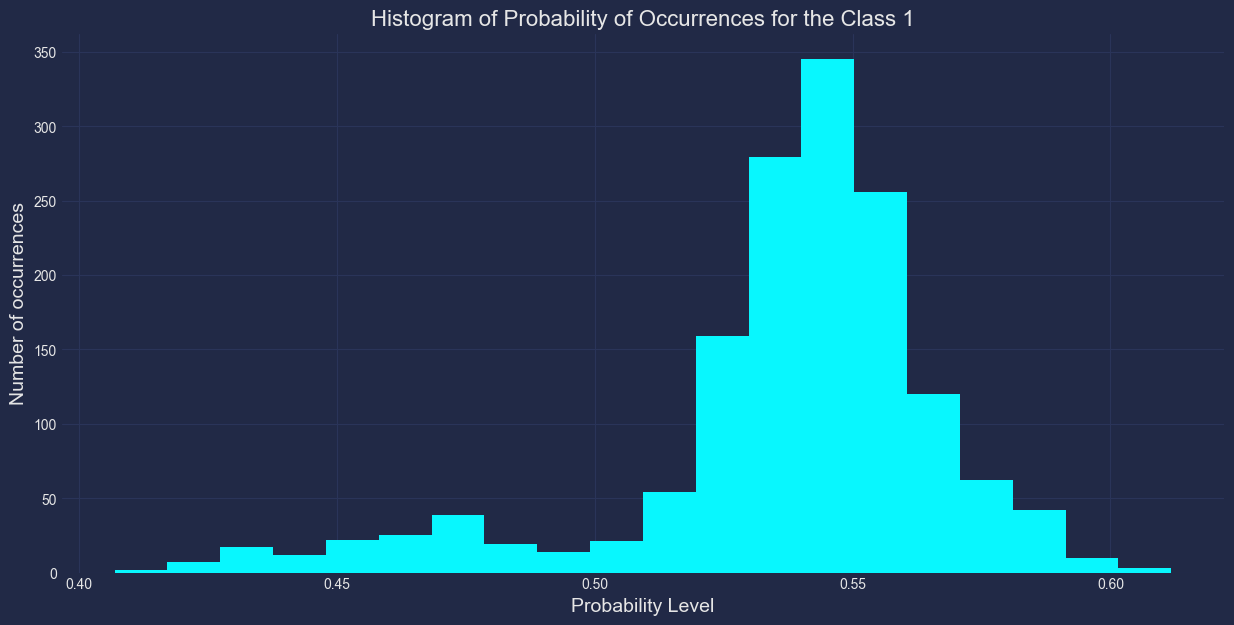

In [121]:
# Declare train and test percentage and split the dataset
split_percentage = 0.7
split = int(split_percentage*len(X))

# Create a new dataframe to store the test data
test_data = df.iloc[split:]

# Plot the probability values in a histogram
test_data.probability_1.hist(bins=20, figsize = (15,7))
# Set title
plt.title('Histogram of Probability of Occurrences for the Class 1', fontsize=16)
# Set x and y axis labels
plt.xlabel('Probability Level', fontsize=14)
plt.ylabel('Number of occurrences', fontsize=14)
plt.show()

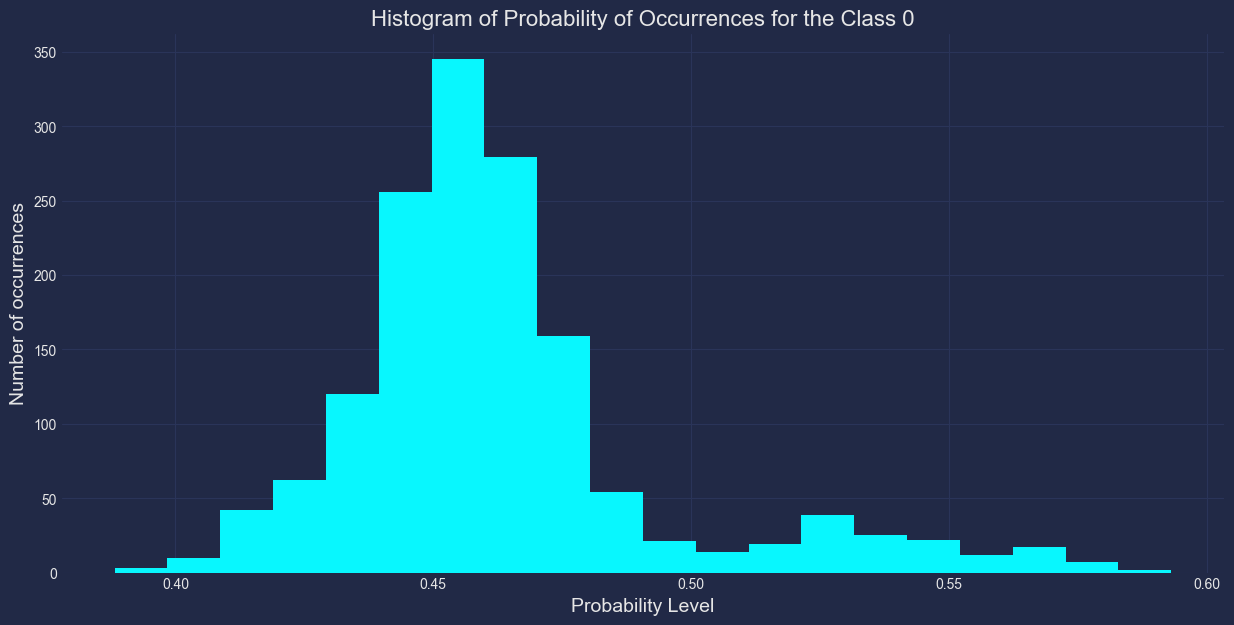

In [122]:
# Declare train and test percentage and split the dataset
split_percentage = 0.7
split = int(split_percentage*len(X))

# Create a new dataframe to store the test data
test_data = df.iloc[split:]

# Plot the probability values in a histogram
test_data.probability_0.hist(bins=20, figsize = (15,7))
# Set title
plt.title('Histogram of Probability of Occurrences for the Class 0', fontsize=16)
# Set x and y axis labels
plt.xlabel('Probability Level', fontsize=14)
plt.ylabel('Number of occurrences', fontsize=14)
plt.show()

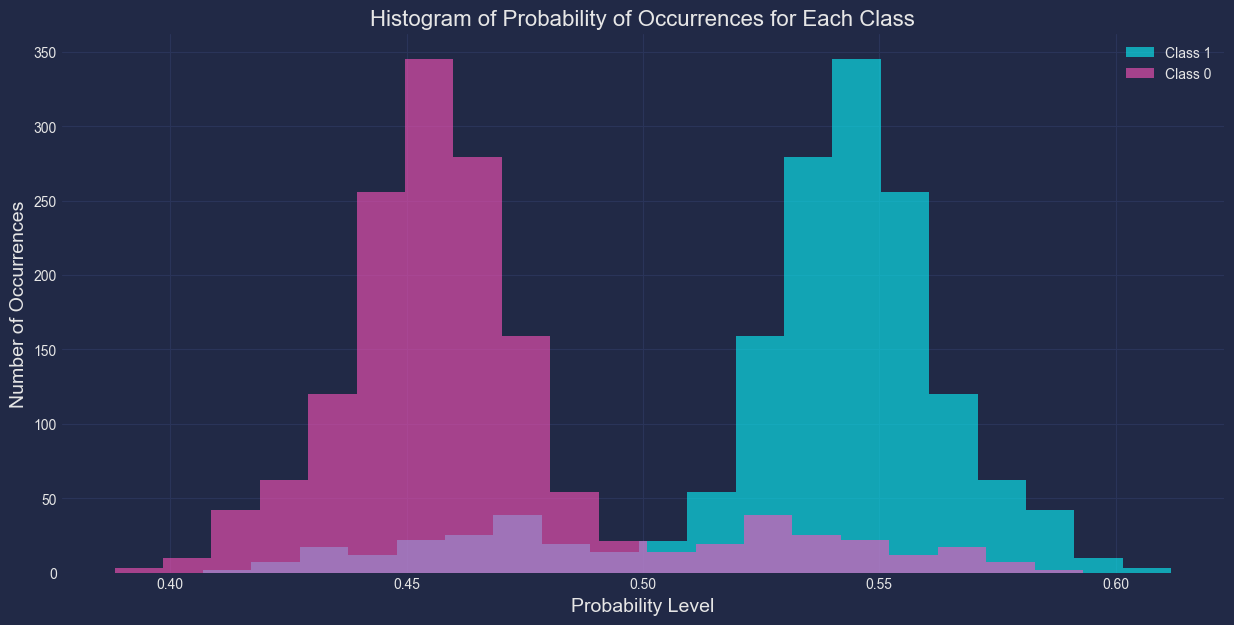

In [123]:
# Plot the probability values for Class 1 in a histogram
plt.figure(figsize=(15, 7))
plt.hist(test_data['probability_1'], bins=20, alpha=0.6, label='Class 1')

# Plot the probability values for Class 0 in a histogram
plt.hist(test_data['probability_0'], bins=20, alpha=0.6, label='Class 0')

# Set title and labels
plt.title('Histogram of Probability of Occurrences for Each Class', fontsize=16)
plt.xlabel('Probability Level', fontsize=14)
plt.ylabel('Number of Occurrences', fontsize=14)
plt.legend()
plt.show()


In [124]:
# Set long condition
long_condition = (df['probability_1'] >= 0.515) & (df['predicted_signal'] == 1)

# Set short condition
short_condition = (df['probability_1'] <= 0.49) & (df['predicted_signal'] == 0)

# Assign values: 1 for long, -1 for short, 0 otherwise
df['predicted_signal_refined'] = np.where(long_condition, 1, 
                                          np.where(short_condition, -1, 0))

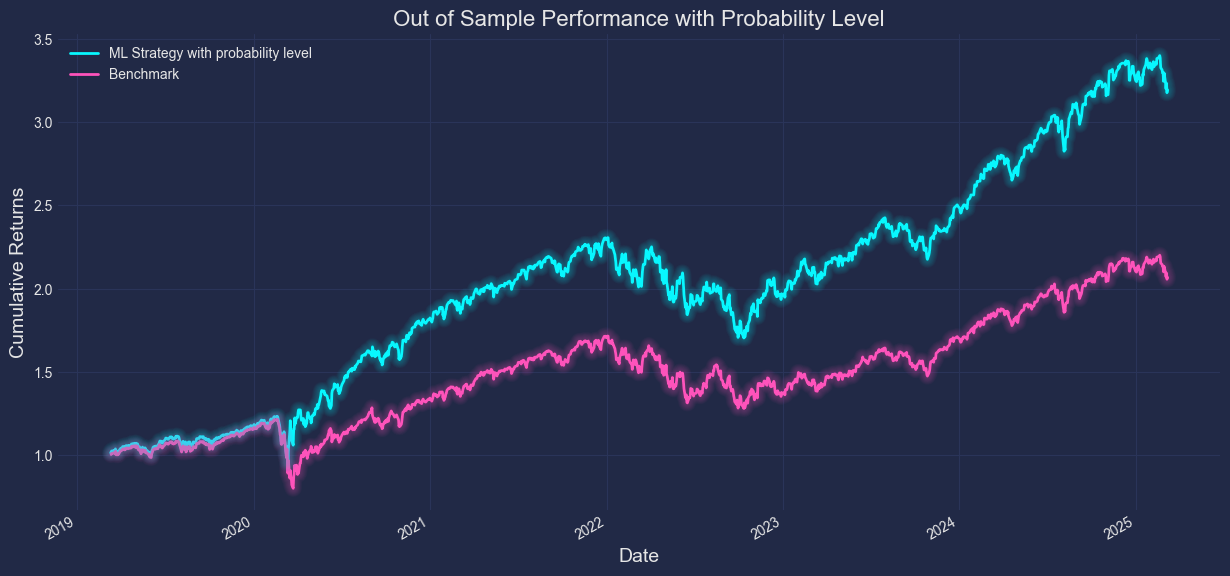

Benchmark SR: 0.71
Strategy SR: 1.1
Cumulative Returns after adding probability level: 3.20


In [125]:
# Calculate modified strategy returns
df['strategy_returns_refined'] = df.Close.pct_change() * \
    df.predicted_signal_refined.shift(1)

# Store the test data in the dataframe
test_data = df.iloc[split:]

# Calculate and plot the cumulative returns of the modified strategy
(test_data['strategy_returns_refined']+1).cumprod().plot(
    label='ML Strategy with probability level', figsize=(15, 7), lw=2)

# Calculate and plot the cumulative returns of the benchmark in the same time period
(test_data.Close.pct_change()+1).cumprod().plot(label='Benchmark', lw=2)
# Set title
plt.title('Out of Sample Performance with Probability Level', fontsize=16)
# Set x and y axis labels
plt.xlabel('Date', fontsize=14)
plt.ylabel('Cumulative Returns', fontsize=14)
plt.legend()
mplcyberpunk.make_lines_glow()
plt.show()



# Create a function to calculate sharpe ratio
def get_sr(ret):
    return round(ret.mean()/ret.std()*252**0.5, 2)


# Print the Sharpe ratio of benchmark and strategy as well as the cumulative returns
print(f"Benchmark SR: {get_sr(test_data.Close.pct_change())}")
print(f"Strategy SR: {get_sr(test_data['strategy_returns_refined'])}")
print(f"Cumulative Returns after adding probability level: "'%.2f' %
      (test_data['strategy_returns_refined']+1).cumprod().iloc[-1])

We again adjust the probabilities and see the sharpe ratio increases to 1.1 with a 320% increase.

## Blended Model

We will combine multiple machine learning models, using their predictions as inputs to train a meta-model (referred to as the "blender" in this notebook). This blender model will then be used to predict whether the S&P 500 index will rise or fall the next day.

In [126]:
df = data.copy()
df.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2005-03-15,82.454544,120.139999,121.459999,120.080002,121.419998,62438500
2005-03-16,81.754440,119.120003,120.160004,118.900002,119.699997,74874200
2005-03-17,81.919174,119.360001,119.739998,118.980003,119.309998,62584200
2005-03-18,81.675919,118.540001,119.529999,118.150002,119.110001,60232000
2005-03-21,81.372765,118.099998,118.779999,117.760002,118.709999,61244300


### Feature Engineering

Nothing too different here from what we have been doing for the previous models.

In [127]:
# Define time periods to calculate returns
intervals = [1]

# Loop to calculate log returns for time periods specified in 'intervals'
for t in intervals:
    # Create new columns for features in 'df' and store the value of returns
    df[f'f_ret_{t}'] = df.Close.pct_change(t)

# Display the data
df.dropna(inplace=True)
df.tail()

,Adj Close,Close,High,Low,Open,Volume,f_ret_1
Date,,,,,,,
2025-03-03,583.770020,583.770020,597.340027,579.900024,596.179993,74249200,-0.017520
2025-03-04,576.859985,576.859985,585.390015,572.250000,579.710022,109648200,-0.011837
2025-03-05,583.059998,583.059998,584.880005,573.080017,576.690002,71230500,0.010748
2025-03-06,572.710022,572.710022,580.169983,570.119995,575.479980,80094900,-0.017751
2025-03-07,575.919983,575.919983,577.390015,565.630005,570.900024,81158800,0.005605


In [128]:
state_means, _ = kf.filter(df['f_ret_1'])
df['f_ret_1_kalman_filtered'] = state_means

In [129]:
# Calculate and store the NATR values
df['f_natr'] = ta.NATR(df.High, df.Low, df.Close)

# Calculate and store the MACD values
_, _, df['f_MACD_hist'] = ta.MACD(df['Close'], fastperiod=12, slowperiod=26, signalperiod=9)

In [130]:
df.dropna(inplace=True)
df.head()

,Adj Close,Close,High,Low,Open,Volume,f_ret_1,f_ret_1_kalman_filtered,f_natr,f_MACD_hist
Date,,,,,,,,,,
2005-05-03,80.339249,116.599998,116.849998,115.690002,116.070000,86000300,0.001718,0.000335,1.225297,0.129802
2005-05-04,80.959351,117.500000,117.750000,116.279999,116.650002,81055700,0.007719,0.001038,1.218423,0.229562
2005-05-05,80.931808,117.459999,118.000000,116.739998,117.669998,96906700,-0.000340,0.000907,1.208400,0.283090
2005-05-06,80.676865,117.089996,117.989998,117.059998,117.930000,67415400,-0.003150,0.000521,1.182364,0.283131
2005-05-09,81.179794,117.820000,118.080002,117.050003,117.209999,43750500,0.006235,0.001065,1.153551,0.319199


In [131]:
# Download VIX data (1-day frequency)
vix_data = yf.download('^VIX', start=start_date, end=end_date, auto_adjust=False)

[*********************100%***********************]  1 of 1 completed


In [132]:
# Remove the second row (Ticker row)
vix_data.columns = vix_data.columns.droplevel(1)  # Drop the first level (Ticker row)
vix_data.columns.name = None  # Removes the extra label if set
# # Reset the index name
vix_data.index.name = "Date"

In [133]:
# Define time periods to calculate returns
intervals = [1, 2, 3]

# Loop to calculate log returns for time periods specified in 'intervals'
for t in intervals:
    # Create new columns for features in 'df' and store the value of returns
    vix_data[f'f_vix_ret_{t}'] = vix_data.Close.pct_change(t)

In [134]:
df = df.join(vix_data[['f_vix_ret_1', 'f_vix_ret_2', 'f_vix_ret_3']], how='left')

In [135]:
df.dropna(inplace=True)

In [136]:
# Store features data in 'features'
features = df.filter(like='f_')

# Display the last 5 rows
features.tail()

,f_ret_1,f_ret_1_kalman_filtered,f_natr,f_MACD_hist,f_vix_ret_1,f_vix_ret_2,f_vix_ret_3
Date,,,,,,,
2025-03-03,-0.017520,-0.002540,1.387304,-2.676489,0.160469,0.078088,0.192670
2025-03-04,-0.011837,-0.003424,1.466345,-3.223215,0.032046,0.197657,0.112636
2025-03-05,0.010748,-0.002076,1.491685,-2.994333,-0.067205,-0.037313,0.117168
2025-03-06,-0.017751,-0.003567,1.571556,-3.340669,0.134063,0.057848,0.091747
2025-03-07,0.005605,-0.002695,1.597022,-3.156409,-0.060314,0.065663,-0.005955


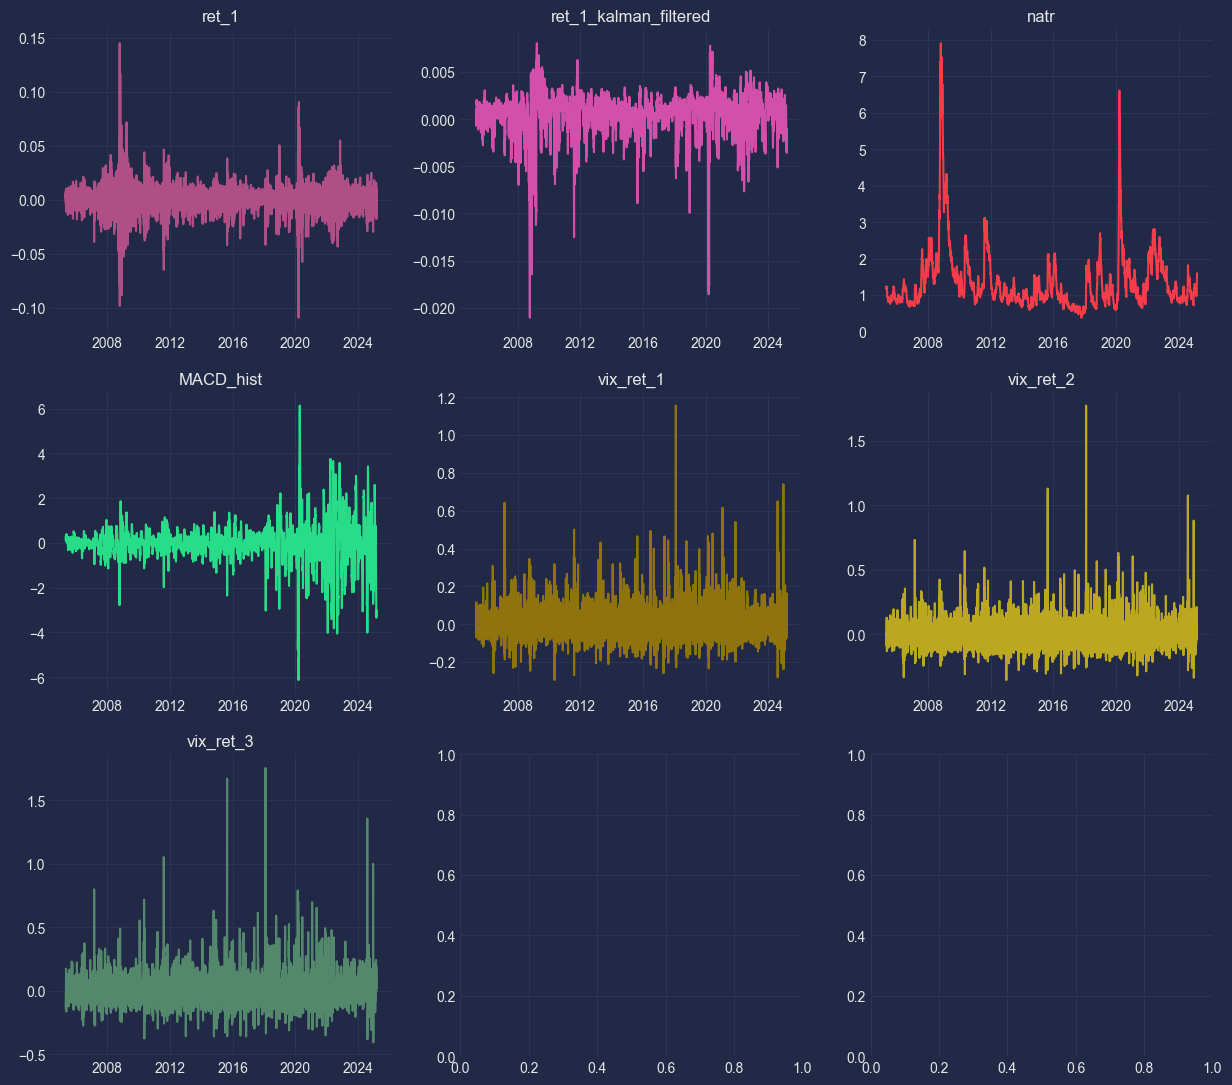

In [137]:
# Get the total count of features
num_of_features = len(features.columns)

# Define the layout and size for subplots
fig, axs = plt.subplots(int(num_of_features/3)+1, 3,
                        figsize=(15, 5*(num_of_features+1)/3))
axs = axs.ravel()
mplcyberpunk.add_glow_effects()

# Loop to plot the individual features
for i in range(num_of_features):
    axs[i].plot(df[features.columns[i]], color=np.random.rand(3,))
    axs[i].set_title(features.columns[i].replace('f_',''))
    mplcyberpunk.add_glow_effects()

plt.show()

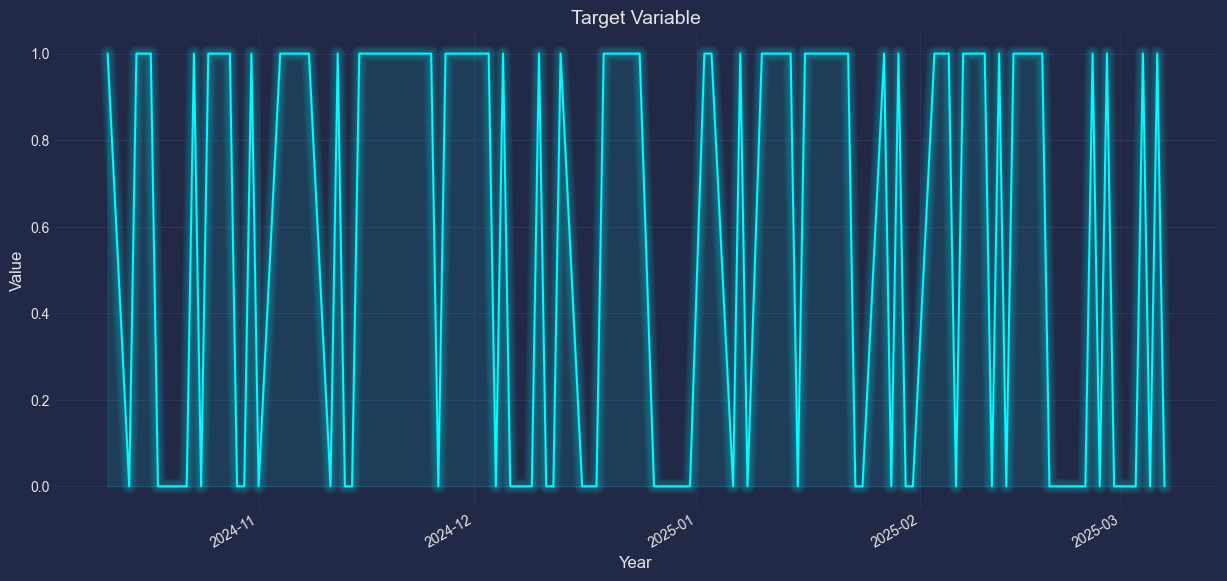

In [138]:
# Create the target variable
df['return'] = df.Close.pct_change(1).shift(-1)
df['target'] = np.where(df['return'] > 0, 1, 0)

# Plot the target
plt.figure(figsize=(15, 7))
df.iloc[-100:].target.plot()

# Set the title and axes labels
plt.title('Target Variable', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Value', fontsize=12)
mplcyberpunk.add_glow_effects()
plt.show()

In [139]:
# Store the features data in variable X
X = df.filter(like='f_')
X.head()

,f_ret_1,f_ret_1_kalman_filtered,f_natr,f_MACD_hist,f_vix_ret_1,f_vix_ret_2,f_vix_ret_3
Date,,,,,,,
2005-05-03,0.001718,0.000335,1.225297,0.129802,-0.039021,-0.050947,-0.138197
2005-05-04,0.007719,0.001038,1.218423,0.229562,-0.046800,-0.083995,-0.095363
2005-05-05,-0.000340,0.000907,1.208400,0.283090,0.009386,-0.037853,-0.075397
2005-05-06,-0.003150,0.000521,1.182364,0.283131,0.005007,0.014440,-0.033035
2005-05-09,0.006235,0.001065,1.153551,0.319199,-0.021352,-0.016452,-0.007220


In [140]:
# Store the target data in variable y
y = df['target']
y.tail()

Date
2025-03-03    0
2025-03-04    1
2025-03-05    0
2025-03-06    1
2025-03-07    0
Name: target, dtype: int32

<a id='split'></a>
### Split Data into Train and Test for Base and Meta Model

An important part of blending is the division of the input dataset for training and testing both the base learners and blender model. Let us see how it is done in a stepwise manner.

Step 1: You will split the data into train and test datasets for the base as well as the blender model. You will first split the data in the ratio 70:30, where 70% of the feature data is used for training and named as `X_train`. The remaining 30% is used for testing and named as `X_test`.

<img src="https://d2a032ejo53cab.cloudfront.net/Course/Units/Mcq/UnitContent/eteLRWdD/dataset1.JPG">

Step 2: The train data, i.e., `X_train`, is further split in the ratio 70:30. The first 70% is used for training the base models, and is named `X_train_base`. The remaining 30% will be used by the base model for prediction and named as `X_test_base`.

<img src="https://d2a032ejo53cab.cloudfront.net/Course/Units/Mcq/UnitContent/J7Pavlcm/dataset2.JPG">

The above information is summarised below:
1. X_train_base, y_train_base: Train dataset for base model
2. X_test_base, y_test_base: Test dataset for base model

In [141]:
# Split the data into train and test data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, shuffle=False)

# Split the train data further for base and meta learner
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_train, y_train, test_size=0.3, shuffle=False)

In [142]:
# Print shapes of the datasets
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print(f"X_train_base shape: {X_train_base.shape}")
print(f"X_test_base shape: {X_test_base.shape}")
print(f"y_train_base shape: {y_train_base.shape}")
print(f"y_test_base shape: {y_test_base.shape}")

X_train shape: (3495, 7)
X_test shape: (1499, 7)
y_train shape: (3495,)
y_test shape: (1499,)
X_train_base shape: (2446, 7)
X_test_base shape: (1049, 7)
y_train_base shape: (2446,)
y_test_base shape: (1049,)


### Blend of Models

We will use a blend of models, including `XGBClassifier`, `LogisticRegression`, `SVM`, `DecisionTreeClassifier`, `ExtraTreesClassifier`, `AdaBoostClassifie`r, and `RandomForestClassifier`. Their predictions will serve as inputs for the meta-model, which will make the final predictions.

In [143]:
def get_base_estimators(X_train, y_train):
    """
    Create and tune base models using RandomizedSearchCV.
    Returns a list of optimized estimators and prints the best parameters for each.
    """
    base_estimators = {}

    # --------------- Classifier 1: XGBoost ------------------------------------------
    xgb_clf = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
    xgb_param_grid = {
        'n_estimators': randint(10, 100),
        'max_depth': randint(3, 10),
        'learning_rate': uniform(0.01, 0.3),
        'subsample': uniform(0.5, 0.5),
        'colsample_bytree': uniform(0.5, 0.5)
    }
    xgb_search = RandomizedSearchCV(xgb_clf, param_distributions=xgb_param_grid, 
                                    n_iter=500, cv=3, scoring='accuracy', n_jobs=-1, random_state=42)
    xgb_search.fit(X_train, y_train)
    print("Best params for XGBoost:", xgb_search.best_params_)

    # --------------- Classifier 2: Logistic Regression ------------------------------------------
    lr = LogisticRegression(random_state=42)
    lr_param_grid = {'C': loguniform(0.001, 10)}
    lr_search = RandomizedSearchCV(lr, param_distributions=lr_param_grid, 
                                   n_iter=100, cv=3, scoring='accuracy', n_jobs=-1, random_state=42)
    lr_search.fit(X_train, y_train)
    print("Best params for Logistic Regression:", lr_search.best_params_)

    # --------------- Classifier 3: SVM ------------------------------------------
    svc = svm.SVC(class_weight='balanced', probability=True, random_state=42)
    svc_param_grid = {'C': uniform(0.1, 10), 
                      'gamma': loguniform(1e-4, 1),
                      'kernel': ['linear', 'poly', 'rbf', 'sigmoid'], 
                      'degree': randint(2, 5)}
    svc_search = RandomizedSearchCV(svc, param_distributions=svc_param_grid, 
                                    n_iter=100, cv=3, scoring='accuracy', n_jobs=-1, random_state=42)
    svc_search.fit(X_train, y_train)
    print("Best params for SVM:", svc_search.best_params_)

    # --------------- Classifier 4: Decision Tree ------------------------------------------
    dtc = DecisionTreeClassifier(random_state=42)
    dtc_param_grid = {'max_depth': randint(2, 10), 'min_samples_leaf': randint(1, 10)}
    dtc_search = RandomizedSearchCV(dtc, param_distributions=dtc_param_grid, 
                                    n_iter=100, cv=3, scoring='accuracy', n_jobs=-1, random_state=42)
    dtc_search.fit(X_train, y_train)
    print("Best params for Decision Tree:", dtc_search.best_params_)

    # --------------- Classifier 5: Extra Trees ------------------------------------------
    extra_trees = ExtraTreesClassifier(random_state=42)
    extra_trees_param_grid = {'n_estimators': randint(10, 100), 'max_depth': randint(2, 10)}
    extra_trees_search = RandomizedSearchCV(extra_trees, param_distributions=extra_trees_param_grid, 
                                            n_iter=100, cv=3, scoring='accuracy', n_jobs=-1, random_state=42)
    extra_trees_search.fit(X_train, y_train)
    print("Best params for Extra Trees:", extra_trees_search.best_params_)

    # --------------- Classifier 6: AdaBoost ------------------------------------------
    ada = AdaBoostClassifier(random_state=42, algorithm='SAMME')
    ada_param_grid = {'n_estimators': randint(5, 100), 'learning_rate': uniform(0.01, 1)}
    ada_search = RandomizedSearchCV(ada, param_distributions=ada_param_grid, 
                                    n_iter=100, cv=3, scoring='accuracy', n_jobs=-1, random_state=42)
    ada_search.fit(X_train, y_train)
    print("Best params for AdaBoost:", ada_search.best_params_)

    # --------------- Classifier 7: Random Forest ------------------------------------------
    rf = RandomForestClassifier(random_state=42)
    rf_param_grid = {'n_estimators': randint(5, 100), 'max_depth': randint(2, 10)}
    rf_search = RandomizedSearchCV(rf, param_distributions=rf_param_grid, 
                                   n_iter=100, cv=3, scoring='accuracy', n_jobs=-1, random_state=42)
    rf_search.fit(X_train, y_train)
    print("Best params for Random Forest:", rf_search.best_params_)

    # Store best models
    estimator = [
        ('LR', lr_search.best_estimator_),
        ('SVC', svc_search.best_estimator_),
        ('XGB', xgb_search.best_estimator_),
        ('DTC', dtc_search.best_estimator_),
        ('ExtraTrees', extra_trees_search.best_estimator_),
        ('AdaBoost', ada_search.best_estimator_),
        ('RandomForest', rf_search.best_estimator_)
    ]

    return estimator

<a id='base'></a>
### Train, Tune, and Predict Output for Base Models

Step 1: After defining the base machine learning models, we will train them on the features data `X_train_base` and the target variables stored in the series `y_train_base`. 

Step 2: We will predict the output on the test dataset `X_test_base`. 

Step 3: Store the predicted output in the dataframe `X_train_for_meta`, as it will be used to train the meta model, i.e., the blending model. 

Step 4: Note that the blending model is using the predicted output of the base models for its training. Thus, the blending model will require the predicted output from the base model for its test dataset as well.
Hence, We will provide the `X_test` to the base models as well, and store the predicted output in the dataframe `X_holdout_for_meta`. The dataframe `X_holdout_for_meta` will be used as input feature test data by the blending model to predict the output. 

The above information is summarised below:
1. `X_train_base`, `y_train_base`: Train dataset for base model
2. `X_test_base`, `y_test_base`: Test dataset for base model
3. `X_train_for_meta`: Predicted output of base model on `X_test_base`, and train model for blending model
4. `X_holdout_for_meta`: Predicted output of base model on X_test, and test model for blending model

<img src="https://d2a032ejo53cab.cloudfront.net/Course/Units/Mcq/UnitContent/UkTaspa2/dataset3.JPG">


In [144]:
# Train models with hyperparameter tuning
models = get_base_estimators(X_train_base, y_train_base)

# Create dataframes for meta learner
X_train_for_meta = pd.DataFrame(index=X_test_base.index)
X_holdout_for_meta = pd.DataFrame(index=X_test.index)

# Fit base models and collect predictions
for name, model in models:
    model.fit(X_train_base, y_train_base)
    X_train_for_meta[name] = model.predict(X_test_base)
    X_holdout_for_meta[name] = model.predict(X_test)

X_train_for_meta.head()

Best params for XGBoost: {'colsample_bytree': 0.6612639889232076, 'learning_rate': 0.016868147492836074, 'max_depth': 5, 'n_estimators': 11, 'subsample': 0.6118072172481557}
Best params for Logistic Regression: {'C': 0.01217295809836997}
Best params for SVM: {'C': 8.083451249845512, 'degree': 2, 'gamma': 0.0019192001101561876, 'kernel': 'poly'}
Best params for Decision Tree: {'max_depth': 5, 'min_samples_leaf': 8}
Best params for Extra Trees: {'max_depth': 2, 'n_estimators': 12}
Best params for AdaBoost: {'learning_rate': 0.10997491581800288, 'n_estimators': 79}
Best params for Random Forest: {'max_depth': 2, 'n_estimators': 43}


,LR,SVC,XGB,DTC,ExtraTrees,AdaBoost,RandomForest
Date,,,,,,,
2015-01-21,1,0,1,1,1,1,1
2015-01-22,1,0,1,1,1,1,1
2015-01-23,1,0,1,1,1,1,1
2015-01-26,1,0,1,1,1,1,1
2015-01-27,1,0,1,1,1,1,1


In [145]:
# Define blending model
blender = xgb.XGBClassifier(random_state=42, eval_metric='logloss')

# Fit on predictions from base models
blender.fit(X_train_for_meta, y_test_base)

# Predict on hold-out set
y_pred_test = blender.predict(X_holdout_for_meta)

# Use accuracy_score metric to predict accuracy
score = round(accuracy_score(y_test, y_pred_test)*100, 2)
print(f"Test Accuracy Score {score}%")

Test Accuracy Score 56.3%


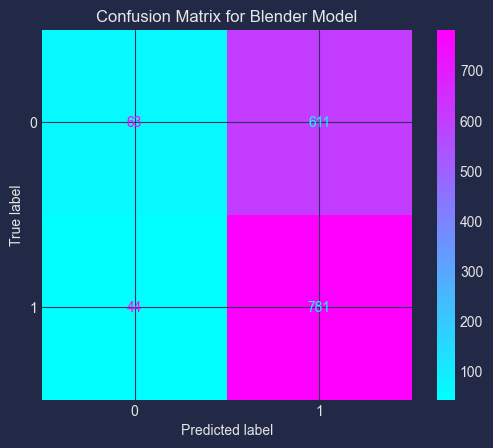

In [146]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=blender.classes_)
disp.plot(cmap="cool")
plt.title("Confusion Matrix for Blender Model")
plt.show()

### Backtest

The strategy maintains a balanced trading frequency, avoiding excessive trades.

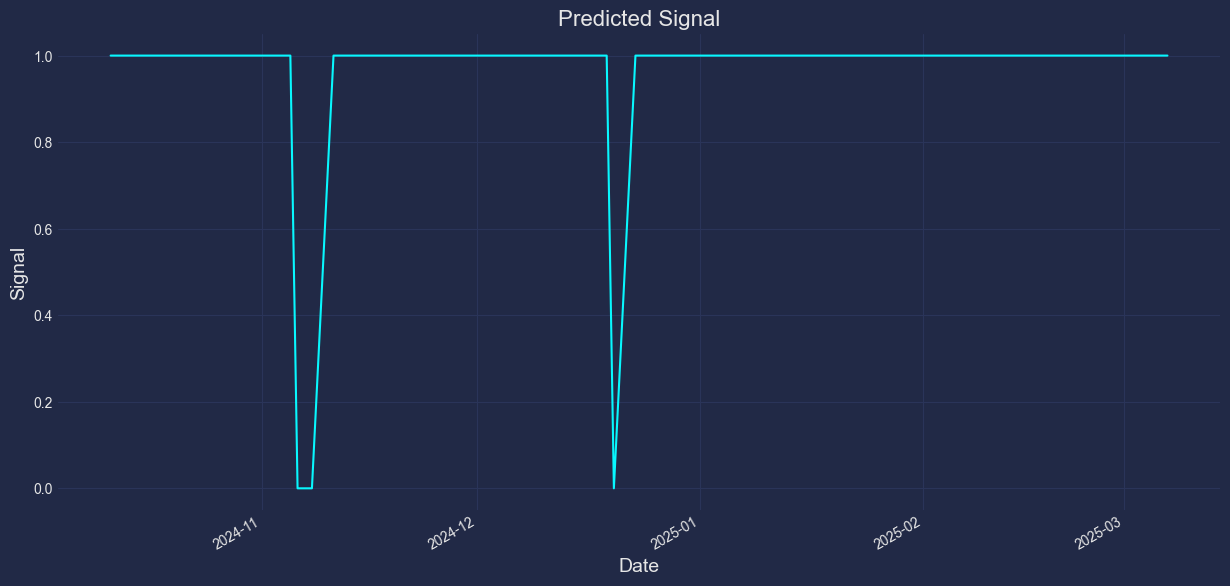

In [147]:
# Plot predicted signal
split = int(0.7*len(X))
test_data = df[split:]
test_data['predicted_signal_blender'] = blender.predict(X_holdout_for_meta)
test_data['predicted_signal_blender'][-100:].plot(figsize=(15, 7))
plt.title('Predicted Signal', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Signal', fontsize=14)
plt.show()

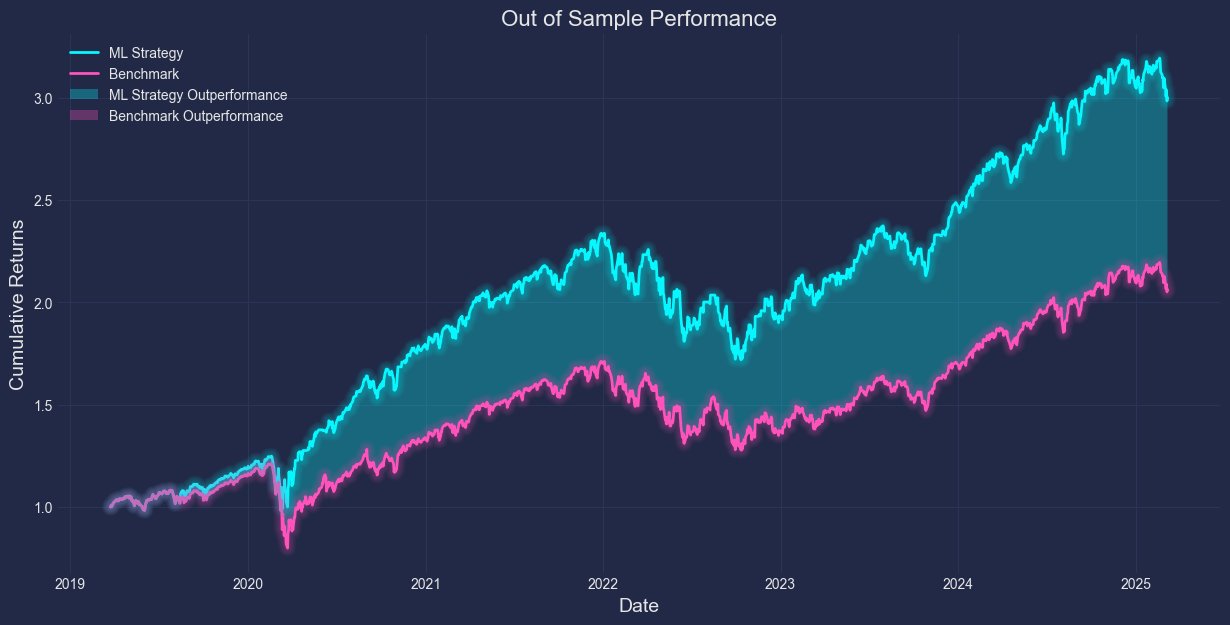

Benchmark returns: 2.06
Strategy returns: 3.0
Benchmark SR: 0.71
Strategy SR: 1.09


In [148]:
# Calculate and plot the strategy returns
test_data['blender_strategy_returns'] = test_data.Close.pct_change() * test_data['predicted_signal_blender'].shift(1)

# Compute cumulative returns
benchmark_returns = (test_data.Close.pct_change() + 1).cumprod()
strategy_returns = (test_data['blender_strategy_returns'] + 1).cumprod()

# Plot both strategies
plt.figure(figsize=(15, 7))
plt.plot(strategy_returns, label='ML Strategy', linewidth=2)
plt.plot(benchmark_returns, label='Benchmark', linewidth=2)

# Apply glow effect only between the lines
plt.fill_between(
    test_data.index, 
    strategy_returns, 
    benchmark_returns, 
    where=(strategy_returns > benchmark_returns),  
    alpha=0.3, 
    label='ML Strategy Outperformance'
)

plt.fill_between(
    test_data.index, 
    strategy_returns, 
    benchmark_returns, 
    where=(strategy_returns < benchmark_returns), 
    alpha=0.3, 
    label='Benchmark Outperformance'
)

# Plot title and labels
plt.title('Out of Sample Performance', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Cumulative Returns', fontsize=14)
plt.legend()
mplcyberpunk.make_lines_glow()

# Show the plot
plt.show()

# Print total returns
print(f"Benchmark returns: {round(benchmark_returns.iloc[-1],2)}")
print(f"Strategy returns: {round(strategy_returns.iloc[-1],2)}")

# Sharpe ratio function
def get_sr(ret):
    return round(ret.mean() / ret.std() * 252**0.5, 2)

# Print Sharpe ratios
print(f"Benchmark SR: {get_sr(test_data.Close.pct_change())}")
print(f"Strategy SR: {get_sr(test_data['blender_strategy_returns'])}")

The strategy leveraging the Blended model significantly outperforms the buy-and-hold benchmark, achieving a Sharpe ratio of 1.09 and a 300% return during the testing period. This highlights its strong profitability and improved risk-adjusted returns.

## Conclusion

In this project, we explored various machine learning models—Decision Tree, Random Forest, XGBoost, and a Blended Model—to predict daily returns of the S&P 500 (SPY). Each model was evaluated based on accuracy, feature importance, and backtesting performance.

The Decision Tree model served as a simple baseline, while the Random Forest and XGBoost models demonstrated stronger predictive power, with Random Forest showing the best overall performance. By incorporating a Blended Model, which combined multiple classifiers, we further improved risk-adjusted returns, achieving a higher Sharpe ratio and profitability compared to the buy-and-hold strategy.

However, it is important to note that these strategies are unlikely to perform as well in live trading due to factors such as market changes, transaction costs, and model overfitting. More robust feature engineering and risk management strategies need to be explored and implemented before deploying such models in real-world trading. Further testing, including on different timeframes and with a broader range of financial instruments, is necessary to assess the true potential of these models in a dynamic market environment.